# **NLP Project - Who Wants to Be a PoliMillionaire?**

**Team:** WeNeedMoreGPU

* Luca Bordin (luca1.bordin@mail.polimi.it)
* Mattia Menegale (mattia.menegale@mail.polimi.it)
* Marco Minaudo (marco.minaudo@mail.polimi.it)

**Course:** Natural Language Processing 2025/2026

---

## **Project Goal**

The goal of this project is to develop a chatbot able to compete in the online quiz **Who Wants to Be a PoliMillionaire?**.<br>
The online quiz consists of six different competitions:

* **[0] Entertainment**
* **[1] Ancient History and Politics**
* **[2] Science and Nature**
* **[3] Math**
* **[4] Philosophy and Psychology**
* **[5] News**

Moreover, the chatbot is required to operate in two possible modes:

* **Text mode:** questions and answer options are processed as written text.
* **Speech mode:** questions and options are received as audio files, transcribed with Whisper ASR, and then processed by the same answer-selection pipeline used in text mode.


## **Pipeline Overview**

| S | Section | Objective / Goal |
|:---|:---|:---|
| **S0** | **Environment Setup** | Install dependencies, import libraries, mount Google Drive, define global constants, initialize clients, and provide shared utility functions. |
| **S1** | **Baseline - Naive Prompt** | Establish a performance baseline by testing multiple models with a generic prompt. |
| **S2** | **Prompt Engineering** | Test whether category-specific instructions improve answer reliability compared with the naive baseline. |
| **S3** | **Speech Mode: Audio Input** | Extend the baseline to speech mode using Whisper ASR, preserving official option IDs and reusing the text-mode inference, parsing, timing, and logging pipeline. |
| **S4** | **RAG** | Integrate a selective retrieval pipeline to Wikipedia and news API-based retrieval for knowledge-intensive categories, while excluding Math because it mainly requires computation rather than factual lookup. |
| **S5** | **Math** | Evaluate dedicated Math pipelines, including simple prompting, tool calling, code generation, self-review, function-registry and few-shot prompting with CoT. |


## **External Services and Resources**

The **system interacts with** the official **PoliMillionaire quiz API to retrieve questions, submit answers, and manage game sessions**.

For model inference, the project relies on Hugging Face models, including instruction-tuned LLMs, Whisper for ASR, embedding/reranking models, and GLiNER for entity extraction.

The RAG pipeline uses external knowledge sources only for selected knowledge-intensive categories. In particular, it uses the **Wikipedia MediaWiki API** for Entertainment, Ancient History, Science and Nature, and Philosophy/Psychology, while News retrieval relies on **The Guardian Content API and GNews API**.

## **Development Support**

During the project, we used LLM-based coding assistants to support implementation, debugging, code refactoring, and experiment management.

The main development tools included:

* **Codex**
* **Claude Code**



----
# S0 | Environment Setup

Installation of dependencies, library imports, Google Drive mounting, global constants, and function definitions.  
**Always run this section from the start before proceeding to any other section.**

In [ ]:
%%capture
!pip install -U \
  "transformers==4.51.3" \
  "accelerate>=1.3.0" \
  "bitsandbytes>=0.46.1" \
  "safetensors>=0.4.5" \
  huggingface_hub \
  sentencepiece \
  protobuf \
  requests \
  rank_bm25 \
  sentence-transformers \
  FlagEmbedding \
  gliner \
  nltk \
  langchain-core \
  librosa \
  soundfile

In [ ]:
# ========================
# S0 - IMPORTS
# ========================

import os
import sys
import re
import io
import gc
import json
import math
import cmath
import time
import shutil
import tempfile
import inspect
import operator
import warnings
import datetime
import traceback
import fractions
import functools
import itertools
import statistics
import contextlib

from pathlib import Path
from types import SimpleNamespace
from functools import lru_cache
from contextlib import redirect_stdout, redirect_stderr
from concurrent.futures import ThreadPoolExecutor, as_completed
from concurrent.futures import TimeoutError as FuturesTimeoutError

import torch
import requests
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, userdata
from huggingface_hub import login, snapshot_download
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline,
)
from matplotlib.patches import Patch
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from nltk.corpus import stopwords
from langchain_core.tools import tool, render_text_description

In [ ]:
# ======================================
# S0 - GOOGLE-DRIVE & ENVIRONMENT SETUP
# ======================================

drive.mount("/content/drive", force_remount=True)

BASE = Path(os.getenv("NLP_BASE", "/content/drive/MyDrive/NLP/NLP_ASSIGNMENT"))
assert BASE.exists(), (
    f"Directory not found: {BASE}\n"
    "Please set the NLP_BASE environment variable or create the shortcut in MyDrive."
)
os.chdir(BASE)


LOGS_DIR_NAIVE     = BASE / "logs_naive"
LOGS_DIR_NAIVE_PROMPT_AWARE   = BASE / "logs_naive_prompt_aware"
LOGS_DIR_RAG     = BASE / "logs_rag_new_thresold_per_category"
LOGS_DIR_RAG_TEST     = BASE / "logs_rag_new_thresold_per_category_test_set"
HF_ROOT       = BASE / "hf_cache"
HF_MODELS_DIR = BASE / "hf_models"
SPEECH_AUDIO_DIR = BASE/ "speech_audio"
SPEECH_LOGS_DIR_SMALL = BASE / "logs_speech_naive_openai_whisper_small"
SPEECH_LOGS_DIR_LARGE  = BASE / "logs_speech_naive_normalized_answers_openai_whisper_large"
HEATMAPS_DIR = BASE / "Heatmaps_Naive_Approach_With_Prompt"


for d in [LOGS_DIR_NAIVE_PROMPT_AWARE, HF_ROOT, HF_MODELS_DIR,LOGS_DIR_NAIVE, HEATMAPS_DIR, LOGS_DIR_RAG, SPEECH_AUDIO_DIR, SPEECH_LOGS_DIR_LARGE,SPEECH_LOGS_DIR_SMALL, LOGS_DIR_RAG_TEST]:
    d.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"]          = str(HF_ROOT)
os.environ["HF_HUB_CACHE"]     = str(HF_ROOT / "hub")
os.environ["HF_HUB_ETAG_TIMEOUT"] = "3"

print("BASE:", BASE)


from millionaire_client import MillionaireClient


In [ ]:
# ========================
# S0 - CONSTANTS
# ========================

# competition names
COMPETITION_NAMES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    3: "Math",
    4: "Philosophy_and_Psychology",
    5: "News",
}

# model name apps
MODEL_NAME_MAP = {
    "Qwen2.5-3B-Instruct":       "Qwen/Qwen2.5-3B-Instruct",
    "Qwen2.5-7B-Instruct":       "Qwen/Qwen2.5-7B-Instruct",
    "Llama-3_2-3B-Instruct":     "meta-llama/Llama-3.2-3B-Instruct",
    "Llama-3.1-8B-Instruct":     "meta-llama/Llama-3.1-8B-Instruct",
    "gemma-2-9b-it":              "google/gemma-2-9b-it",
    "Qwen2.5-Math-7B-Instruct":  "Qwen/Qwen2.5-Math-7B-Instruct",
    "DeepSeek-R1-Distill-Qwen-7B": "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
    "Phi-4-mini-reasoning":   "microsoft/Phi-4-mini-reasoning",
    "AceMath-7B-Instruct":    "nvidia/AceMath-7B-Instruct",
}

# default profile for each model
DEFAULT_INFERENCE_PROFILE = {
    # max output token
    "max_new_tokens_reasoning": 128,
    # max time for answering a question
    "max_think_s": 18.0,
    # time used for sending the answer and overhead
    "reserve_submit_s": 2.0,
}

# override of default inference profile based on the family
MODEL_INFERENCE_PROFILES = {
    "deepseek_r1_distill": {
        "max_new_tokens_reasoning": 96,
        "max_think_s": 20.0,
        "reserve_submit_s": 5.0,
    },
    "qwen_instruct": {
        "max_new_tokens_reasoning": 256,
        "max_think_s": 20.0,
        "reserve_submit_s": 2.0,
    },
    "qwen_math": {
      "max_new_tokens_reasoning": 128,
      "max_think_s": 15.0,
      "reserve_submit_s": 3.0,

    },
    "llama_instruct": {
        "max_new_tokens_reasoning": 160,
        "max_think_s": 16.0,
        "reserve_submit_s": 2.0,
    },
    "phi_reasoning": {
      "max_new_tokens_reasoning": 256,
      "max_think_s": 25.0,
      "reserve_submit_s": 5.0,
    },
    "acemath": {
        "max_new_tokens_reasoning": 256,
        "max_think_s": 22.0,
        "reserve_submit_s": 3.0,
    },
    "gemma_it": {
        "max_new_tokens_reasoning": 96,
        "max_think_s": 12.0,
        "reserve_submit_s": 3.0,
    },
}



# current used model
MODEL_ID = "nvidia/AceMath-7B-Instruct"

# api url
API_URL = "http://131.175.15.22:51111/"

# current username
USERNAME = userdata.get('username')

#client setup
client = MillionaireClient(API_URL)
user = client.login(USERNAME, userdata.get("poli-millionaire"))
print(f"Logged in as: {user.username}")

# login on HuggingFace
login(token = userdata.get('HF_TOKEN'))
print(f"Model selected: {MODEL_ID}")


In [ ]:
# =========================
# S0 - UTILITY - FUNCTIONS
# =========================

# Convert text into a filesystem-safe filename.
def slugify_filename(text: str) -> str:
    text = str(text).strip().replace(" ", "_")
    text = re.sub(r"[^\w\-]+", "", text)
    text = re.sub(r"_+", "_", text)
    return text

# Return the label for the current model
# e.g 'Qwen/Qwen2.5-3B-Instruct' -> 'Qwen2.5-3B-Instruct'
def get_model_label(model_id: str | None = None) -> str:
    if model_id is None:
        return "unknown_model"
    short = model_id.split("/")[-1]
    return slugify_filename(short)

# get the competition label
def get_competition_label(comp_id: int) -> str:
    return COMPETITION_NAMES.get(comp_id, f"competition_{comp_id}")

# used for automatically classify the model and then used for given the right parameters
def infer_model_family(model_id: str | None) -> str:
    lid = (model_id or "").lower()
    if "deepseek-r1-distill" in lid: return "deepseek_r1_distill"
    if "qwen2.5-math" in lid or "qwen-math" in lid: return "qwen_math"
    if "qwen" in lid: return "qwen_instruct"
    if "llama" in lid: return "llama_instruct"
    if "gemma" in lid: return "gemma_it"
    if "phi-4-mini-reasoning" in lid: return "phi_reasoning"
    if "acemath" in lid: return "acemath"
    if "phi" in lid: return "phi_instruct"
    return "default"


# Infer the model family to select the right inference parameters.
def get_play_params(model_id: str | None = None) -> dict:

    profile = dict(DEFAULT_INFERENCE_PROFILE)
    family  = infer_model_family(model_id)
    profile.update(MODEL_INFERENCE_PROFILES.get(family, {}))

    return {
        "max_new_tokens"   : int(profile["max_new_tokens_reasoning"]),
        "max_think_s"      : float(profile["max_think_s"]),
        "reserve_submit_s" : float(profile["reserve_submit_s"]),
    }

In [ ]:
# ================
# S0 - LOG HELPERS
# ================

# desided category
DESIRED_CATEGORY_COLS_TEXT = [
    "Entertainment (text)",
    "Ancient_History (text)",
    "Science_and_Nature (text)",
    "Math (text)",
    "Philosophy_and_Psychology (text)",
    "News (text)",
]
# Create and append a log entry for a single question
def log_entry(game_log, session_id, level, question, options, model_answer,
              correct, elapsed, raw_output, competition_id, model_id=None, mode="text"):
    entry = {
        "timestamp": datetime.datetime.now().isoformat(),
        "session_id": session_id,
        "competition_id": competition_id,
        "competition_name": get_competition_label(competition_id),
        "mode": mode,
        "level": level,
        "question": question,
        "options": {str(o.id): o.text for o in options},
        "model_answer": model_answer,
        "raw_output": raw_output,
        "result": correct,
        "elapsed_s": round(elapsed, 3),
        "model_name": model_id,
    }
    game_log.append(entry)
    return entry

# Save the full game log as a JSON file, including model, timestamp, and category in the filename
def save_log(game_log, comp_id: int, model_id: str, logs_dir: Path = LOGS_DIR_RAG):
    now_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_label = get_model_label(model_id)
    competition_label = get_competition_label(comp_id)

    filename = f"game_log_{model_label}_{now_str}_{competition_label}.json"
    filepath = logs_dir / filename

    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(game_log, f, indent=2, ensure_ascii=False)

    print(f"Log saved: {len(game_log)} entries → {filepath}")
    return filepath

# Load all saved game logs from a directory and convert them into a single DataFrame
def load_all_logs(logs_dir: Path) -> pd.DataFrame:
    all_entries = []
    files_found = list(logs_dir.glob("game_log_*.json"))

    print(f"Found {len(files_found)} log files:\n")

    for filepath in sorted(files_found):
        print(f"  → {filepath.name}")

        fname = filepath.stem
        parts = re.split(r"_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_", fname)

        if len(parts) == 3:
            model_from_filename = parts[0].replace("game_log_", "")
            date_from_filename = parts[1]
            category_from_filename = parts[2]
        else:
            model_from_filename = "unknown"
            date_from_filename = "unknown"
            category_from_filename = "unknown"

        with open(filepath, "r", encoding="utf-8") as f:
            entries = json.load(f)

        for entry in entries:
            entry["model_from_filename"] = model_from_filename
            entry["category_from_filename"] = category_from_filename
            entry["date_from_filename"] = date_from_filename

            # Backward compatibility: old logs without mode are text logs.
            entry["mode"] = entry.get("mode", "text")

            all_entries.append(entry)

    if not all_entries:
        print("No entries found!")
        return pd.DataFrame()

    df = pd.DataFrame(all_entries)

    df["correct_bool"] = df["result"] == "correct"
    df["timed_out_bool"] = df["result"] == "timed_out"

    df["model"] = df["model_name"].fillna(df["model_from_filename"])
    df["category"] = df["competition_name"].fillna(df["category_from_filename"])

    df["model"] = df["model"].apply(normalize_model_name)

    print(f"\nTotal entries loaded: {len(df)}")
    print(f"Models found:      {df['model'].unique()}")
    print(f"Categories found:  {df['category'].unique()}")
    print(f"Modes found:       {df['mode'].unique()}")

    return df

# Normalize model names so results from filenames and logs use a consistent label
def normalize_model_name(name: str) -> str:
    return MODEL_NAME_MAP.get(name, name)

# Compute question-level accuracy by model, category, and optionally mode
def table_accuracy(df: pd.DataFrame, split_by_mode: bool = True) -> pd.DataFrame:
    group_cols = ["model", "category"]

    if split_by_mode:
        group_cols.append("mode")

    pivot = df.groupby(group_cols)["correct_bool"].agg(
        correct="sum",
        total="count",
    ).reset_index()

    pivot["accuracy_%"] = (pivot["correct"] / pivot["total"] * 100).round(1)
    pivot["label"] = pivot.apply(
        lambda r: f"{r['accuracy_%']}%\n({r['correct']}/{r['total']})",
        axis=1,
    )

    if split_by_mode:
        pivot["category_col"] = pivot["category"] + " (" + pivot["mode"] + ")"
    else:
        pivot["category_col"] = pivot["category"]

    table = pivot.pivot(index="model", columns="category_col", values="accuracy_%")
    label_table = pivot.pivot(index="model", columns="category_col", values="label")


    return table, label_table

# Plot a heatmap of question-level accuracy
def plot_heatmap(
    table,
    title="Question-Level Accuracy (%)",
    save_path="/content/drive/MyDrive/NLP/NLP_ASSIGNMENT/Heatmaps/question_level_accuracy_heatmap.png",
):
    fig, ax = plt.subplots(figsize=(10, max(4, len(table) * 1.2)))

    labels = table.map(lambda x: f"{x:.1f}%" if pd.notna(x) else "")

    sns.heatmap(
        table,
        annot=labels,
        fmt="",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="gray",
        ax=ax,
        annot_kws={"size": 10},
    )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Category / Mode", fontsize=11)
    ax.set_ylabel("Model", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Plot how many questions were answered at each game level
def plot_answered_questions_by_level(
    level_counts,
    title="Answered Questions by Level",
    save_path="/content/drive/MyDrive/NLP/NLP_ASSIGNMENT/Heatmaps/answered_questions_by_level.png",
):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.bar(level_counts["level"], level_counts["n_questions"])

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Level", fontsize=11)
    ax.set_ylabel("Number of Answered Questions", fontsize=11)
    ax.set_xticks(level_counts["level"])
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Plot the average stopping level reached by each model
def plot_avg_stopping_level(
    pivot_avg_level,
    title="Average Stopping Level per Game",
    save_path="/content/drive/MyDrive/NLP/NLP_ASSIGNMENT/Heatmaps/average_stopping_level.png",
):
    n_rows, n_cols = pivot_avg_level.shape

    fig_width = max(14, n_cols * 2.2)
    fig_height = max(6, n_rows * 0.75)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    sns.heatmap(
        pivot_avg_level,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="gray",
        ax=ax,
        annot_kws={"size": 12},
        cbar_kws={"shrink": 0.85},
    )

    ax.set_title(title, fontsize=18, pad=18)
    ax.set_xlabel("Category / Mode", fontsize=14, labelpad=14)
    ax.set_ylabel("Model", fontsize=14, labelpad=14)

    ax.tick_params(axis="x", labelrotation=45, labelsize=12)
    ax.tick_params(axis="y", labelrotation=0, labelsize=12)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Build a pivot table for a selected game-level metric
def make_metric_pivot(
    game_stats: pd.DataFrame,
    metric_col: str,
    agg_fn: str,
    desired_cols: list[str] | None = None,
    split_by_mode: bool = True,
) -> pd.DataFrame:
    group_cols = ["model_name", "competition_name"]

    if split_by_mode:
        group_cols.append("mode")

    pivot_data = (
        game_stats.groupby(group_cols, as_index=False)[metric_col]
        .agg(agg_fn)
    )

    if split_by_mode:
        pivot_data["competition_col"] = (
            pivot_data["competition_name"] + " (" + pivot_data["mode"] + ")"
        )
    else:
        pivot_data["competition_col"] = pivot_data["competition_name"]

    pivot = pivot_data.pivot(
        index="model_name",
        columns="competition_col",
        values=metric_col,
    )

    if desired_cols is not None:
        pivot = pivot.reindex(columns=[c for c in desired_cols if c in pivot.columns])

    return pivot

# Plot a generic single-metric heatmap used across experiment sections
def plot_single_metric_heatmap(
    table,
    title,
    cmap,
    cbar_label,
    save_path,
    fmt=".1f",
    vmin=None,
    vmax=None,
):
    n_rows, n_cols = table.shape

    fig_width = max(12, n_cols * 1.8)
    fig_height = max(5, n_rows * 0.9)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    sns.heatmap(
        table,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": cbar_label, "shrink": 0.85},
        annot_kws={"size": 12},
        vmin=vmin,
        vmax=vmax,
        ax=ax,
    )

    ax.set_title(title, fontsize=17, fontweight="bold", pad=16)
    ax.set_xlabel("Category / Mode", fontsize=13, labelpad=12)
    ax.set_ylabel("Model", fontsize=13, labelpad=12)

    ax.tick_params(axis="x", labelrotation=45, labelsize=11)
    ax.tick_params(axis="y", labelrotation=0, labelsize=11)

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
# ==================
# S0 - MODEL LOADING
# ==================

# load model with 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# get dir of local model and removes '/' for Drive
def get_local_model_dir(model_id: str) -> Path:
    return HF_MODELS_DIR / model_id.replace("/", "__")

# check if the download of a model is complete
def _check_model_dir_complete(model_dir: Path):
    missing = []

    for f in ["config.json", "tokenizer_config.json"]:
        if not (model_dir / f).exists():
            missing.append(f)

    index_file = model_dir / "model.safetensors.index.json"
    single_safetensors = model_dir / "model.safetensors"
    single_bin = model_dir / "pytorch_model.bin"

    if index_file.exists():
        try:
            meta = json.loads(index_file.read_text(encoding="utf-8"))
            shards = sorted(set(meta.get("weight_map", {}).values()))
        except Exception:
            missing.append("invalid_index_json")
            return False, missing

        for shard in shards:
            if not (model_dir / shard).exists():
                missing.append(shard)
    else:
        if not single_safetensors.exists() and not single_bin.exists():
            missing.append("weights_missing")

    return len(missing) == 0, missing

# Check if the model is already on Drive
# Otherwise download it from Hugging Face (snapshot_download)
# If incomplete -> remove and retry again
# If incomplete again -> error
def ensure_model_snapshot(model_id: str, force_redownload: bool = False) -> Path:
    local_dir = get_local_model_dir(model_id)
    local_dir.mkdir(parents=True, exist_ok=True)

    if force_redownload and local_dir.exists():
        shutil.rmtree(local_dir, ignore_errors=True)
        local_dir.mkdir(parents=True, exist_ok=True)

    ready, missing = _check_model_dir_complete(local_dir)

    if not ready:
        print(f"Downloading model snapshot for {model_id}...")
        snapshot_download(repo_id=model_id, local_dir=str(local_dir), max_workers=4)
        ready, missing = _check_model_dir_complete(local_dir)

    if not ready:
        print("Model dir still incomplete, cleaning and retrying once...")
        shutil.rmtree(local_dir, ignore_errors=True)
        local_dir.mkdir(parents=True, exist_ok=True)
        snapshot_download(repo_id=model_id, local_dir=str(local_dir), max_workers=4)
        ready, missing = _check_model_dir_complete(local_dir)

    if not ready:
        raise FileNotFoundError(f"Model files incomplete in {local_dir}. Missing: {missing[:10]}")

    return local_dir

# load quantized model
def load_quantized_model(
    model_id: str,
    quant_config: BitsAndBytesConfig | None = None,
    force_redownload: bool = False,
):
    quant_config = quant_config or bnb_config
    local_dir = ensure_model_snapshot(model_id, force_redownload=force_redownload)

    print(f"Model ready in {local_dir}")
    print(f"Loading tokenizer for {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(str(local_dir), local_files_only=True)

    print("Loading model ...")
    t_start = time.time()
    #load model
    model = AutoModelForCausalLM.from_pretrained(
        str(local_dir),
        # Map a Hugging Face model id to its local Drive directory.
        local_files_only=True,
        # use the quantization file
        quantization_config=quant_config,
        #put the layers on the GPU/CPU
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True,
    )
    # disable dropout and batch norm training (we are not in training mode, but in inference mode)
    model.eval()

    t_load = time.time() - t_start
    print(f"Model loaded in {t_load:.1f}s")

    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved")

    return tokenizer, model, local_dir, t_load

# Free VRAM space. Used before loading another model
def unload_model_from_memory():
    import gc

    g = globals()
    if "model" in g:
        del g["model"]
    if "tokenizer" in g:
        del g["tokenizer"]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

---
# **S1 — Baseline: Naive Prompt Across Multiple Models**

## **Objective**

The **goal of this section** is to **establish** an **initial performance** baseline for the quiz task.

In this baseline setup, **we evaluate all selected models** using a **simple generic prompt**, without any category-specific instructions, retrieval mechanism, or reasoning strategy. The same prompt format is applied to every quiz category.

## **Experimental Setup**

Each model is evaluated across the available quiz categories using the same naive prompt structure.  
For each model and category, we run multiple game sessions and collect the corresponding logs.

The prompt only asks the model to select one of the available answer options and return the result in a fixed format:

```text
FINAL_ANSWER: <id>

In [ ]:
# ========================
# S1 - NAIVE APPROACH
# ========================

# Build the naive prompt:
# generic prompt + the question with the options
def _build_prompt_naive(question_text: str, options: list) -> tuple[str, str]:
    opts    = "\n".join([f"{o.id}) {o.text}" for o in options])
    allowed = ", ".join([str(o.id) for o in options])
    system  = "You are a helpful assistant answering multiple-choice questions."
    user    = (
        f"Question: {question_text}\n\n"
        f"Options:\n{opts}\n\n"
        f"Answer with exactly: FINAL_ANSWER: <id>  where <id> is one of {allowed}.\n"
        f"Do not explain."
    )
    return system, user

# Run the chat prompt through the selected LLM and parse a valid option id from FINAL_ANSWER.
def ask_llm_with_prompt(system, user, options, model, tokenizer, max_new_tokens=128):
    def get_id(o):
        if isinstance(o, dict):
            return str(o.get("id", o.get("label", "")))
        return str(o.id)

    # e.g. 0, 1, 2, 3
    valid = set(get_id(o) for o in options)

     # Gemma doesn't support system role: merge it on user
    if hasattr(tokenizer, "name_or_path") and "gemma" in tokenizer.name_or_path.lower():
        messages = [{"role": "user", "content": f"{system}\n\n{user}"}]
    else:
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ]


    # convert the list of messages in the specific format required by the model
    # Load only local files; do not download during model loading.
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # tokenize the text in numerical ID, put it in a PyTorch tensor and move in the GPU
    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    t0 = time.time()

    # we don't need gradients (we are not in the training phase)
    with torch.no_grad():
        # generate token autoregressive
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    #measure inference time
    elapsed = time.time() - t0

    #remove the prompt token and keep only generated token, remove special tokens like EOS/PAD, clean spaces and new lines
    raw = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    #find the pattern like FINAL_ANSWER: 2
    m = re.search(r"FINAL_ANSWER\s*:\s*(\d+)", raw, re.IGNORECASE)
    pred = m.group(1) if m else None
    ans = int(pred) if pred in valid else None

    return ans, raw, elapsed

# wrapper used for calling the model in the naive setup
def ask_llm_naive(question_text, options, model, tokenizer,comp_id=None, model_id=None, max_new_tokens=None, time_left_s=None,level=None, **kwargs,):
    params = get_play_params(model_id)
    tokens = max_new_tokens or params["max_new_tokens"]
    system, user = _build_prompt_naive(question_text, options)
    return ask_llm_with_prompt(system, user, options, model, tokenizer, max_new_tokens=tokens)


In [ ]:
# =====================
# S1 - GAME INPUT MODE
# =====================

# Fetch the current question and options when the game runs in text mode.
def _fetch_text_input(game) -> tuple[str | None, list | None, dict]:
    question = game.current_question
    if not question:
        return None, None, {}

    return question.text, question.options, {"mode": "text"}

# Fetch and transcribe the current question and options when the game runs in speech mode.
def _fetch_speech_input(game) -> tuple[str | None, list | None, dict]:
    session_id = game.session_id
    level = game.current_level

    q_audio = game.fetch_audio_question()
    q_text_raw, q_asr_s, q_path = transcribe_audio_bytes(
        q_audio,
        prefix=f"s{session_id}_l{level}_question",
    )
    q_text = clean_transcript(q_text_raw)

    print(f"\nQuestion transcript ({q_asr_s:.2f}s): {q_text}")

    opt_texts = []
    opt_asr_s = []
    opt_paths = []

    for idx in range(4):
        letter = chr(65 + idx)

        opt_audio = game.fetch_audio_option_next()
        opt_text_raw, opt_elapsed, opt_path = transcribe_audio_bytes(
            opt_audio,
            prefix=f"s{session_id}_l{level}_option_{letter}",
        )
        opt_text = clean_transcript(opt_text_raw)

        if is_empty_or_bad(opt_text):
            print(f"  [{letter}] transcript unusable, raw: {opt_text_raw[:80]!r}")
            opt_text = f"[option {letter} - unintelligible]"

        opt_texts.append(opt_text)
        opt_asr_s.append(opt_elapsed)
        opt_paths.append(opt_path)

        print(f"  [{letter}] transcript ({opt_elapsed:.2f}s): {opt_text}")

    game.refresh_state()
    question = game.current_question
    if not question:
        return None, None, {}

    options = [
        SimpleNamespace(id=opt.id, text=opt_texts[i])
        for i, opt in enumerate(question.options)
        if i < len(opt_texts)
    ]

    speech_meta = {
        "mode": "speech",
        "question_audio_path": q_path,
        "option_audio_paths": opt_paths,
        "question_asr_s": round(q_asr_s, 3),
        "options_asr_s": [round(x, 3) for x in opt_asr_s],
        "asr_total_s": round(q_asr_s + sum(opt_asr_s), 3),
    }

    return q_text, options, speech_meta

# Dispatch input fetching to the correct text or speech-mode handler.
def _fetch_question_input(game, mode: str) -> tuple[str | None, list | None, dict]:
    if mode == "speech":
        return _fetch_speech_input(game)
    return _fetch_text_input(game)

# Call the selected LLM answering function with the shared game arguments.
def _call_ask_llm(ask_llm_fn, question_text, options, model, tokenizer, **kwargs):
    try:
        return ask_llm_fn(question_text, options, model, tokenizer, **kwargs)
    except TypeError as e:
        if "unexpected keyword argument" not in str(e):
            raise

        kwargs.pop("level", None)
        return ask_llm_fn(question_text, options, model, tokenizer, **kwargs)

In [ ]:
# ============================================
# S1 - PLAY AUTOMATED: TEXT + SPEECH
# ============================================

# Run one quiz game in text or speech mode, submit model answers, and save per-question logs.
def play_automated(
    client,
    comp_id: int,
    model,
    tokenizer,
    ask_llm_fn,
    model_id: str = "unknown_model",
    max_new_tokens: int | None = None,
    max_think_s: float = 18.0,
    reserve_submit_s: float = 2.0,
    save_logs: bool = True,
    logs_dir: Path | None = None,
    mode: str = "text",
):
    game_log: list[dict] = []
    saved_path = None

    if logs_dir is None:
        # Use separate default log directories for text and speech runs.
        logs_dir = SPEECH_LOGS_DIR_LARGE if mode == "speech" else LOGS_DIR_NAIVE

    print(f"\n{'=' * 100}")
    print(
        f"Starting game [{mode}]: competition {comp_id} "
        f"({get_competition_label(comp_id)}) | model: {model_id}"
    )
    print(f"{'=' * 100}")

    try:
        client._base._session.headers.update({"Connection": "close"})
    except Exception:
        pass

    # Start a new game in text or speech mode.
    game = client.game.start(competition_id=comp_id, mode=mode)

    print(f"Session ID: {game.session_id}")

    try:
      # keep playing if we are correctly answering the questions
        while game.in_progress:
            question_text, options, input_meta = _fetch_question_input(game, mode)

            if question_text is None or not options:
                print("No question — game ended.")
                break

            level = game.current_level
            time_left = game.time_remaining or 30.0

            # Reserve a small time buffer for answer submission.
            q_budget = max(1.0, min(max_think_s, time_left - reserve_submit_s))

            print(
                f"\n--- Level {level} | mode={mode} | "
                f"Time left: {time_left:.1f}s | Budget: {q_budget:.1f}s ---"
            )
            print(f"Q: {question_text}")
            for opt in options:
                print(f"  [{opt.id}] {opt.text}")

            try:
                tokens = (
                    max_new_tokens
                    if max_new_tokens is not None
                    else get_play_params(model_id)["max_new_tokens"]
                )

                # Core step: ask the selected strategy to choose an answer for the current question.
                # return answert_id, raw_output and llm_elapsed time
                answer_id, raw_output, llm_elapsed = _call_ask_llm(
                    ask_llm_fn,
                    question_text,
                    options,
                    model,
                    tokenizer,
                    comp_id=comp_id,
                    model_id=model_id,
                    max_new_tokens=tokens,
                    time_left_s=q_budget,
                    level=level,
                )

                # if the answer_id is None, Fallback to the first option
                if answer_id is None:
                    answer_id = options[0].id
                    raw_output = (raw_output or "") + "\n[PARSE_FAILED_FALLBACK_TO_FIRST_OPTION]"

            except Exception as e:
                print(f"  [ERROR] ask_llm: {e} → fallback first option")
                answer_id = options[0].id
                raw_output = f"<error: {e}>"
                llm_elapsed = 0.0

            asr_total_s = float(input_meta.get("asr_total_s", 0.0))

            # In speech mode, total latency includes both transcription and LLM inference.
            total_elapsed = asr_total_s + llm_elapsed

            valid_ids = {int(o.id) for o in options}

            # Ensure the submitted answer is one of the official option ids.
            try:
                answer_id = int(answer_id)
            except Exception:
                answer_id = int(options[0].id)
                raw_output = (raw_output or "") + "\n[INVALID_ANSWER_ID_FALLBACK]"

            if answer_id not in valid_ids:
                answer_id = int(options[0].id)
                raw_output = (raw_output or "") + "\n[ANSWER_ID_NOT_IN_OPTIONS_FALLBACK]"

            print(
                f"  → Answer: {answer_id} "
                f"(LLM: {llm_elapsed:.2f}s | total: {total_elapsed:.2f}s)"
            )
            print(f"  → Raw: '{(raw_output or '<empty>')[:120]}...'")

            remaining_now = game.time_remaining or 0.0

            # Avoid submitting when the remaining time is below the safety margin.
            if remaining_now < reserve_submit_s:
                print(f"  [TIME] Too late to submit safely: {remaining_now:.2f}s left")

                entry = log_entry(
                    game_log,
                    game.session_id,
                    level,
                    question_text,
                    options,
                    answer_id,
                    "timed_out_local",
                    total_elapsed,
                    raw_output,
                    comp_id,
                    model_id,
                )
                entry.update({**input_meta, "llm_elapsed_s": round(llm_elapsed, 3)})
                break

            try:
                result = game.answer(answer_id)

            except Exception as e:
                print(f"  [ERROR] game.answer(): {e}")

                # Refresh state after submission errors to capture the platform status in logs.
                try:
                    state = game.refresh_state()
                    print(
                        f"  [STATE AFTER ERROR] status={state.status}, "
                        f"level={game.current_level}, "
                        f"time_remaining={game.time_remaining}"
                    )
                except Exception as e2:
                    print(f"  [ERROR] refresh_state failed: {e2}")

                entry = log_entry(
                    game_log,
                    game.session_id,
                    level,
                    question_text,
                    options,
                    answer_id,
                    "submit_error",
                    total_elapsed,
                    raw_output,
                    comp_id,
                    model_id,
                )
                entry.update({**input_meta, "llm_elapsed_s": round(llm_elapsed, 3)})
                break

            if result.timed_out:
                outcome = "timed_out"
                print("  ⏰ TIMED OUT!")
            elif result.correct:
                outcome = "correct"
                print(f"  ✅ CORRECT! Earned: ${result.earned_amount:,.2f}")
            else:
                outcome = "wrong"
                print(f"  ❌ WRONG! Game over. Earned: ${result.earned_amount:,.2f}")

            #get the current entry
            entry = log_entry(
                game_log,
                game.session_id,
                level,
                question_text,
                options,
                answer_id,
                outcome,
                total_elapsed,
                raw_output,
                comp_id,
                model_id,
            )
            entry.update({**input_meta, "llm_elapsed_s": round(llm_elapsed, 3)})

            if result.game_over or result.timed_out:
                break

    except Exception as e:
        print(f"\n[CRITICAL] Exception in the game loop: {e}")
        print("Partial log saved.")

    finally:
        print(f"\n{'=' * 50}")
        try:
            print(f"GAME OVER — Level reached: {game.current_level}")
            print(f"Total earned: ${game.earned_amount:,.2f}")
        except Exception:
            print("(impossible to read the final state)")
        print(f"{'=' * 50}")

        saved_path = (
            save_log(game_log, comp_id=comp_id, model_id=model_id, logs_dir=logs_dir)
            if (save_logs and game_log)
            else None
        )

        if not save_logs:
            print("Save log disabled.")
        elif not saved_path:
            print("Empty log — no files saved.")

    return game_log, saved_path

In [ ]:
# ================================
# S1 - EXPERIMENT RUNNER
# ================================

# Extract question-level entries from either a raw list or a wrapped log dictionary.
def extract_entries(log_obj):
    if isinstance(log_obj, list):
        return log_obj
    if isinstance(log_obj, dict):
        for k in ("entries", "history", "questions", "log", "records"):
            if k in log_obj and isinstance(log_obj[k], list):
                return log_obj[k]
    return []

# Run multiple games across the selected categories and return a flat DataFrame of all question logs.
def run_experiment(
    client,
    categories: dict[int, str],
    n_games_per_cat: int,
    model,
    tokenizer,
    ask_llm_fn,
    model_id: str,
    run_prefix: str,
    save_logs: bool = True,
    play_params: dict | None = None,
    logs_dir: Path | None = None,
    mode: str = "text",
) -> pd.DataFrame:
    play_params = play_params or {}

    all_rows = []
    run_counter = 0

    for comp_id, comp_name in categories.items():
        for i in range(1, n_games_per_cat + 1):
            run_counter += 1

            # Unique id used to group questions belonging to the same game run.
            run_uid = f"{run_prefix}_{comp_id}_{i}"

            print(f"\n=== {run_uid} | comp_id={comp_id} ({comp_name}) ===")

            # Shared arguments passed to play_automated for this run.
            kwargs = dict(
                client=client,
                comp_id=comp_id,
                model=model,
                tokenizer=tokenizer,
                ask_llm_fn=ask_llm_fn,
                model_id=model_id,
                save_logs=save_logs,
                mode = mode,
                **play_params,
            )

            if logs_dir is not None:
                kwargs["logs_dir"] = logs_dir

            # Execute one full game and collect its raw log.
            log, _ = play_automated(**kwargs)

            log_text = str(log)
            entries = extract_entries(log)

            if not entries:
                print("No entries found in log.")
                continue

            for e in entries:
                if not isinstance(e, dict):
                    continue

                row = dict(e)
                row["run_uid"] = run_uid
                row["competition_id"] = comp_id
                row["competition_name"] = row.get("competition_name", comp_name)
                row["model_name"] = row.get("model_name", model_id)
                row["log_text"] = log_text
                all_rows.append(row)

            print("Run completed.")

    df = pd.DataFrame(all_rows)
    print(f"\nDone — {len(df)} total entries across {run_counter} games.")
    return df

In [ ]:
# =====================================
# S1 - LOAD THE TOKENIZER AND THE MODEL
# =====================================

# Free GPU memory before loading the selected model.
unload_model_from_memory()

# Load the tokenizer and the quantized model.
tokenizer, model, local_dir, t_load = load_quantized_model(
    MODEL_ID,
    quant_config = bnb_config
    )
LOCAL_DIR = str(local_dir)

In [ ]:
# =====================================
# S1 - RUN NAIVE BASELINE
# =====================================

# Select the categories to evaluate with the naive baseline.
NAIVE_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    3: "Math",
    4: "Philosophy_and_Psychology",
    5: "News",
}

N_GAMES_PER_CAT = 20

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

df_naive = run_experiment(
    client=client,
    categories=NAIVE_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_naive,
    model_id=MODEL_ID,
    run_prefix="naive",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_NAIVE,
    mode = "text"
)

In [ ]:
# ==================================================
# S1 — LOAD NAIVE LOGS AND COMPUTE METRICS
# ==================================================

df_naive = load_all_logs(LOGS_DIR_NAIVE)

if df_naive.empty:
    raise RuntimeError("No naive logs found.")

# Normalize model names
df_naive["model"] = df_naive["model"].apply(normalize_model_name)


# Question-level accuracy table
table_naive, label_table_naive = table_accuracy(df_naive)

table_naive = table_naive.reindex(columns=DESIRED_CATEGORY_COLS_TEXT)
label_table_naive = label_table_naive.reindex(columns=DESIRED_CATEGORY_COLS_TEXT)



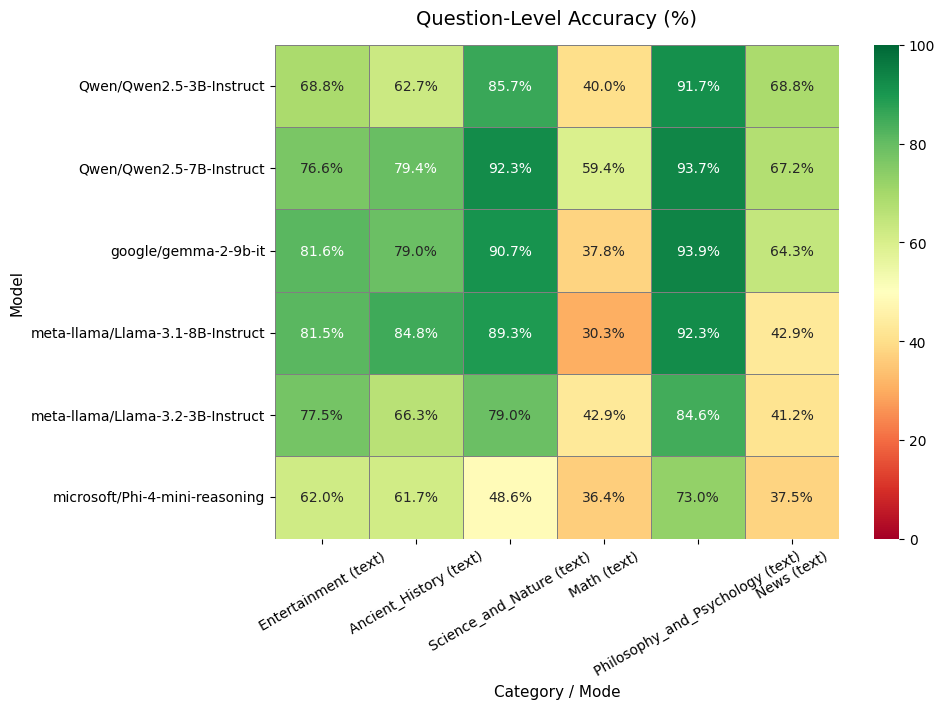

In [ ]:
# ==================================================
# S1 — QUESTION LEVEL ACCURACY
# ==================================================

# Plot 1: Question-level accuracy heatmap
plot_heatmap(
    table_naive,
    save_path=HEATMAPS_DIR / "question_level_accuracy_heatmap.png",
)

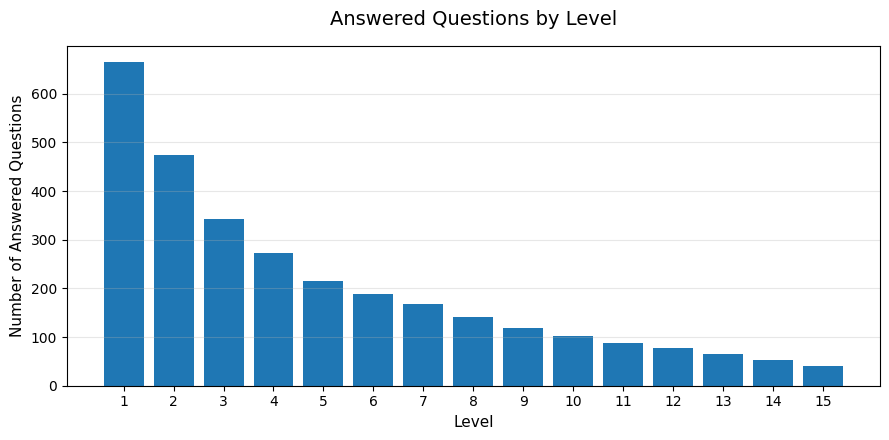

In [ ]:
# ==================================================
# S1 — ANSWERED QUESTIONS BY LEVEL
# ==================================================

level_counts_naive = (
    df_naive.groupby("level")
            .size()
            .reset_index(name="n_questions")
)

plot_answered_questions_by_level(
    level_counts_naive,
    save_path=HEATMAPS_DIR / "answered_questions_by_level_naive.png",
)

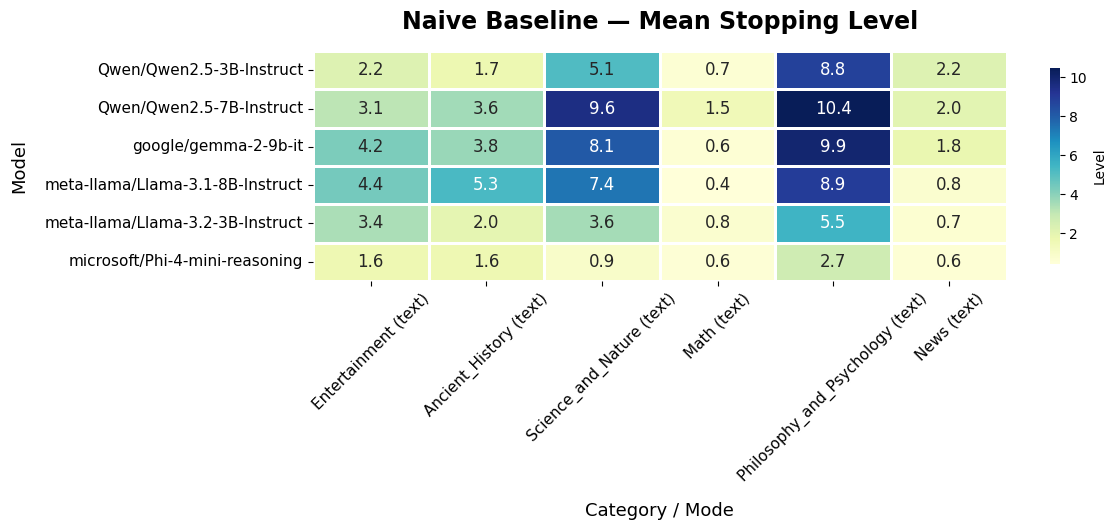

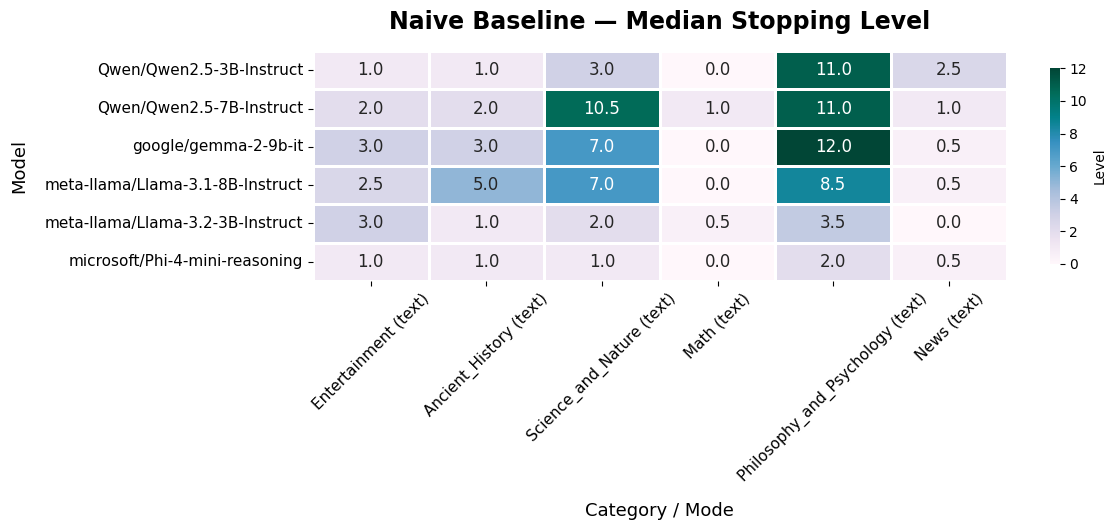

In [ ]:
# ==================================================
# S1 — GAME-LEVEL STOPPING LEVEL METRICS
# ==================================================

df_naive["is_correct"] = df_naive["result"].eq("correct")
df_naive["mode"] = df_naive.get("mode", "text")

game_stats_naive = (
    df_naive.groupby(["model_name", "competition_name", "mode", "session_id"])
    .agg(
        stopping_level=("is_correct", "sum"),
        answered_questions=("level", "size"),
        avg_elapsed_s=("elapsed_s", "mean"),
        total_elapsed_s=("elapsed_s", "sum"),
        final_result=("result", "last"),
    )
    .reset_index()
)

pivot_mean_naive = make_metric_pivot(
    game_stats_naive,
    metric_col="stopping_level",
    agg_fn="mean",
    desired_cols=DESIRED_CATEGORY_COLS_TEXT,
)

pivot_median_naive = make_metric_pivot(
    game_stats_naive,
    metric_col="stopping_level",
    agg_fn="median",
    desired_cols=DESIRED_CATEGORY_COLS_TEXT,
)

plot_single_metric_heatmap(
    pivot_mean_naive,
    title="Naive Baseline — Mean Stopping Level",
    cmap="YlGnBu",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "mean_stopping_level_naive.png",
)

plot_single_metric_heatmap(
    pivot_median_naive,
    title="Naive Baseline — Median Stopping Level",
    cmap="PuBuGn",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "median_stopping_level_naive.png",
)

## **S1 — Results**

The **naive baseline** achieves relatively **high question-level accuracy in several categories**, especially in **Science and Nature** and **Philosophy and Psychology**. **However**, the game-level metrics show a more limited performance: the **mean and median stopping levels are often much lower than the accuracy heatmap alone would suggest**.

This happens because a single wrong answer ends the game, so even models with good average accuracy may fail to consistently reach the higher levels. The answered-questions-by-level plot confirms this behavior: most runs stop in the early or middle stages, while only a smaller number of games reach the final questions.

Among the tested models, **Qwen2.5-7B-Instruct**, **Gemma-2-9B-it**, and **Llama-3.1-8B-Instruct** provide the strongest and most useful baseline results. For this reason, they were selected as the reference models for the next analyses.

# **S2 — Prompt Engineering: Category-Aware Prompting**

## **Objective**

The goal of this section is to **improve the naive baseline** by **adding category-specific instructions** while keeping the overall evaluation pipeline. <br>

In the naive approach, the same generic prompt was used for every quiz category. Here, we test whether adding a short category-aware introduction helps the model focus on the type of knowledge required by each competition and improves answer reliability.

## **Experimental Setup**

We compare two prompt variants:

| Variant | Description |
|---|---|
| `naive` | Generic multiple-choice prompt used in the baseline section. |
| `category_aware` | Prompt enriched with category-specific instructions and strict output constraints. |

The answer format remains unchanged:

```text
FINAL_ANSWER: <id>

In [ ]:
# ==================================================
# S2 - CATEGORY-AWARE PROMPT
# ==================================================

# specific prompt per category
CATEGORY_PROMPT_INTRO = {
    0: "You are answering a multiple-choice quiz about Entertainment (films, music, actors, pop culture, media).",
    1: "You are answering a multiple-choice quiz about Ancient History. Focus on dates, dynasties, civilizations, geography, historical figures, and key events. ",
    2: "You are answering a multiple-choice quiz about Science and Nature. Apply scientific facts and reasoning. ",
    #3 => math
    4: "You are answering a multiple-choice quiz about Philosophy and Psychology. Focus on philosophers, theories, schools of thought, cognitive concepts, experiments, and key terminology.",
    5: "You are answering a multiple-choice quiz about News and current events. Focus on named entities, dates, places, organizations, recent events, and article-specific details.",
}
#build the prompt for the specific category
def _build_prompt_category_aware(question_text: str, options: list, comp_id: int) -> tuple[str, str]:
    opts = "\n".join([f"{o.id}) {o.text}" for o in options])
    allowed = ", ".join([str(o.id) for o in options])


    # MATH prompt
    if comp_id == 3:
        system = "You are a math expert. Answer multiple-choice questions directly and concisely."

        user = f""".

Question:
{question_text}

Options:
{opts}

Finish with exactly:
FINAL_ANSWER: <id>

Allowed ids: {allowed}
""".strip()

        return system, user

    # NON-MATH: strict MCQ prompt
    system = "You are a strict multiple-choice quiz solver."

    category_intro = CATEGORY_PROMPT_INTRO.get(
        comp_id,
        "You are answering a multiple-choice quiz question."
    )

    user = f"""
{category_intro}

Rules:
- Read the question carefully.
- Compare all available options.
- Select exactly one option.
- The answer must be one of: {allowed}.
- Output exactly one line.
- Use this format only: FINAL_ANSWER: <id>
- Do not explain.
- Do not add any extra text.

Question:
{question_text}

Options:
{opts}
""".strip()

    return system, user

# override baseline method with the addition of different prompts per category
def ask_llm_category_aware(question_text, options, model, tokenizer, comp_id=None, model_id=None, max_new_tokens=None, time_left_s=None, level=None, **kwargs):
    params = get_play_params(model_id)
    tokens = max_new_tokens or params["max_new_tokens"]

    #if it is math, add the number of output tokens
    if comp_id == 3:
        tokens = 256

    system, user = _build_prompt_category_aware(question_text, options, comp_id)
    return ask_llm_with_prompt(system, user, options, model, tokenizer, max_new_tokens=tokens)

In [ ]:
# =====================================
# S2 - RUN CATEGORY-AWARE BASELINE
# =====================================

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

df_cat_aware = run_experiment(
    client=client,
    categories=NAIVE_CATEGORIES,
    n_games_per_cat=20,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_category_aware,
    model_id=MODEL_ID,
    run_prefix="cat_aware",
    save_logs=True,
    play_params=get_play_params(MODEL_ID),
    logs_dir=LOGS_DIR_NAIVE_PROMPT_AWARE,
)

In [ ]:
# ==================================================
# S2 — LOAD CATEGORY-AWARE LOGS AND COMPUTE METRICS
# ==================================================

CATEGORY_AWARE_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    3: "Math",
    4: "Philosophy_and_Psychology",
    5: "News",
}

df_s2 = load_all_logs(LOGS_DIR_NAIVE_PROMPT_AWARE)

if df_s2.empty:
    raise RuntimeError("No category-aware logs found.")

# Normalize fields
df_s2["result"] = df_s2["result"].astype(str).str.lower()
df_s2["is_correct"] = df_s2["result"].eq("correct")
df_s2["level"] = pd.to_numeric(df_s2["level"], errors="coerce")
df_s2["elapsed_s"] = pd.to_numeric(df_s2.get("elapsed_s", 0), errors="coerce").fillna(0.0)

# If run_uid is missing from saved logs, use session_id as game identifier
if "run_uid" not in df_s2.columns:
    df_s2["run_uid"] = df_s2["session_id"].astype(str)

# Game-level metrics
game_stats_s2 = (
    df_s2.groupby(["model_name", "competition_id", "mode", "competition_name", "run_uid"], as_index=False)
         .agg(
             stopping_level=("is_correct", "sum"),
             answered_questions=("level", "size"),
             avg_elapsed_s=("elapsed_s", "mean"),
             total_elapsed_s=("elapsed_s", "sum"),
             final_result=("result", "last"),
         )
)

desired_cols_s2 = DESIRED_CATEGORY_COLS_TEXT

pivot_mean_s2 = make_metric_pivot(
    game_stats_s2,
    metric_col="stopping_level",
    agg_fn="mean",
    desired_cols=desired_cols_s2,
)

pivot_median_s2 = make_metric_pivot(
    game_stats_s2,
    metric_col="stopping_level",
    agg_fn="median",
    desired_cols=desired_cols_s2,
)

table_s2, label_table_s2 = table_accuracy(df_s2)

print("\n=== Category-Aware: Mean Stopping Level ===")
display(pivot_mean_s2.round(2))

print("\n=== Category-Aware: Median Stopping Level ===")
display(pivot_median_s2.round(2))

print("\n=== Category-Aware: Question-Level Accuracy (%) ===")
display(table_s2.round(1))

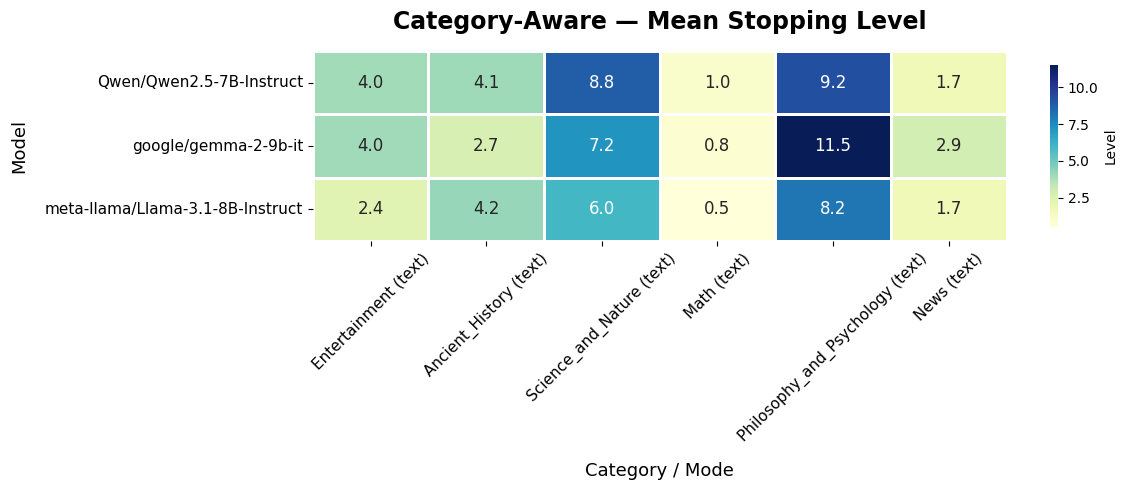

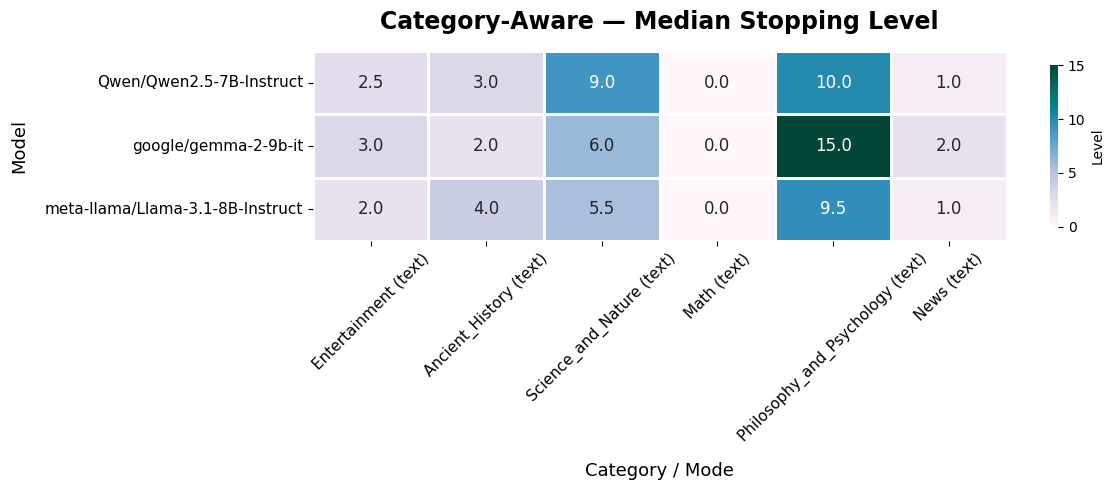

In [ ]:
# ==================================================
# S2 — CATEGORY-AWARE HEATMAPS, SEPARATE FIGURES
# ==================================================

plot_single_metric_heatmap(
    pivot_mean_s2,
    title="Category-Aware — Mean Stopping Level",
    cmap="YlGnBu",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "category_aware_mean_stopping_level.png",
)

plot_single_metric_heatmap(
    pivot_median_s2,
    title="Category-Aware — Median Stopping Level",
    cmap="PuBuGn",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "category_aware_median_stopping_level.png",
)

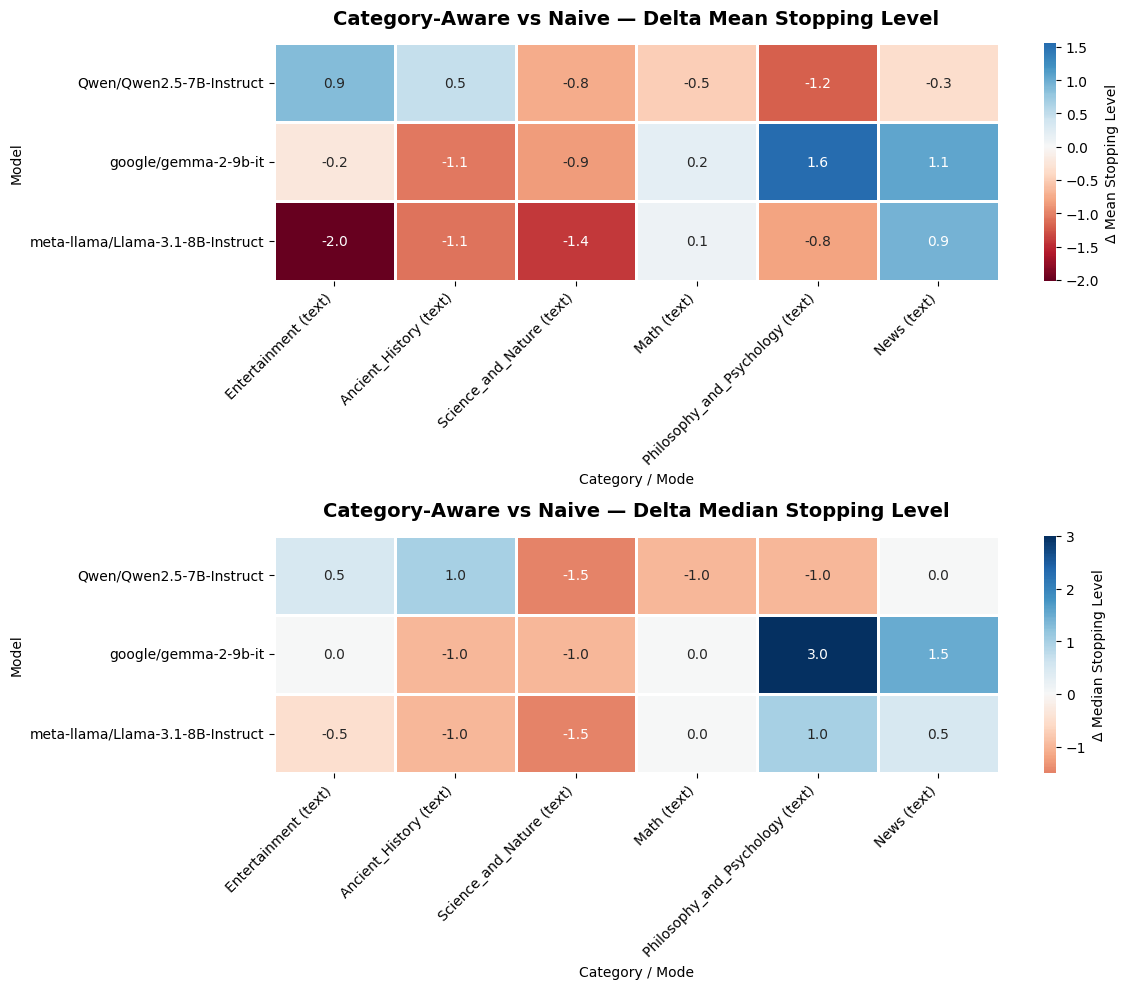

In [ ]:
# ==================================================
# S2 — DELTA VS NAIVE BASELINE (MEAN + MEDIAN)
# ==================================================

common_models = pivot_mean_s2.index.intersection(pivot_mean_naive.index)
common_cols = pivot_mean_s2.columns.intersection(pivot_mean_naive.columns)

delta_mean = (
    pivot_mean_s2.loc[common_models, common_cols]
    - pivot_mean_naive.loc[common_models, common_cols]
)
delta_median = (
    pivot_median_s2.loc[common_models, common_cols]
    - pivot_median_naive.loc[common_models, common_cols]
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, data, metric in zip(axes, [delta_mean, delta_median], ["Mean", "Median"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".1f",
        cmap="RdBu",
        center=0,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": f"Δ {metric} Stopping Level"},
        ax=ax,
    )
    ax.set_title(
        f"Category-Aware vs Naive — Delta {metric} Stopping Level",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Category / Mode")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()

save_path = HEATMAPS_DIR / "delta_category_aware_vs_naive_mean_median_stopping_level.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## **S2 — Results**

Category-aware prompting provides clearer context for each competition, but the **improvement over the naive baseline is limited and not uniform**. The delta heatmap shows mixed effects: **some model-category pairs improve slightly**, while **others decrease in mean stopping level**.

Since category-aware prompting does not provide a consistent improvement, the **naive prompt is kept as the default fallback** in later sections.

# **S3 — Speech Mode: Audio-to-Text**

## **Objective**

In this section, we evaluate the quiz system in **speech mode**. Unlike text mode, where questions and answer options are directly available as text, speech mode provides them as audio files.

The **goal is to measure the end-to-end impact of adding an automatic speech recognition (ASR)** step before the standard text-based answering pipeline. We **first evaluate an initial setup based on** `openai/whisper-small`, then **refine the ASR preprocessing pipeline** and evaluate the updated setup with `openai/whisper-large-v3-turbo`.

**Since no ground-truth transcripts are available, this section does not directly measure ASR quality with WER**. Instead, it evaluates final quiz performance, stopping level, and latency.

## **Method**

The speech-mode pipeline follows three steps:


*   The question and answer options are received as audio files.
*   Each audio file is transcribed into text using a Whisper-based speech-to-text model.
*   The transcribed text is passed to the same naive multiple-choice prompt used in the text baseline.


After transcription, the rest of the pipeline remains unchanged: the model receives a text question, text options, and must return the answer in the format:

```text
FINAL_ANSWER: <id>

## **S3.1 — Initial Speech Baseline with Whisper Small**

As an initial speech-mode baseline, we used `openai/whisper-small` with a **minimal ASR setup**. The transcribed question and options were passed directly to the same naive answering pipeline used in text mode.

This **first experiment was useful to identify typical speech-mode issues, such as noisy option transcriptions, hallucinated option prefixes, repeated fragments, and unstable transcriptions of numbers or named entities**.

In [ ]:
# ==================================================
# S3.1 — INITIAL SPEECH BASELINE WITH WHISPER SMALL
# ==================================================

from types import SimpleNamespace
from transformers import pipeline
import tempfile

SPEECH_MODE = "speech"
ASR_MODEL_ID = "openai/whisper-small"

_ASR_PIPE = None

# Normalize whitespace in the raw ASR transcript
def clean_transcript(text: str) -> str:
    return re.sub(r"\s+", " ", text or "").strip()

# Detect missing or unusable transcripts before sending them to the LLM
def is_empty_or_bad(text: str) -> bool:
    return not text or len(text.strip()) < 2

#Load the selected ASR model once and reuse it across speech games
def get_asr_pipeline(model_id=None):
    global _ASR_PIPE

    if model_id is None:
        model_id = ASR_MODEL_ID

    if _ASR_PIPE is None:
        device = 0 if torch.cuda.is_available() else -1
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        print(f"Loading ASR model: {model_id} | device={device}")

        _ASR_PIPE = pipeline(
            "automatic-speech-recognition",
            model=model_id,
            device=device,
            torch_dtype=dtype,
        )

    return _ASR_PIPE

#Save WAV bytes temporarily, transcribe them, and return text, elapsed time, path.
def transcribe_audio_bytes(audio_bytes: bytes, prefix: str = "speech") -> tuple[str, float, str]:

    # get the ASR Model
    asr = get_asr_pipeline()

    #save the audio in the Drive
    with tempfile.NamedTemporaryFile(
        suffix=".wav",
        prefix=f"{prefix}_",
        delete=False,
        dir=SPEECH_AUDIO_DIR,
    ) as f:
        f.write(audio_bytes)
        wav_path = f.name

    t0 = time.time()

    # Transcribe the saved audio file with Whisper, forcing English transcription instead of translation.
    out = asr(
        wav_path,
        generate_kwargs={
            "language": "en",
            "task": "transcribe",
        },
    )

    elapsed = time.time() - t0

    text = out.get("text", "") if isinstance(out, dict) else str(out)
    text = re.sub(r"\s+", " ", text).strip()

    return text, elapsed, wav_path

In [ ]:
# ==================================================
# S3.1 — RUN INITIAL SPEECH BASELINE
# ==================================================

SPEECH_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    4: "Philosophy_and_Psychology",
    5: "News",
}

N_GAMES_PER_CAT = 5

_ASR_PIPE = None

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

df_speech_naive_small = run_experiment(
    client=client,
    categories=SPEECH_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_naive,
    model_id=MODEL_ID,
    run_prefix="speech_small",
    save_logs=True,
    play_params=play_params,
    logs_dir=SPEECH_LOGS_DIR_SMALL,
    mode="speech",
)

In [ ]:
# ==================================================
# S3.1 — LOAD WHISPER SMALL LOGS AND COMPUTE METRICS
# ==================================================

DESIRED_CATEGORY_COLS_SPEECH = [
    "Entertainment (speech)",
    "Ancient_History (speech)",
    "Science_and_Nature (speech)",
    "Philosophy_and_Psychology (speech)",
    "News (speech)",
]

df_speech_small = load_all_logs(SPEECH_LOGS_DIR_SMALL)

if df_speech_small.empty:
    raise RuntimeError("No speech logs found for Whisper Small.")

df_speech_small["mode"] = "speech"
df_speech_small["asr_setup"] = "Initial setup - openai/whisper-small"

df_speech_small["result"] = df_speech_small["result"].astype(str).str.lower()
df_speech_small["is_correct"] = df_speech_small["result"].eq("correct")
df_speech_small["level"] = pd.to_numeric(df_speech_small["level"], errors="coerce")
df_speech_small["elapsed_s"] = pd.to_numeric(df_speech_small.get("elapsed_s", 0), errors="coerce").fillna(0.0)
df_speech_small["asr_total_s"] = pd.to_numeric(df_speech_small.get("asr_total_s", 0), errors="coerce").fillna(0.0)
df_speech_small["llm_elapsed_s"] = pd.to_numeric(df_speech_small.get("llm_elapsed_s", 0), errors="coerce").fillna(0.0)

table_speech_small, label_table_speech_small = table_accuracy(df_speech_small)
table_speech_small = table_speech_small.reindex(columns=DESIRED_CATEGORY_COLS_SPEECH)

game_stats_speech_small = (
    df_speech_small
    .groupby(["asr_setup", "model_name", "competition_name", "mode", "session_id"], as_index=False)
    .agg(
        stopping_level=("is_correct", "sum"),
        answered_questions=("level", "size"),
        avg_asr_s=("asr_total_s", "mean"),
        avg_llm_s=("llm_elapsed_s", "mean"),
        avg_elapsed_s=("elapsed_s", "mean"),
        total_elapsed_s=("elapsed_s", "sum"),
    )
)

pivot_mean_speech_small = make_metric_pivot(
    game_stats_speech_small,
    metric_col="stopping_level",
    agg_fn="mean",
    desired_cols=DESIRED_CATEGORY_COLS_SPEECH,
)

pivot_median_speech_small = make_metric_pivot(
    game_stats_speech_small,
    metric_col="stopping_level",
    agg_fn="median",
    desired_cols=DESIRED_CATEGORY_COLS_SPEECH,
)

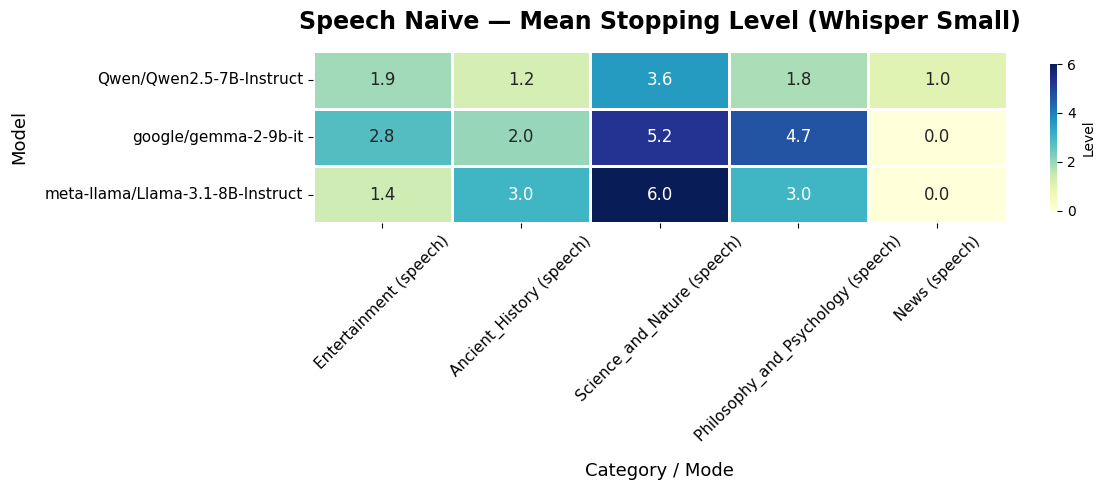

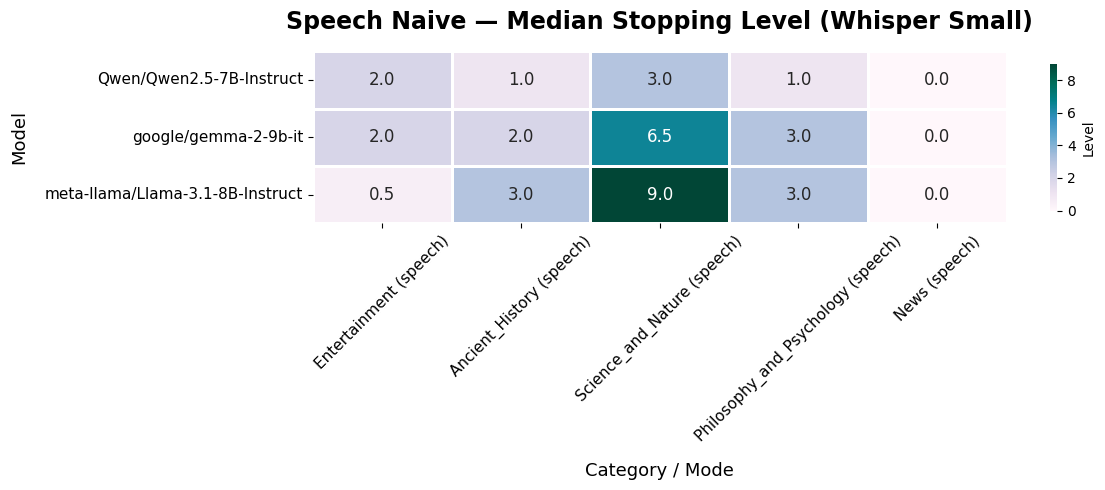

In [ ]:
# ==================================================
# S3.1 — WHISPER SMALL HEATMAPS
# ==================================================

plot_single_metric_heatmap(
    pivot_mean_speech_small,
    title="Speech Naive — Mean Stopping Level (Whisper Small)",
    cmap="YlGnBu",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "speech_small_mean_stopping_level.png",
)

plot_single_metric_heatmap(
    pivot_median_speech_small,
    title="Speech Naive — Median Stopping Level (Whisper Small)",
    cmap="PuBuGn",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "speech_small_median_stopping_level.png",
)

## **S3.2 — Final ASR Setup**

The **initial speech** baseline **showed that raw ASR transcripts can contain noisy artifacts, especially in answer options**. For this reason, we enhanced the speech preprocessing pipeline before running the final speech-mode evaluation.

The refined setup keeps the same text-based answering pipeline, but **improves the transcription preprocessing** by removing common option-prefix artifacts, limiting repeated fragments during generation, trimming unstable repetitions, and filtering empty or unusable transcripts before passing the text to the LLM.

In [ ]:
# ==================================================
# S3.2 — REFINED ASR SETUP
# ==================================================

warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

ASR_MODEL_ID = "openai/whisper-large-v3-turbo"

# Remove common ASR hallucinated prefixes before option text.
_OPTION_PREFIX_RE = re.compile(
    r"^\s*(?:option|opsin|obsin|ops?\s+in|ups?\s+and|opt\.?|ops?\s+and|abs?in|absin)\s*[a-d]\s*[\.,!?:]?\s*",
    flags=re.IGNORECASE,
)

# Detect repeated words or characters often produced by unstable transcriptions.
_REPETITION_RE = re.compile(r"(\b\w+\b)([\s\.,!?]+\1){2,}", flags=re.IGNORECASE)
_CHAR_REPETITION_RE = re.compile(r"(.)\1{3,}")

# Reset ASR cache before loading the refined model.
_ASR_PIPE = None


# Save audio bytes to a temporary WAV file, transcribe it, and return text, latency, and path.
def transcribe_audio_bytes(audio_bytes: bytes, prefix: str = "speech") -> tuple[str, float, str]:
    asr = get_asr_pipeline(ASR_MODEL_ID)

    with tempfile.NamedTemporaryFile(
        suffix=".wav",
        prefix=f"{prefix}_",
        delete=False,
        dir=SPEECH_AUDIO_DIR,
    ) as f:
        f.write(audio_bytes)
        wav_path = f.name

    t0 = time.time()

    out = asr(
        wav_path,
        generate_kwargs={
            "language": "en",
            "task": "transcribe",
            "no_repeat_ngram_size": 3,
        },
    )

    elapsed = time.time() - t0

    text = out.get("text", "") if isinstance(out, dict) else str(out)
    text = re.sub(r"\s+", " ", text).strip()

    return text, elapsed, wav_path


# Normalize ASR output by removing prefixes, repetitions, and trailing punctuation.
def clean_transcript(text: str) -> str:
    if not text:
        return ""

    t = text.strip()
    t = _OPTION_PREFIX_RE.sub("", t)

    m = _REPETITION_RE.search(t)
    if m:
        t = t[:m.start()].rstrip(" ,.!?") + " [...]"

    t = _CHAR_REPETITION_RE.sub(lambda m: m.group(1), t)
    t = re.sub(r"\s+", " ", t).strip()
    t = re.sub(r"[\.!?,;:]+$", "", t).strip()

    return t


# Detect empty or unusable transcripts before passing them to the LLM.
def is_empty_or_bad(text: str) -> bool:
    if not text or len(text) < 2:
        return True
    if re.fullmatch(r"[\W_]+", text):
        return True
    return False

In [ ]:
# ==================================================
# S3.2 — RUN FINAL SPEECH SETUP
# ==================================================

SPEECH_CATEGORIES_FINAL = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    4: "Philosophy_and_Psychology",
    5: "News",
}

N_GAMES_PER_CAT_SPEECH_FINAL = 5

print("ASR model:", ASR_MODEL_ID)

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

df_speech_final_run = run_experiment(
    client=client,
    categories=SPEECH_CATEGORIES_FINAL,
    n_games_per_cat=N_GAMES_PER_CAT_SPEECH_FINAL,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_naive,
    model_id=MODEL_ID,
    run_prefix="speech_final",
    save_logs=True,
    play_params=play_params,
    logs_dir=SPEECH_LOGS_DIR_LARGE,
    mode="speech",
)

In [ ]:
# ==================================================
# S3.2 — LOAD FINAL SPEECH LOGS AND COMPUTE METRICS
# ==================================================

df_speech_final = load_all_logs(SPEECH_LOGS_DIR_LARGE)

if df_speech_final.empty:
    raise RuntimeError("No final speech logs found.")

# Speech logs are speech by definition.
df_speech_final["mode"] = "speech"
df_speech_final["asr_setup"] = "Refined setup - openai/whisper-large-v3-turbo"

df_speech_final["result"] = df_speech_final["result"].astype(str).str.lower()
df_speech_final["is_correct"] = df_speech_final["result"].eq("correct")
df_speech_final["level"] = pd.to_numeric(df_speech_final["level"], errors="coerce")
df_speech_final["elapsed_s"] = pd.to_numeric(df_speech_final.get("elapsed_s", 0), errors="coerce").fillna(0.0)
df_speech_final["asr_total_s"] = pd.to_numeric(df_speech_final.get("asr_total_s", 0), errors="coerce").fillna(0.0)
df_speech_final["llm_elapsed_s"] = pd.to_numeric(df_speech_final.get("llm_elapsed_s", 0), errors="coerce").fillna(0.0)

table_speech_final, label_table_speech_final = table_accuracy(df_speech_final)
table_speech_final = table_speech_final.reindex(columns=DESIRED_CATEGORY_COLS_SPEECH)

game_stats_speech_final = (
    df_speech_final
    .groupby(["asr_setup", "model_name", "competition_name", "mode", "session_id"], as_index=False)
    .agg(
        stopping_level=("is_correct", "sum"),
        answered_questions=("level", "size"),
        avg_asr_s=("asr_total_s", "mean"),
        avg_llm_s=("llm_elapsed_s", "mean"),
        avg_elapsed_s=("elapsed_s", "mean"),
        total_elapsed_s=("elapsed_s", "sum"),
    )
)

pivot_mean_speech_final = make_metric_pivot(
    game_stats_speech_final,
    metric_col="stopping_level",
    agg_fn="mean",
    desired_cols=DESIRED_CATEGORY_COLS_SPEECH,
)

pivot_median_speech_final = make_metric_pivot(
    game_stats_speech_final,
    metric_col="stopping_level",
    agg_fn="median",
    desired_cols=DESIRED_CATEGORY_COLS_SPEECH,
)

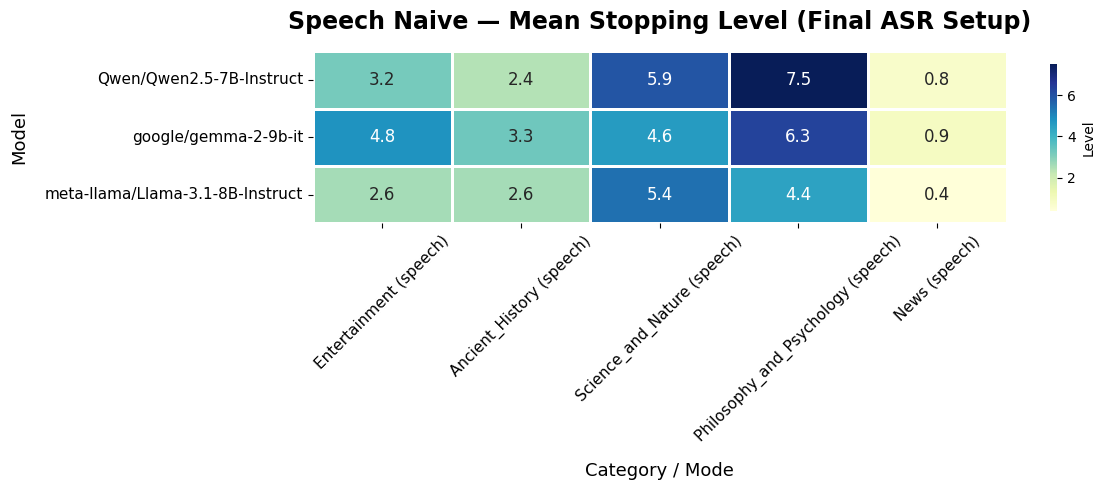

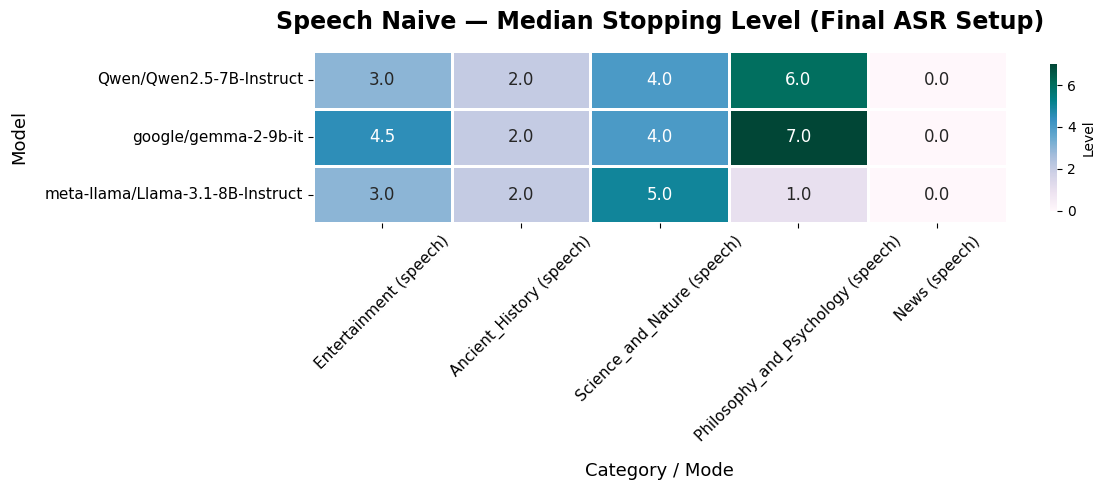

In [ ]:
# ==================================================
# S3.2 — FINAL SPEECH HEATMAPS
# ==================================================

plot_single_metric_heatmap(
    pivot_mean_speech_final,
    title="Speech Naive — Mean Stopping Level (Final ASR Setup)",
    cmap="YlGnBu",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "speech_final_mean_stopping_level.png",
)

plot_single_metric_heatmap(
    pivot_median_speech_final,
    title="Speech Naive — Median Stopping Level (Final ASR Setup)",
    cmap="PuBuGn",
    cbar_label="Level",
    save_path=HEATMAPS_DIR / "speech_final_median_stopping_level.png",
)

In [ ]:
# ==================================================
# S3.3 — FINAL SPEECH LATENCY SUMMARY
# ==================================================

latency_cols = [c for c in ["asr_total_s", "llm_elapsed_s", "elapsed_s"] if c in df_speech_final.columns]

if latency_cols:
    latency_summary_final = (
        df_speech_final
        .groupby("competition_name")[latency_cols]
        .mean()
        .round(2)
    )

    print("\n=== Average latency by category — final speech setup ===")
    display(latency_summary_final)


=== Average latency by category — final speech setup ===


,asr_total_s,llm_elapsed_s,elapsed_s
competition_name,,,
Ancient_History,1.85,1.07,2.92
Entertainment,2.01,1.01,3.02
News,1.95,1.07,3.02
Philosophy_and_Psychology,2.04,1.02,3.06
Science_and_Nature,1.87,0.99,2.86


## **S3 — Results**

**Speech mode introduces an additional source of error before the LLM receives the question**: the ASR transcription. **Since no ground-truth transcripts are available**, we do **not evaluate Whisper directly with WER or other transcription metrics**. Instead, we **evaluate the full speech pipeline end-to-end**, using final answer accuracy, stopping level, and latency.

The **initial `openai/whisper-small` setup showed that raw transcripts can contain noisy or unstable outputs**, especially in answer options, numbers, and named entities. Based on these observations, the **speech pipeline was refined by normalizing transcripts**, removing common option-prefix artifacts, trimming unstable repetitions, and filtering empty or unusable outputs before passing the text to the LLM.

The **refined setup with `openai/whisper-large-v3-turbo` was kept for the final speech experiments because it provided a more robust speech-processing configuration** while remaining within the 30-second time constraint. However, speech mode remains more fragile than text mode, since transcription errors can still alter key entities, dates, numbers, or formulas before the LLM receives the question.

# **S4 — RAG**

## **Objective**

In this section, we **extend the baseline system with a selective Retrieval-Augmented Generation (RAG) strategy**. The goal is to improve performance on knowledge-intensive categories where external evidence can help the model answer more reliably.

RAG is applied only to the knowledge-intensive competitions:

* **Entertainment**
* **Ancient History**
* **Science and Nature**
* **Philosophy and Psychology**
* **News**

For **Entertainment, Ancient History, Science and Nature, and Philosophy/Psychology, the system retrieves evidence from the Wikipedia MediaWiki API**.  
For **News**, the system uses two dedicated news sources:

* **The Guardian Content API**, used as the primary source when available because it provides article metadata and body text.
* **GNews API**, used as an additional/fallback source to retrieve recent news articles.

**Math is excluded because most mathematical questions require computation and symbolic reasoning rather than factual lookup**. In addition, retrieval may introduce extra latency or irrelevant context for this category.

<br>
<h3><b>RAG Pipeline for a Single Question</b></h3>

<div style="font-size:15px; display:flex; flex-direction:column; gap:8px; max-width:900px;">

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>1. Game question</b><br><code>play_automated</code> receives the question, options, category id, model, and tokenizer.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>2. RAG wrapper</b><br><code>ask_llm_retrieval_rag</code> checks whether retrieval can be used for the current category and time budget.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>3. Eligibility and time check</b><br>RAG is attempted only for categories 0, 1, 2, 4 and 5, and only if enough time is available.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>4. Source-specific retrieval</b><br>For categories 0, 1, 2 and 4, entities are extracted and Wikipedia pages are retrieved. For category 5, news queries are sent to dedicated news APIs.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>5. Chunking, ranking and reranking</b><br>Retrieved documents are split into chunks, ranked with BM25 + dense embeddings, and reranked with the BGE reranker.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>6. Confidence decision</b><br>If the retrieved evidence is strong enough, the model receives a RAG prompt. Otherwise, the system falls back to the naive prompt.</div>

<div style="text-align:center;">↓</div>

<div style="padding:10px; border:1px solid #ccc; border-radius:6px;"><b>7. Final answer</b><br>The model outputs <code>FINAL_ANSWER: &lt;id&gt;</code>, the answer is submitted, and logs are saved.</div>

</div>

In [ ]:
# ==================================================
# S4 - RAG ANALYSIS HELPERS
# ==================================================

# Prepare raw RAG logs for analysis by normalizing fields and detecting whether RAG was used.
def prepare_rag_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize raw RAG logs and extract debug fields for analysis."""
    df = df.copy()

    if df.empty:
        raise RuntimeError("No data collected.")

    df["mode"] = df.get("mode", "text")

    df["result"] = df["result"].astype(str).str.lower()
    df["is_correct"] = df["result"].eq("correct")
    df["level"] = pd.to_numeric(df["level"], errors="coerce")
    df["elapsed_s"] = pd.to_numeric(df.get("elapsed_s", 0), errors="coerce").fillna(0.0)

    df["raw_output"] = df["raw_output"].astype(str)

    # Extract RAG debug tags written by ask_llm_retrieval_rag.
    df["used_rag"] = (
        df["raw_output"]
        .str.extract(r"\[RAG=(True|False)\]", expand=False)
        .map({"True": True, "False": False})
        .fillna(False)
    )

    df["rerank_top"] = pd.to_numeric(
        df["raw_output"].str.extract(r"\[RERANK_TOP=([0-9.]+)\]", expand=False),
        errors="coerce",
    )
    df["opt_top"] = pd.to_numeric(
        df["raw_output"].str.extract(r"\[OPT_TOP=([0-9.]+)\]", expand=False),
        errors="coerce",
    )
    df["opt_spread"] = pd.to_numeric(
        df["raw_output"].str.extract(r"\[OPT_SPREAD=([0-9.]+)\]", expand=False),
        errors="coerce",
    )
    df["nq"] = pd.to_numeric(
        df["raw_output"].str.extract(r"\[NQ=([0-9]+)\]", expand=False),
        errors="coerce",
    )
    df["timeout_reason"] = df["raw_output"].str.extract(
        r"\[TIMEOUT=([^\]]+)\]",
        expand=False,
    )

    df["retrieved"] = df["nq"].fillna(0) > 0

    if "run_uid" not in df.columns:
        df["run_uid"] = df["session_id"].astype(str)

    return df

# Aggregate question-level logs into game-level metrics such as stopping level, accuracy, latency, and RAG usage.
def compute_game_stats(df: pd.DataFrame) -> pd.DataFrame:
    game_stats = (
        df.groupby(["model_name", "competition_id", "mode", "competition_name", "run_uid"], as_index=False)
          .agg(
              stopping_level=("is_correct", "sum"),
              answered_questions=("level", "size"),
              correct_answers=("is_correct", "sum"),
              avg_elapsed_s=("elapsed_s", "mean"),
              total_elapsed_s=("elapsed_s", "sum"),
              rag_usage=("used_rag", "mean"),
          )
    )

    game_stats["accuracy"] = game_stats["correct_answers"] / game_stats["answered_questions"]
    return game_stats

# Plot median and mean stopping-level heatmaps for the RAG experiments.
def plot_rag_stopping_heatmaps(
    pivot_median: pd.DataFrame,
    pivot_mean: pd.DataFrame,
    save_path: Path | None = None,
):
    n_rows, n_cols = pivot_mean.shape

    fig_width = max(14, n_cols * 1.8)
    fig_height = max(10, n_rows * 1.8 * 2)

    fig, axes = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=False)

    sns.heatmap(
        pivot_median,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Level", "shrink": 0.85},
        annot_kws={"size": 11},
        ax=axes[0],
    )
    axes[0].set_title("Median Stopping Level per Game", fontsize=16, fontweight="bold", pad=14)
    axes[0].set_xlabel("Category / Mode", fontsize=12, labelpad=10)
    axes[0].set_ylabel("Model", fontsize=12, labelpad=10)

    sns.heatmap(
        pivot_mean,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Level", "shrink": 0.85},
        annot_kws={"size": 11},
        ax=axes[1],
    )
    axes[1].set_title("Mean Stopping Level per Game", fontsize=16, fontweight="bold", pad=14)
    axes[1].set_xlabel("Category / Mode", fontsize=12, labelpad=10)
    axes[1].set_ylabel("Model", fontsize=12, labelpad=10)

    for ax in axes:
        ax.tick_params(axis="x", labelrotation=45, labelsize=11)
        ax.tick_params(axis="y", labelrotation=0, labelsize=11)

    fig.suptitle(
        "RAG Performance Summary",
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Build RAG summary tables and visualizations from the collected logs.
def show_rag_summary(
    df: pd.DataFrame,
    categories: dict[int, str],
    split_by_mode: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = prepare_rag_dataframe(df)
    game_stats = compute_game_stats(df)

    if split_by_mode:
        desired_cols = [
            f"{categories[c]} ({mode})"
            for c in sorted(categories)
            for mode in ["text", "speech"]
        ]
    else:
        desired_cols = [categories[c] for c in sorted(categories)]

    pivot_median = make_metric_pivot(
        game_stats,
        metric_col="stopping_level",
        agg_fn="median",
        desired_cols=desired_cols,
        split_by_mode=split_by_mode,
    )

    pivot_mean = make_metric_pivot(
        game_stats,
        metric_col="stopping_level",
        agg_fn="mean",
        desired_cols=desired_cols,
        split_by_mode=split_by_mode,
    )
    plot_rag_stopping_heatmaps(
        pivot_median,
        pivot_mean,
        save_path=HEATMAPS_DIR / "rag_stopping_level_summary.png",
    )

    return df, game_stats, pivot_mean, pivot_median

#Plot question-level accuracy for RAG ON vs RAG OFF by category and mode.
def plot_rag_on_off_accuracy_only(
    df: pd.DataFrame,
    save_path: Path | None = None,
) -> pd.DataFrame:
    """Plot only the RAG ON vs OFF question-level accuracy by category and mode."""
    df = prepare_rag_dataframe(df)

    on_off = (
        df.groupby(["competition_name", "mode", "used_rag"])["is_correct"]
        .agg(n_questions="count", accuracy="mean")
        .reset_index()
    )

    on_off["RAG"] = on_off["used_rag"].map({
        False: "RAG OFF",
        True: "RAG ON",
    })

    on_off["category_mode"] = (
        on_off["competition_name"].astype(str).str.replace("_", " ")
        + " ("
        + on_off["mode"].astype(str)
        + ")"
    )

    on_off["accuracy_%"] = (on_off["accuracy"] * 100).round(1)

    fig_width = max(14, on_off["category_mode"].nunique() * 1.5)

    plt.figure(figsize=(fig_width, 6))
    ax = sns.barplot(
        data=on_off,
        x="category_mode",
        y="accuracy",
        hue="RAG",
        hue_order=["RAG OFF", "RAG ON"],
    )

    ax.set_title("RAG ON vs OFF Accuracy", fontsize=18, fontweight="bold", pad=14)
    ax.set_xlabel("")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.legend(title="")

    plt.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return on_off

In [ ]:
# ================================
# S4 - KNOWLEDGE RETRIEVAL RAG
# ================================

try:
    from FlagEmbedding import FlagReranker
except Exception:
    FlagReranker = None

try:
    from sentence_transformers import CrossEncoder
except Exception:
    CrossEncoder = None

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# ====================
# WIKIPEDIA API CONFIG
# =====================

# Wikipedia API endpoint used to search and retrieve page extracts.
WIKI_API = "https://en.wikipedia.org/w/api.php"

# Headers sent to Wikipedia; the User-Agent identifies the project/requester.
WIKI_HEADERS = {
    "User-Agent": "NLP-RAG-Research/1.0 (luca1.bordin@mail.polimi.it)"
}


# ==================
# MODEL CONFIG
# ==================

# Embedding model used for dense semantic retrieval.
EMBEDDER_MODEL_NAME = "BAAI/bge-base-en-v1.5"

# Cross-encoder/reranker model used to rerank retrieved chunks.
RERANKER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"


# ===========================
# WIKIPEDIA RETRIEVAL CONFIG
# ===========================

# Maximum number of Wikipedia titles returned for each search query.
WIKI_TITLES_PER_QUERY = 4

# Timeout, in seconds, for each individual Wikipedia API request.
WIKI_REQUEST_TIMEOUT_S = 3.0

# Total time budget, in seconds, for fetching Wikipedia pages.
WIKI_FETCH_DEADLINE_S = 8.0

# Hard maximum time budget, in seconds, for the whole Wikipedia RAG pipeline.
RAG_HARD_TIMEOUT_S = 15.0


# ============================
# CHUNKING AND RANKING CONFIG
# ============================

# Maximum character length of each retrieved text chunk.
CHUNK_SIZE_CHARS = 1400

# Number of overlapping characters between consecutive chunks.
CHUNK_OVERLAP = 200

# Maximum number of chunks generated from each Wikipedia page.
MAX_CHUNKS_PER_PAGE = 8

# Number of chunks kept after the first-stage BM25 + embedding retrieval.
FIRST_STAGE_K = 10

# Number of final context chunks kept after reranking.
CONTEXT_TOP_K = 5

# Batch size used when computing embeddings.
EMBED_BATCH_SIZE = 32

# Batch size used when computing reranker scores.
RERANK_BATCH_SIZE = 16


# ==================
# TEXT PREPROCESSING CONFIG
# ==================

# English stopwords removed during query/token processing.
STOPWORDS = set(stopwords.words("english"))

# Generic quiz words removed because they do not help retrieval.
QUIZ_NOISE = set("""
term terms describes describe following option options answer question correct false true
choose select indicate identify according best most likely primary main article passage
""".split())


# ==================
# NEWS RAG CONFIG
# ==================

# Competition/category ID used for the News RAG pipeline.
NEWS_COMP_ID = 5

# GNews API key loaded from Colab user secrets.
GNEWS_API_KEY = userdata.get("GNews_API")

# Guardian API key loaded from Colab user secrets.
GUARDIAN_API_KEY = userdata.get("GUARDIAN_API_KEY")

# Number of news results requested for each news query.
NEWS_RESULTS_PER_QUERY = 3

# Maximum number of news articles kept for one retrieval call.
NEWS_MAX_ARTICLES = 6

# Total time budget, in seconds, for fetching news articles.
NEWS_FETCH_DEADLINE_S = 5.0

# Hard maximum time budget, in seconds, for the whole News RAG pipeline.
NEWS_HARD_TIMEOUT_S = 8.0

# ===============
# OPTION HELPERS
# ===============

# Return the option ID, supporting both dictionary-style and object-style options.
def get_opt_id(o):
    return o.get("id") if isinstance(o, dict) else getattr(o, "id")

# Return the option text, supporting both dictionary-style and object-style options.
def get_opt_text(o):
    return o.get("text", "") if isinstance(o, dict) else getattr(o, "text", "")

# Format all answer options as a readable text block for prompts and reranking.
def _options_block(options):
    return "\n".join(f"{get_opt_id(o)}) {get_opt_text(o)}" for o in (options or []))


# ===================================================
# TOKENIZATION, ENTITY EXTRACTION AND QUERY BUILDING
# ===================================================

TOKEN_RE = re.compile(r"[A-Za-z0-9][A-Za-z0-9\-]{2,}")

#math acronyms
ACRONYM_RE = re.compile(r"\b[A-Z]{2,}(?:\.[A-Z]{1,})*\b")

# Match title-case entity spans such as "Roman Empire" or "Battle of Actium".
ENTITY_RE = re.compile(r"\b[A-Z][A-Za-z0-9'’\-]+(?:\s+(?:of|the|and|&|de|di|da|del|della|van|von|al|[A-Z][A-Za-z0-9'’\-]+))*\b")

# Match roman numerals
ROMAN_RE = re.compile(r"\b[IVX]{2,}\b")

# Match years, including historical formats such as 44 BC or 476 CE.
YEAR_RE = re.compile(r"\b\d{3,4}\s*(?:BC|BCE|AD|CE)?\b", re.IGNORECASE)

# Question-leading words removed from extracted entities when needed.
QUESTION_STARTERS = {"What", "Which", "Who", "When", "Where", "Why", "How",
                     "In", "During", "Following", "According"}

# ====================
# GLiNER CONFIGURATION
# ====================

GLINER_MODEL_NAME = "urchade/gliner_medium-v2.1"

# Minimum confidence required to keep a GLiNER entity.
GLINER_THRESHOLD = 0.30

# Generic entity labels used for all Wikipedia categories.
GLINER_LABELS_BASE = ["person", "place", "organization", "event", "year", "date"]

# Extra GLiNER labels selected according to the quiz competition/category.
GLINER_LABELS_BY_COMP = {
    0: ["movie", "tv show", "book", "song", "album", "actor", "director", "character"],

    1: ["civilization", "empire", "dynasty", "battle", "war", "treaty",
        "ruler", "ancient city", "deity", "artifact"],

    2: ["species", "animal", "plant", "chemical element", "compound", "disease",
        "organ", "scientific theory", "natural phenomenon", "scientist"],

    4: ["philosopher", "psychologist", "theory", "school of thought",
        "philosophical concept", "psychological concept", "experiment",
        "cognitive bias", "mental disorder", "therapy", "book"],
}

# Labels that add useful disambiguation terms for Wikipedia search.
ENTITY_LABEL_HINTS = {
    # Entertainment
    "movie": "film",
    "tv show": "television series",

    # Philosophy and Psychology
    "school of thought": "philosophy",
    "cognitive bias": "psychology",
    "mental disorder": "psychology",
}

# Return the base GLiNER labels plus category-specific labels, if available.
def get_labels_for_comp(comp_id):
    return GLINER_LABELS_BASE + GLINER_LABELS_BY_COMP.get(comp_id, [])

# Try to import GLiNER; if it is not installed, the system will use regex fallback only.
try:
    from gliner import GLiNER
except Exception:
    GLiNER = None

# Convert text into useful lowercase tokens for BM25/query processing.
def tokenize(text):
    out = []
    for w in TOKEN_RE.findall(text or ""):
        lw = w.lower()
        if lw not in STOPWORDS and lw not in QUIZ_NOISE:
            out.append(lw)
    return out

# Cache the GLiNER model so it is loaded only once.
# If not available, return None and keep regex fallback active
@lru_cache(maxsize=1)
def _get_gliner_model():
    if GLiNER is None:
        return None
    try:
        return GLiNER.from_pretrained(GLINER_MODEL_NAME)
    except Exception as e:
        print(f"[gliner] disabled: {type(e).__name__}: {e}")
        return None

# Validate whether an extracted entity is meaningful enough to keep.
def _entity_is_valid(text):
    text = (text or "").strip(" .,;:!?()[]{}\"'")
    key = text.lower()
    if not text or key in STOPWORDS or key in QUIZ_NOISE:
        return False
    if len(text) < 2:
        return False
    if len(text.split()) == 1 and key in {"question", "answer", "option", "following"}:
        return False
    return True

# Clean raw entity text before validation and use in queries.
def _clean_entity_text(text):
    text = re.sub(r"\s+", " ", text or "").strip(" .,;:!?()[]{}\"'")
    words = text.split()
    if words and words[0] in QUESTION_STARTERS:
        words = words[1:]
    return " ".join(words).strip()

# Extract entities using regex rules as a fast fallback when GLiNER is unavailable or fails.
def extract_entities_regex(text):
    entities, seen = [], set()

    def add(x, label="regex"):
        x = _clean_entity_text(x)
        key = x.lower()
        if _entity_is_valid(x) and key not in seen:
            seen.add(key)
            entities.append({"text": x, "label": label, "score": 0.0, "source": "regex"})

    for ac in ACRONYM_RE.findall(text or ""):
        add(ac, "acronym")
    for ent in ENTITY_RE.findall(text or ""):
        add(ent, "entity")
    for rn in ROMAN_RE.findall(text or ""):
        add(rn, "roman")
    for year in YEAR_RE.findall(text or ""):
        add(year, "year")
    return entities

#GLiNER zero-shot NER + regex fallback.
def extract_typed_entities(text, use_gliner=True, comp_id=None):

    text = text or ""
    regex_entities = extract_entities_regex(text)
    gliner_entities = []

    model = _get_gliner_model() if use_gliner else None
    if model is not None and text.strip():
        try:
            #Choose the labels based on the category
            labels = get_labels_for_comp(comp_id) if comp_id is not None else GLINER_LABELS_BASE

            preds = model.predict_entities(text, labels, threshold=GLINER_THRESHOLD)
            for p in preds:
                ent_text = _clean_entity_text(p.get("text", ""))
                label = str(p.get("label", "entity")).lower()
                score = float(p.get("score", 0.0))
                if _entity_is_valid(ent_text):
                    gliner_entities.append({
                        "text": ent_text,
                        "label": label,
                        "score": score,
                        "source": "gliner",
                    })
        except Exception as e:
            print(f"[gliner_predict] fallback to regex: {type(e).__name__}: {e}")

    # GLiNER first, regex second
    out, seen = [], set()
    for ent in sorted(gliner_entities, key=lambda x: x.get("score", 0.0), reverse=True) + regex_entities:
        key = ent["text"].lower()
        if key not in seen:
            seen.add(key)
            out.append(ent)
    return out


# Track already-seen lowercase items and preserve the original order.
def _dedupe_keep_order(items):
    seen, out = set(), []
    for x in items:
        x = (x or "").strip()
        key = x.lower()
        if x and key not in seen:
            seen.add(key)
            out.append(x)
    return out

#Add a light Wikipedia disambiguation hint when the entity type is useful.
def _entity_query(ent):
    text = ent.get("text", "").strip()
    label = ent.get("label", "")
    hint = ENTITY_LABEL_HINTS.get(label)
    if hint and hint.lower() not in text.lower():
        return f"{text} {hint}"
    return text

# Add relation/context keywords from the question
def _relation_keywords(question_text, max_terms=4):
    tokens = [t for t in tokenize(question_text) if len(t) > 3]
    bad = {"what", "which", "following", "option", "answer", "question", "correct"}
    rel = [t for t in tokens if t not in bad]
    return rel[:max_terms]


#Build symmetric Wikipedia search queries for multiple-choice QA.
def build_queries(question_text, options, comp_id=None):

    #extract entities
    q_entities_typed = extract_typed_entities(question_text, comp_id=comp_id)
    q_entities = _dedupe_keep_order([_entity_query(e) for e in q_entities_typed])
    relation_terms = _relation_keywords(question_text)

    # Use the main extracted entity as the query anchor when available.
    if q_entities:
        anchor = q_entities[0]

    # If no entity was found, use the first relation keywords as fallback anchor.
    elif relation_terms:
        anchor = " ".join(relation_terms[:2])
    else:
        anchor = ""

    # Build one symmetric Wikipedia query for each answer option.
    per_option_queries = {}

    #Iterate over all answer options
    for opt in (options or []):
        oid = get_opt_id(opt)
        opt_text = get_opt_text(opt).strip()
        if opt_text and len(opt_text) > 2:
            if anchor:
                per_option_queries[oid] = f"{opt_text} {anchor}"
            else:
                per_option_queries[oid] = opt_text

    # Build neutral queries based only on the question.
    neutral_queries = []
    if q_entities and relation_terms:
        neutral_queries.append(" ".join((q_entities[:2] + relation_terms[:2])[:4]))
    if q_entities:
        neutral_queries.append(" ".join(q_entities[:3]))

    # If no entity-based query exists, fall back to the most useful question tokens.
    if not neutral_queries:
        q_tokens = [t for t in tokenize(question_text) if len(t) > 3]
        if q_tokens:
            neutral_queries.append(" ".join(q_tokens[:5]))

    neutral_queries = _dedupe_keep_order(neutral_queries)

    return per_option_queries, neutral_queries


# get the question and the options and return a single string
def build_rank_query(question_text, options):
    return f"Question: {question_text}\nOptions:\n{_options_block(options)}"


# ==============
# Wikipedia API
# ==============

# Cache Wikipedia search results to avoid repeating identical API calls.
@lru_cache(maxsize=4096)
# returns titles of a given query
def _wiki_search(query, n_titles=WIKI_TITLES_PER_QUERY):
    if not query:
        return tuple()
    try:
        r = requests.get(
            WIKI_API,
            headers=WIKI_HEADERS,
            timeout=WIKI_REQUEST_TIMEOUT_S,
            params={
                "action": "query",
                "list": "search",
                "srsearch": query,
                "srlimit": int(n_titles),
                "srprop": "",
                "srsort": "relevance",
                "format": "json",
                "formatversion": 2,
            },
        )
        r.raise_for_status()
        hits = r.json().get("query", {}).get("search", [])
        return tuple(h.get("title", "") for h in hits if h.get("title"))
    except Exception as e:
        print(f"[wiki_search] {query!r}: {type(e).__name__}: {e}")
        return tuple()

# Cache extracted pages to avoid downloading the same page multiple times.
@lru_cache(maxsize=4096)
# get the content of a page given the title
def _wiki_extract(title):
    if not title:
        return None, ""
    try:
        r = requests.get(
            WIKI_API,
            headers=WIKI_HEADERS,
            timeout=WIKI_REQUEST_TIMEOUT_S,
            params={
                "action": "query",
                "prop": "extracts",
                "explaintext": 1,
                "exsectionformat": "plain",
                "redirects": 1,
                "titles": title,
                "format": "json",
                "formatversion": 2,
            },
        )
        r.raise_for_status()
        pages = r.json().get("query", {}).get("pages", [])
        if not pages:
            return None, ""
        page = pages[0]
        text = re.sub(r"\s+", " ", page.get("extract") or "").strip()
        return page.get("title") or title, text
    except Exception as e:
        print(f"[wiki_extract] {title!r}: {type(e).__name__}: {e}")
        return None, ""



# Fetch Wikipedia pages for the current multiple-choice question.
# The function first searches pages separately for each answer option, then adds
# neutral question-only pages for general context. It downloads the selected page
# extracts in parallel and returns both the page contents and a mapping that tells
# which option, if any, retrieved each page. This mapping is later used to score
# each answer option against its own evidence.

def get_wiki_pages_per_option(per_option_queries, neutral_queries,
                              max_pages_per_option=2, max_neutral_pages=4,
                              deadline_s=WIKI_FETCH_DEADLINE_S):

    t0 = time.time()
    titles_order = []
    seen_titles = set()

    #Search pages for each answer option first
    for opt_id, query in per_option_queries.items():
        if time.time() - t0 > deadline_s * 0.40:
            break
        titles = _wiki_search(query, n_titles=max_pages_per_option + 1)
        added = 0
        for title in titles:
            if added >= max_pages_per_option:
                break
            key = title.lower()
            if key not in seen_titles:
                seen_titles.add(key)
                titles_order.append((title, opt_id))
                added += 1

    #Search additional neutral pages based only on the question.
    neutral_added = 0
    for query in neutral_queries:
        if time.time() - t0 > deadline_s * 0.55:
            break
        if neutral_added >= max_neutral_pages:
            break
        titles = _wiki_search(query, n_titles=WIKI_TITLES_PER_QUERY)
        for title in titles:
            if neutral_added >= max_neutral_pages:
                break
            key = title.lower()
            if key not in seen_titles:
                seen_titles.add(key)
                titles_order.append((title, None))
                neutral_added += 1

    if not titles_order:
        return [], {}

     # Build a mapping from the originally searched title to the option that found it.
    title_to_opt = {t: oid for t, oid in titles_order}
    pages, page_to_option = [], {}
    seen_final = set()
    remaining = max(0.5, deadline_s - (time.time() - t0))

    # Fetch page extracts in parallel, with at most 6 concurrent workers.
    with ThreadPoolExecutor(max_workers=min(6, len(titles_order))) as pool:
        futures = {pool.submit(_wiki_extract, t): t for t, _ in titles_order}
        try:
            for fut in as_completed(futures, timeout=remaining):
                if time.time() - t0 > deadline_s:
                    break
                try:
                    final_title, text = fut.result(timeout=0.1)
                except Exception:
                    continue
                if not (final_title and text and len(text) > 250):
                    continue
                key = final_title.lower()
                if key in seen_final:
                    continue
                seen_final.add(key)

                original_title = futures[fut]
                opt_id = title_to_opt.get(original_title)
                pages.append({"title": final_title, "content": text})
                page_to_option[final_title] = opt_id
        except FuturesTimeoutError:
            pass
        finally:
            for fut in futures:
                fut.cancel()

    return pages, page_to_option


# Score each option only against the chunks retrieved for that option.
# If an option has no dedicated chunks, fall back to neutral question-only chunks.
def score_chunks_per_option_isolated(question_text, options, all_chunks, page_to_option):

    if not options or not all_chunks:
        return {}

    neutral_chunks = [c for c in all_chunks if page_to_option.get(c["title"]) is None]

    per_option = {}
    for opt in options:
        oid = get_opt_id(opt)

        # Chunks only from pages retrieved by this specific option.
        own_chunks = [c for c in all_chunks if page_to_option.get(c["title"]) == oid]
        target_chunks = own_chunks if own_chunks else neutral_chunks

        if not target_chunks:
            per_option[oid] = {
                "chunk": None,
                "score": 0.0,
                "score_raw": -10.0,
                "from_own_page": False,
            }
            continue

        claim = f"Question: {question_text}\nCandidate answer: {get_opt_text(opt)}"
        pairs = [(claim, c["text"]) for c in target_chunks]
        raw = _reranker_raw_scores(pairs)
        prob = _sigmoid(raw)
        best_idx = int(np.argmax(raw))
        per_option[oid] = {
            "chunk": target_chunks[best_idx],
            "score": float(prob[best_idx]),
            "score_raw": float(raw[best_idx]),
            "from_own_page": bool(own_chunks),
        }

    return per_option

# =========
# CHUNKING
# =========
# Split Wikipedia page text into smaller overlapping chunks.
# Each chunk has up to about 1400 characters, with overlap to avoid losing context
# when relevant information is split across two consecutive chunks.

# Split a sentence that is longer than the target chunk size into smaller word-based chunks.
def _split_long_sentence(sentence, size):
    words = sentence.split()
    chunks, buf = [], []
    current_len = 0
    for w in words:
        if current_len + len(w) + 1 > size and buf:
            chunks.append(" ".join(buf))
            buf, current_len = [w], len(w)
        else:
            buf.append(w)
            current_len += len(w) + 1
    if buf:
        chunks.append(" ".join(buf))
    return chunks

# Split a document into sentence-aware overlapping chunks with a maximum number of chunks.
def chunk_text(text, size=CHUNK_SIZE_CHARS, overlap=CHUNK_OVERLAP,
               max_chunks=MAX_CHUNKS_PER_PAGE):
    if not text:
        return []

    raw_sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = []
    for s in raw_sentences:
        s = s.strip()
        if not s:
            continue
        if len(s) > size:
            sentences.extend(_split_long_sentence(s, size))
        else:
            sentences.append(s)

    chunks, buf = [], ""
    for s in sentences:
        if len(buf) + len(s) + 1 <= size:
            buf = (buf + " " + s).strip()
            continue

        if buf:
            chunks.append(buf)
        if len(chunks) >= max_chunks:
            break

        tail = chunks[-1][-overlap:] if overlap and chunks else ""
        buf = (tail + " " + s).strip() if tail else s

    if buf and len(chunks) < max_chunks:
        chunks.append(buf)
    return chunks


# ===================
# MODELS AND RANKING
# ===================

# Global cached model instances, loaded lazily only when first needed.
_EMBED_MODEL = None
_RERANKER = None
_RERANKER_BACKEND = None

# Load and cache the embedding model used for dense retrieval.
def _get_embed_model():
    global _EMBED_MODEL
    if _EMBED_MODEL is None:
        _EMBED_MODEL = SentenceTransformer(EMBEDDER_MODEL_NAME)
    return _EMBED_MODEL

# Load and cache the reranker model, preferring FlagReranker and falling back to CrossEncoder.
def _get_reranker():
    global _RERANKER, _RERANKER_BACKEND
    if _RERANKER is not None:
        return _RERANKER

    if FlagReranker is not None:
        try:
            _RERANKER = FlagReranker(RERANKER_MODEL_NAME, use_fp16=True)
            _RERANKER_BACKEND = "flag"
            return _RERANKER
        except Exception as e:
            print(f"[reranker] FlagReranker failed, trying CrossEncoder: {type(e).__name__}: {e}")

    if CrossEncoder is None:
        raise ImportError("Install FlagEmbedding or sentence-transformers CrossEncoder for the reranker.")

    try:
        _RERANKER = CrossEncoder(RERANKER_MODEL_NAME, trust_remote_code=True)
    except TypeError:
        _RERANKER = CrossEncoder(RERANKER_MODEL_NAME)
    _RERANKER_BACKEND = "cross_encoder"
    return _RERANKER


# Convert raw model scores into a bounded 0-1 score.
def _sigmoid(x):
    x = np.clip(np.asarray(x, dtype=float), -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))


# Compute raw reranker scores for query/passage pairs.
def _reranker_raw_scores(pairs):
    reranker = _get_reranker()
    formatted = [[q, p] for q, p in pairs]

    if _RERANKER_BACKEND == "flag":
        try:
            with open(os.devnull, "w") as devnull, redirect_stdout(devnull), redirect_stderr(devnull):
                scores = reranker.compute_score(
                    formatted,
                    batch_size=RERANK_BATCH_SIZE,
                    normalize=False,
                )
        except TypeError:
            scores = reranker.compute_score(formatted, batch_size=RERANK_BATCH_SIZE)
    else:
        scores = reranker.predict(
            formatted,
            batch_size=RERANK_BATCH_SIZE,
            show_progress_bar=False,
        )

    arr = np.asarray(scores, dtype=float)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    if arr.ndim > 1:
        arr = arr[:, 0]
    return arr


# First-stage chunk retrieval.
# This step scores all retrieved Wikipedia chunks with both BM25 lexical matching
# and dense embedding similarity, then combines the two rankings with RRF.
# It keeps only the top candidate chunks, which will later be reranked by a stronger model.
def rank_chunks_first_stage(rank_query, chunks, top_k=FIRST_STAGE_K, rrf_k=60):

    if not chunks:
        return []

    # Prepare raw chunk texts and tokenized versions for BM25 lexical scoring.
    texts = [c["text"] for c in chunks]
    q_tokens = tokenize(rank_query)
    tokenized_docs = [tokenize(t) for t in texts]

    # Compute BM25 scores, which reward exact or near-exact word overlap.
    if q_tokens and any(tokenized_docs):
        bm25 = BM25Okapi(tokenized_docs)
        bm25_scores = np.asarray(bm25.get_scores(q_tokens), dtype=float)
    else:
        bm25_scores = np.zeros(len(texts), dtype=float)

    # Convert BM25 scores into ranks, with rank 0 being the best chunk.
    bm25_rank = {i: r for r, i in enumerate(np.argsort(-bm25_scores))}

    # Encode the query and chunks with the dense embedding model.
    embedder = _get_embed_model()
    q_text = "Represent this sentence for searching relevant passages: " + rank_query

    q_emb = embedder.encode([q_text], normalize_embeddings=True, show_progress_bar=False)
    d_emb = embedder.encode(
        texts,
        normalize_embeddings=True,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
    )

    # Compute dense similarity scores between the query embedding and each chunk embedding.
    dense_scores = (d_emb @ q_emb.T).flatten()

    # Convert dense scores into ranks, with rank 0 being the best chunk.
    dense_rank = {i: r for r, i in enumerate(np.argsort(-dense_scores))}

    bm25_max = float(np.max(bm25_scores)) if len(bm25_scores) else 0.0
    ranked = []

    for i, chunk in enumerate(chunks):
        c = dict(chunk)
        # Store diagnostic scores from BM25 and dense retrieval.
        c["score_bm25_norm"] = float(bm25_scores[i] / bm25_max) if bm25_max > 0 else 0.0
        c["score_cos_abs"] = float(dense_scores[i])

        #Fuse BM25 and dense ranks with Reciprocal Rank Fusion.
        c["score_hybrid"] = float(
            1.0 / (rrf_k + bm25_rank[i] + 1) +
            1.0 / (rrf_k + dense_rank[i] + 1)
        )
        ranked.append(c)

    return sorted(ranked, key=lambda x: x["score_hybrid"], reverse=True)[:top_k]


# Stage 2: rerank the first-stage candidates with the stronger cross-encoder reranker.
def rerank_chunks(rank_query, candidates, top_k=CONTEXT_TOP_K):
    if not candidates:
        return []

    pairs = [(rank_query, c["text"]) for c in candidates]
    raw = _reranker_raw_scores(pairs)
    prob = _sigmoid(raw)

    ranked = []
    for c, raw_score, prob_score in zip(candidates, raw, prob):
        cc = dict(c)
        cc["score_rerank_raw"] = float(raw_score)
        cc["score_rerank"] = float(prob_score)
        ranked.append(cc)

    return sorted(ranked, key=lambda x: x["score_rerank_raw"], reverse=True)[:top_k]



# ===========================
# MAIN RETRIEVAL ENTRY POINT
# ============================


#Run the full Wikipedia RAG pipeline with symmetric option queries and isolated option scoring.
def retrieve_wikipedia_context(question_text, options, comp_id=None, top_k=CONTEXT_TOP_K, **kwargs):
    del kwargs
    t0 = time.time()

    # Build option-specific queries plus neutral question-only queries.
    per_option_queries, neutral_queries = build_queries(
        question_text, options, comp_id=comp_id
    )
    all_queries = list(per_option_queries.values()) + neutral_queries
    primary_query = all_queries[0] if all_queries else ""

    # Standard empty response used for failures or timeouts.
    def empty(reason):
        return {
            "queries": all_queries,
            "query": primary_query,
            "pages": [],
            "chunks": [],
            "context": "",
            "per_option": {},
            "best_score_abs": 0.0,
            "best_score_hybrid": 0.0,
            "best_score_rerank": 0.0,
            "opt_top": 0.0,
            "opt_spread": 0.0,
            "elapsed_s": time.time() - t0,
            "timeout_reason": reason,
        }

    if not all_queries:
        return empty("no_queries")

    # Fetch Wikipedia pages and keep track of which option retrieved each page.
    pages, page_to_option = get_wiki_pages_per_option(
        per_option_queries,
        neutral_queries,
        max_pages_per_option=2,
        max_neutral_pages=4,
        deadline_s=WIKI_FETCH_DEADLINE_S,
    )

    if time.time() - t0 > RAG_HARD_TIMEOUT_S:
        return empty("hard_timeout_after_fetch")
    if not pages:
        return empty("no_pages")

    # Split each page into chunks and preserve the option source for each chunk.
    all_chunks = []
    for page in pages:
        for idx, text in enumerate(chunk_text(page["content"])):
            all_chunks.append({
                "title": page["title"],
                "chunk_id": idx,
                "text": text,
                "opt_source": page_to_option.get(page["title"]),
            })
    if not all_chunks:
        return empty("no_chunks")

    # First-stage global retrieval: keep the strongest candidate chunks.
    rank_query = build_rank_query(question_text, options)
    first_stage = rank_chunks_first_stage(rank_query, all_chunks, top_k=FIRST_STAGE_K)
    if time.time() - t0 > RAG_HARD_TIMEOUT_S:
        return empty("hard_timeout_before_rerank")

    #Rerank first-stage candidates and keep the final context chunks.
    ranked = rerank_chunks(rank_query, first_stage, top_k=top_k)
    if time.time() - t0 > RAG_HARD_TIMEOUT_S:
        return empty("hard_timeout_after_rerank")

    #Score each option only against its own retrieved chunks.
    per_option = score_chunks_per_option_isolated(
        question_text, options, all_chunks, page_to_option
    )

    #Track the best option score and the margin between the top two options.
    if per_option:
        scores = sorted([v["score"] for v in per_option.values()], reverse=True)
        opt_top = scores[0]
        opt_spread = scores[0] - scores[1] if len(scores) > 1 else 0.0
    else:
        opt_top, opt_spread = 0.0, 0.0

    # Build the final textual context passed to the answer-generation step.
    context = "\n\n".join(
        f"[{i+1}] {c['title']} (score={c.get('score_rerank', 0.0):.2f}): {c['text']}"
        for i, c in enumerate(ranked)
    )

    best = ranked[0] if ranked else {}
    best_rerank = float(best.get("score_rerank", 0.0))
    return {
        "queries": all_queries,
        "query": primary_query,
        "pages": pages,
        "chunks": ranked,
        "context": context,
        "per_option": per_option,
        "best_score_abs": float(best.get("score_cos_abs", 0.0)),
        "best_score_hybrid": float(best.get("score_hybrid", 0.0)),
        "best_score_rerank": best_rerank,
        "opt_top": opt_top,
        "opt_spread": opt_spread,
        "elapsed_s": time.time() - t0,
        "timeout_reason": None,
    }




In [ ]:
# ====================
# S4 - NEWS RETRIEVAL
# ====================
# News retrieval uses shared context instead of option-isolated pages.
# Unlike Wikipedia, news evidence usually comes from event-level articles that may mention
# several answer options together, so each option is scored against the same retrieved articles.

# Match explicit dates in YYYY-MM-DD format inside news questions.
NEWS_DATE_RE = re.compile(r"\b(20\d{2}-\d{2}-\d{2})\b")


# Extract the publication/reference date from the question, if present.
def extract_news_date(question_text: str) -> str | None:
    m = NEWS_DATE_RE.search(question_text or "")
    return m.group(1) if m else None

# Build compact news search queries from the question and answer options.
def build_news_queries(question_text, options=None):

    # Extract the date first so news APIs can restrict results to the correct day.
    date = extract_news_date(question_text)

    # Remove boilerplate wording and dates from the question before query building.
    cleaned_q = re.sub(
        r"According to (the )?(article|news report) (published )?on \d{4}-\d{2}-\d{2},?",
        "",
        question_text or "",
        flags=re.I,
    )
    cleaned_q = re.sub(r"\b(On|As of)\s+\d{4}-\d{2}-\d{2},?", "", cleaned_q, flags=re.I)
    cleaned_q = re.sub(r"\b20\d{2}-\d{2}-\d{2}\b", "", cleaned_q)

    # Use the most informative question tokens as the main search anchor.
    q_terms = [t for t in tokenize(cleaned_q) if len(t) > 3]
    anchor = " ".join(q_terms[:10])

    queries = []

    if anchor:
        queries.append(anchor)

    # Add option terms for MCQ news questions.
    # News answers often depend on names/entities present in the options.
    option_terms = []
    for opt in options or []:
        txt = get_opt_text(opt)
        toks = [t for t in tokenize(txt) if len(t) > 3]
        option_terms.extend(toks[:3])

    if anchor and option_terms:
        queries.append(" ".join((q_terms[:6] + option_terms[:6])[:12]))


    # Add a broader fallback query when the main query is too specific.
    if len(q_terms) > 5:
        queries.append(" ".join(q_terms[:5]))

    return _dedupe_keep_order(queries), date

# Score each candidate answer against the retrieved news context.
# Unlike Wikipedia option-isolated scoring, news articles are shared context,
# so each option is compared against the same ranked news chunks.
def score_options_against_news_context(question_text, options, chunks):
    if not options or not chunks:
        return {}

    per_option = {}

    for opt in options:
        oid = get_opt_id(opt)
        claim = f"Question: {question_text}\nCandidate answer: {get_opt_text(opt)}"
        pairs = [(claim, c["text"]) for c in chunks]

        raw = _reranker_raw_scores(pairs)
        prob = _sigmoid(raw)
        best_idx = int(np.argmax(raw))

        per_option[oid] = {
            "chunk": chunks[best_idx],
            "score": float(prob[best_idx]),
            "score_raw": float(raw[best_idx]),
            "from_own_page": False,
        }

    return per_option

# Clean GNews queries to avoid API issues with punctuation, dates, or overly long strings.
def clean_gnews_query(query: str, max_len: int = 180) -> str:
    query = re.sub(r"\b20\d{2}-\d{2}-\d{2}\b", " ", query or "")
    query = re.sub(r"[^\w\s]", " ", query)
    query = re.sub(r"\s+", " ", query).strip()
    return query[:max_len]

# Search GNews and convert returned articles into a common article format.
def search_gnews(query, date=None, max_results=NEWS_RESULTS_PER_QUERY):
    if not GNEWS_API_KEY:
        return []

    query = clean_gnews_query(query)
    if not query:
        return []

    params = {
        "q": query,
        "lang": "en",
        "max": max_results,
        "sortby": "relevance",
        "apikey": GNEWS_API_KEY,
    }

    # Apply a same-day date window when the question contains a specific date.
    if date:
        params["from"] = f"{date}T00:00:00.000Z"
        params["to"] = f"{date}T23:59:59.999Z"

    try:
        r = requests.get(
            "https://gnews.io/api/v4/search",
            params=params,
            timeout=WIKI_REQUEST_TIMEOUT_S,
        )

        if r.status_code != 200:
            print(f"[gnews_search] status={r.status_code} query={query!r}")
            print(f"[gnews_search] response={r.text[:500]}")
            return []

        data = r.json()

    except Exception as e:
        print(f"[gnews_search] {query!r}: {type(e).__name__}: {e}")
        return []

    articles = []
    for a in data.get("articles", []):
        title = a.get("title") or ""
        desc = a.get("description") or ""
        content = a.get("content") or ""
        source = (a.get("source") or {}).get("name", "")
        url = a.get("url") or ""

        text = " ".join(x for x in [title, desc, content] if x).strip()
        if len(text) < 80:
            continue

        articles.append({
            "title": title or url,
            "content": text,
            "url": url,
            "source": source,
            "published_at": a.get("publishedAt", ""),
        })

    return articles

# Search Guardian and convert returned articles into a common article format.
def search_guardian(query, date=None, max_results=NEWS_RESULTS_PER_QUERY):
    if not GUARDIAN_API_KEY:
        return []

    params = {
        "api-key": GUARDIAN_API_KEY,
        "q": query,
        "page-size": max_results,
        "show-fields": "headline,trailText,bodyText",
        "order-by": "relevance",
    }

    if date:
        params["from-date"] = date
        params["to-date"] = date

    try:
        r = requests.get(
            "https://content.guardianapis.com/search",
            params=params,
            timeout=WIKI_REQUEST_TIMEOUT_S,
        )
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"[guardian_search] {query!r}: {type(e).__name__}: {e}")
        return []

    articles = []
    for a in data.get("response", {}).get("results", []):
        fields = a.get("fields", {}) or {}
        title = fields.get("headline") or a.get("webTitle") or ""
        trail = fields.get("trailText") or ""
        body = fields.get("bodyText") or ""
        url = a.get("webUrl") or ""

        text = " ".join(x for x in [title, trail, body] if x).strip()
        if len(text) < 80:
            continue

        articles.append({
            "title": title or url,
            "content": text,
            "url": url,
            "source": "The Guardian",
            "published_at": a.get("webPublicationDate", ""),
        })

    return articles


def retrieve_news_context(question_text, options, top_k=CONTEXT_TOP_K):
    t0 = time.time()

    # Build news-specific queries and extract an optional date filter.
    neutral_queries, date = build_news_queries(question_text, options)
    all_queries = neutral_queries
    primary_query = all_queries[0] if all_queries else ""

    # Standard empty response used for failures or timeouts.
    def empty(reason):
        return {
            "queries": all_queries,
            "query": primary_query,
            "pages": [],
            "chunks": [],
            "context": "",
            "per_option": {},
            "best_score_abs": 0.0,
            "best_score_hybrid": 0.0,
            "best_score_rerank": 0.0,
            "opt_top": 0.0,
            "opt_spread": 0.0,
            "elapsed_s": time.time() - t0,
            "timeout_reason": reason,
            "source_type": "news",
        }

    if not all_queries:
        return empty("no_news_queries")

    articles = []
    seen = set()

    # Add articles while removing duplicates by URL or title.
    def add_articles(found):
        for a in found:
            key = (a.get("url") or a.get("title") or "").lower()
            if not key or key in seen:
                continue
            seen.add(key)
            articles.append(a)
            if len(articles) >= NEWS_MAX_ARTICLES:
                break

    # Search only the first few queries to stay within the news time budget.
    for query in all_queries[:2]:
        if time.time() - t0 > NEWS_FETCH_DEADLINE_S:
            break

        # Guardian first: usually provides cleaner and longer article text.
        guardian_found = search_guardian(query, date=date, max_results=NEWS_RESULTS_PER_QUERY)
        add_articles(guardian_found)

        # Fallback to GNews if Guardian does not provide enough articles.
        if len(articles) < 3:
            gnews_found = search_gnews(query, date=date, max_results=NEWS_RESULTS_PER_QUERY)
            add_articles(gnews_found)

        if len(articles) >= NEWS_MAX_ARTICLES:
            break

    if time.time() - t0 > NEWS_HARD_TIMEOUT_S:
        return empty("news_timeout_after_fetch")
    if not articles:
        return empty("no_news_articles")

    # Split each article into a small number of chunks because news articles are shorter than Wikipedia pages.
    all_chunks = []
    for article in articles:
        chunks = chunk_text(article["content"], max_chunks=2)

        for idx, text in enumerate(chunks):
            all_chunks.append({
                "title": article["title"],
                "chunk_id": idx,
                "text": text,
                "url": article.get("url", ""),
                "source": article.get("source", ""),
                "published_at": article.get("published_at", ""),
                "opt_source": None,
            })

    if not all_chunks:
        return empty("no_news_chunks")

    rank_query = build_rank_query(question_text, options)

    # First-stage retrieval keeps the most relevant article chunks.
    first_stage = rank_chunks_first_stage(
        rank_query,
        all_chunks,
        top_k=min(FIRST_STAGE_K, len(all_chunks)),
    )

    if time.time() - t0 > NEWS_HARD_TIMEOUT_S:
        return empty("news_timeout_before_rerank")

    # Rerank candidate news chunks with the stronger reranker.
    ranked = rerank_chunks(
        rank_query,
        first_stage,
        top_k=min(top_k, len(first_stage)),
    )

    if time.time() - t0 > NEWS_HARD_TIMEOUT_S:
        return empty("news_timeout_after_rerank")

    # Score each option against the shared retrieved news context.
    per_option = score_options_against_news_context(
        question_text,
        options,
        ranked if ranked else all_chunks,
    )

    # Track the best option score and the margin between the top two options.
    if per_option:
        scores = sorted([v["score"] for v in per_option.values()], reverse=True)
        opt_top = scores[0]
        opt_spread = scores[0] - scores[1] if len(scores) > 1 else 0.0
    else:
        opt_top, opt_spread = 0.0, 0.0

    # Build the final news context passed to the answer-generation step.
    context = "\n\n".join(
        f"[{i+1}] {c['title']} ({c.get('source', 'news')}, score={c.get('score_rerank', 0.0):.2f}): {c['text']}"
        for i, c in enumerate(ranked)
    )

    best = ranked[0] if ranked else {}
    best_rerank = float(best.get("score_rerank", 0.0))

    return {
        "queries": all_queries,
        "query": primary_query,
        "pages": articles,
        "chunks": ranked,
        "context": context,
        "per_option": per_option,
        "best_score_abs": float(best.get("score_cos_abs", 0.0)),
        "best_score_hybrid": float(best.get("score_hybrid", 0.0)),
        "best_score_rerank": best_rerank,
        "opt_top": opt_top,
        "opt_spread": opt_spread,
        "elapsed_s": time.time() - t0,
        "timeout_reason": None,
        "source_type": "news",
    }

In [ ]:
# =======================
# S4 - RAG ORCHESTRATION
# =======================

# Categories where retrieval-augmented answering is enabled.
RAG_CATEGORIES = (0, 1, 2, 4, 5)

# Minimum remaining time required to attempt RAG.
RAG_TIME_BUDGET_MIN_S = 10.0

# Minimum margin between the top two option scores to consider the option evidence decisive.
RAG_SPREAD_MIN = 0.07

# Category-specific confidence thresholds for deciding whether retrieved evidence is strong enough.
RAG_CATEGORY_CONFIG = {
    0: {"rerank_threshold": 0.90, "opt_threshold": 0.80},  # Entertainment
    1: {"rerank_threshold": 0.75, "opt_threshold": 0.65},  # Ancient History
    2: {"rerank_threshold": 0.85, "opt_threshold": 0.75},  # Science and Nature
    4: {"rerank_threshold": 0.90, "opt_threshold": 0.80},  # Philosophy and Psychology
    5: {"rerank_threshold": 0.01, "opt_threshold": 0.01},  # News
}

# Fallback thresholds used when a category has no specific configuration.
RAG_DEFAULT_CONFIG = {"rerank_threshold": 0.75, "opt_threshold": 0.60}


#Build the final prompt using retrieved external context
def _build_rag_prompt(question_text, options, ctx, allowed):
    opts_block = "\n".join(f"{get_opt_id(o)}) {get_opt_text(o)}" for o in options)

    # Use a different label depending on whether the context comes from news or Wikipedia.
    source_label = "news article context" if ctx.get("source_type") == "news" else "Wikipedia context"

    system = (
        "You are a strict multiple-choice quiz solver. "
        "When external context is provided, you must ground your answer in it. "
        "If the context does not support any option, pick the most plausible one "
        "based on your prior knowledge."
    )

    user = f"""{source_label} (ranked by relevance):
{ctx["context"]}

Question:
{question_text}

Options:
{opts_block}

Instructions:
1. Identify which option is most supported by the context above.
2. If the context is off-topic or contradicts all options, use prior knowledge.
3. Output exactly ONE line in this exact format: FINAL_ANSWER: <id>
   where <id> is one of: {allowed}

Do not output anything else."""

    return system, user


def ask_llm_retrieval_rag(
    question_text,
    options,
    model=None,
    tokenizer=None,
    comp_id=None,
    model_id=None,
    max_new_tokens=None,
    time_left_s=None,
    level=None,
    **kwargs,
):
    del model_id, kwargs
    allowed = ", ".join(str(get_opt_id(o)) for o in options)

    # Default retrieval context, used when RAG is skipped, fails, or times out.
    ctx = {
        "queries": [],
        "query": "",
        "context": "",
        "chunks": [],
        "per_option": {},
        "best_score_abs": 0.0,
        "best_score_hybrid": 0.0,
        "best_score_rerank": 0.0,
        "opt_top": 0.0,
        "opt_spread": 0.0,
        "elapsed_s": 0.0,
        "timeout_reason": None,
        "error": None,
    }

    use_rag = False

    # Check whether this category is allowed to use RAG and whether enough time remains.
    cfg = RAG_CATEGORY_CONFIG.get(comp_id, RAG_DEFAULT_CONFIG)
    eligible = comp_id in RAG_CATEGORIES
    enough_time = (time_left_s is None) or (time_left_s >= RAG_TIME_BUDGET_MIN_S)

    if eligible and enough_time:
        try:
            # Use News RAG for category 5, otherwise use Wikipedia RAG.
            if comp_id == 5:
                ctx_new = retrieve_news_context(question_text, options)
            else:
                ctx_new = retrieve_wikipedia_context(question_text, options, comp_id=comp_id)

            ctx.update(ctx_new)

            # Passage-level confidence: the best retrieved chunk is strong enough.
            strong_passage = ctx.get("best_score_rerank", 0.0) >= cfg["rerank_threshold"]

            # Option-level confidence: one answer option is strong and clearly separated from the second.
            decisive_option = (
                ctx.get("opt_top", 0.0) >= cfg["opt_threshold"]
                and ctx.get("opt_spread", 0.0) >= RAG_SPREAD_MIN
            )

            # Use RAG only if retrieval succeeded and evidence is reliable enough.
            use_rag = (
                ctx.get("timeout_reason") is None
                and bool(ctx.get("context"))
                and (strong_passage or decisive_option)
            )

        except Exception as e:
            # If retrieval fails, fall back to the naive prompt instead of crashing.
            ctx["error"] = str(e)[:160]
            use_rag = False

    # Build either the RAG-grounded prompt or the standard naive prompt.
    if use_rag:
        system_prompt, user_prompt = _build_rag_prompt(question_text, options, ctx, allowed)
    else:
        system_prompt, user_prompt = _build_prompt_naive(question_text, options)

    result = ask_llm_with_prompt(
        system=system_prompt,
        user=user_prompt,
        options=options,
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=max_new_tokens,
    )

    # Store compact retrieval diagnostics in the raw output for later analysis.
    titles = "|".join(c.get("title", "") for c in ctx.get("chunks", []))
    query_log = (ctx.get("query", "") or "").replace('"', "'")
    source_tag = "NEWS" if comp_id == 5 else "WIKI"

    debug = (
        f'\n[RAG={use_rag}]'
        f'[RERANK_TOP={ctx.get("best_score_rerank", 0.0):.3f}]'
        f'[OPT_TOP={ctx.get("opt_top", 0.0):.3f}]'
        f'[OPT_SPREAD={ctx.get("opt_spread", 0.0):.3f}]'
        f'[SCORE_ABS={ctx.get("best_score_abs", 0.0):.3f}]'
        f'[SCORE_HYB={ctx.get("best_score_hybrid", 0.0):.3f}]'
        f'[{source_tag}_S={ctx.get("elapsed_s", 0.0):.2f}]'
        f'[NQ={len(ctx.get("queries", []))}]'
        f'[QUERY="{query_log[:120]}"]'
        f'[TITLES="{titles[:140]}"]'
    )

    if ctx.get("timeout_reason"):
        debug += f'[TIMEOUT={ctx["timeout_reason"]}]'
    if ctx.get("error"):
        debug += f'[RAG_ERROR="{ctx["error"]}"]'

    # Add RAG time to the LLM time when the LLM wrapper returns timing information.
    rag_time = ctx.get("elapsed_s", 0.0)
    if isinstance(result, tuple):
        if len(result) == 3:
            answer, raw_output, llm_s = result
            total_s = llm_s + rag_time
            return answer, str(raw_output) + debug + f'[LLM_S={llm_s:.2f}][TOTAL_S={total_s:.2f}]', total_s

        if len(result) == 2:
            answer, raw_output = result
            return answer, str(raw_output) + debug + f'[RAG_S={rag_time:.2f}]'

    return str(result) + debug

In [ ]:
# ===================================================================
# DOWNLOADS/INITIALIZES THE EMBEDDER AND RERANKER BEFORE EVALUATION
# ===================================================================

import time

print("=== RAG warm-up ===")
t0 = time.time()

print(f"Loading entity extractor: {GLINER_MODEL_NAME}")
gliner = _get_gliner_model()
if gliner is None:
    print("  GLiNER not available: regex fallback will be used")
else:
    _ = extract_typed_entities("Schindler's List and Apollo 11 mission")
    print(f"  GLiNER ready ({time.time() - t0:.1f}s)")

print(f"Loading embedder: {EMBEDDER_MODEL_NAME}")
embedder = _get_embed_model()
_ = embedder.encode(["warm-up sentence"], normalize_embeddings=True, show_progress_bar=False)
print(f"  embedder ready ({time.time() - t0:.1f}s)")

t1 = time.time()
print(f"Loading reranker: {RERANKER_MODEL_NAME}")
_ = _reranker_raw_scores([("warm-up query", "warm-up document text")])
print(f"  reranker ready ({time.time() - t1:.1f}s; backend={_RERANKER_BACKEND})")

t2 = time.time()
print("Wikipedia API smoke test...")
test_per_option = {"0": "Albert Einstein"}
test_neutral = ["physics"]
test_pages, _ = get_wiki_pages_per_option(
    test_per_option, test_neutral,
    max_pages_per_option=1, max_neutral_pages=1,
    deadline_s=5.0
)
print(f"  wiki test: {len(test_pages)} pages in {time.time() - t2:.2f}s")
if not test_pages:
    print("  WARNING: Wikipedia API returned 0 pages. Check network/API access.")
else:
    print("  Wikipedia API retrieval looks healthy.")

print(f"\nTotal warm-up: {time.time() - t0:.1f}s")

In [ ]:
# ============================================================
# S4 - RUN RAG EXPERIMENT
# ============================================================

RAG_RUN_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    4: "Philosophy_and_Psychology",
    5: "News",
}

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

df_rag = run_experiment(
    client=client,
    categories=RAG_RUN_CATEGORIES,
    n_games_per_cat=5,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_retrieval_rag,
    model_id=MODEL_ID,
    run_prefix="rag",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_RAG,
    mode = "text"
)

In [ ]:
# ==================================================
# S4 - LOAD RAG LOGS + SUMMARY
# ==================================================

df_rag = load_all_logs(LOGS_DIR_RAG)


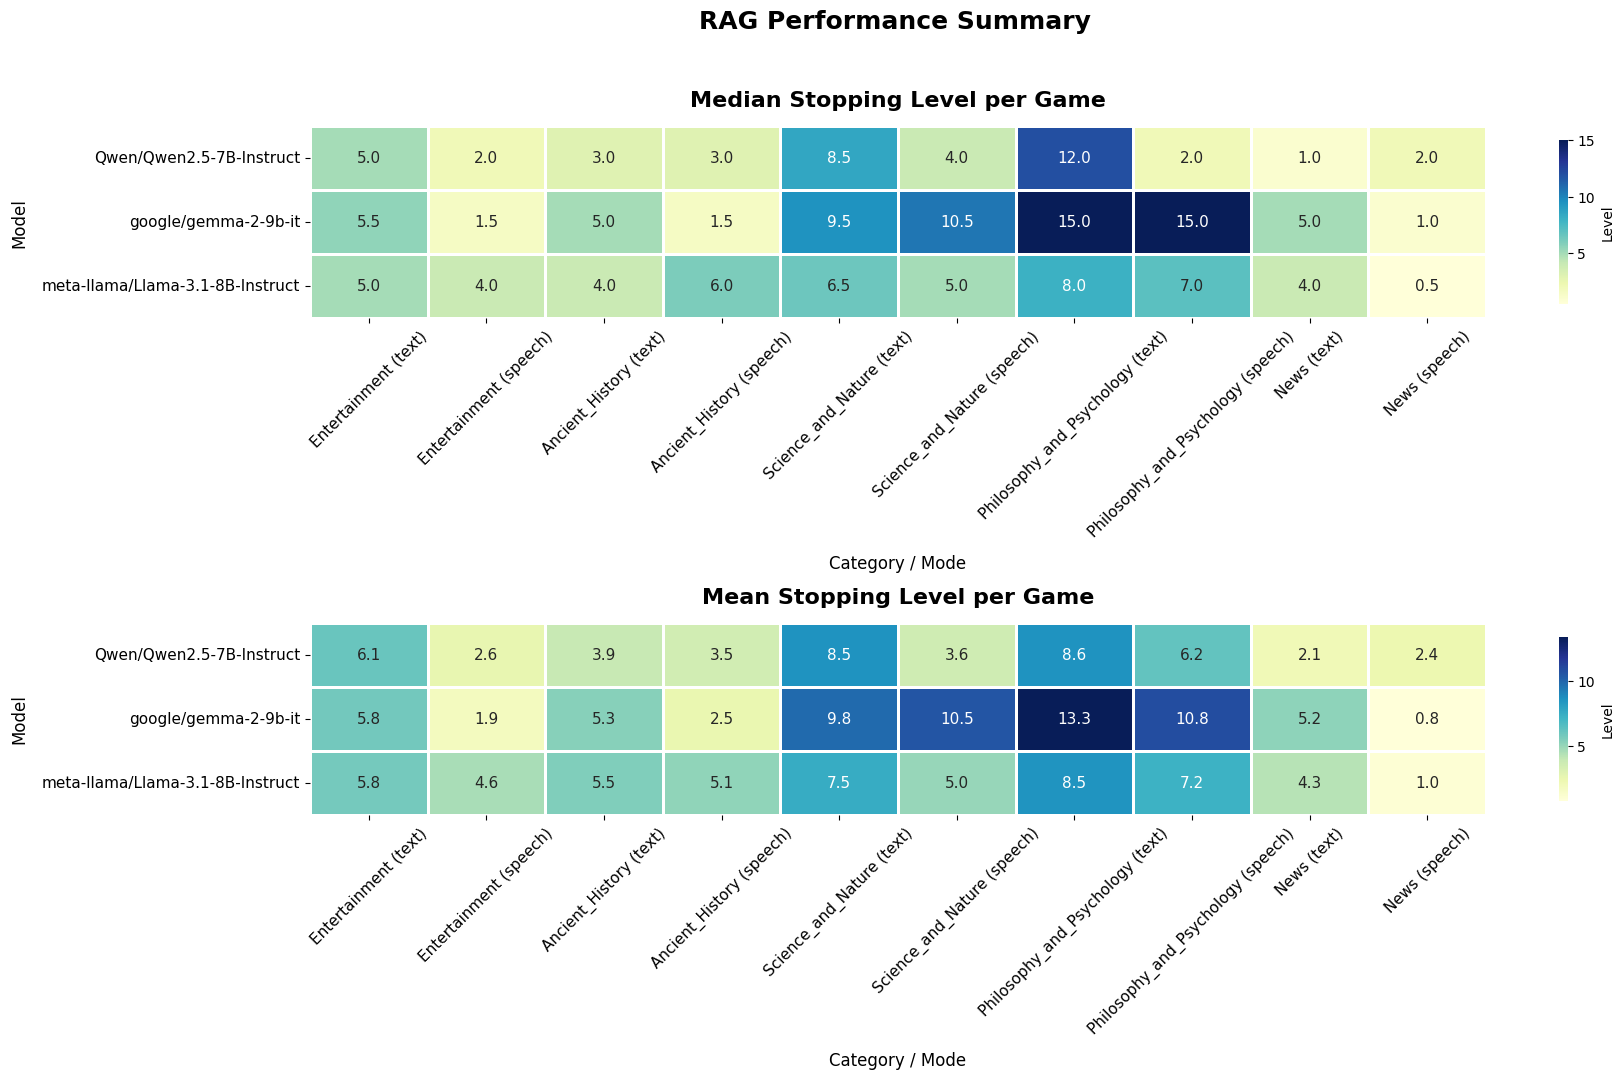

In [ ]:
# ==================================================
# S4 - GAME STATS, MEAN
# ==================================================
RAG_RUN_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    4: "Philosophy_and_Psychology",
    5: "News",
}

rag_df, game_stats_rag, pivot_mean_rag, pivot_median_rag = show_rag_summary(
    df_rag,
    RAG_RUN_CATEGORIES,
    split_by_mode=True,
)

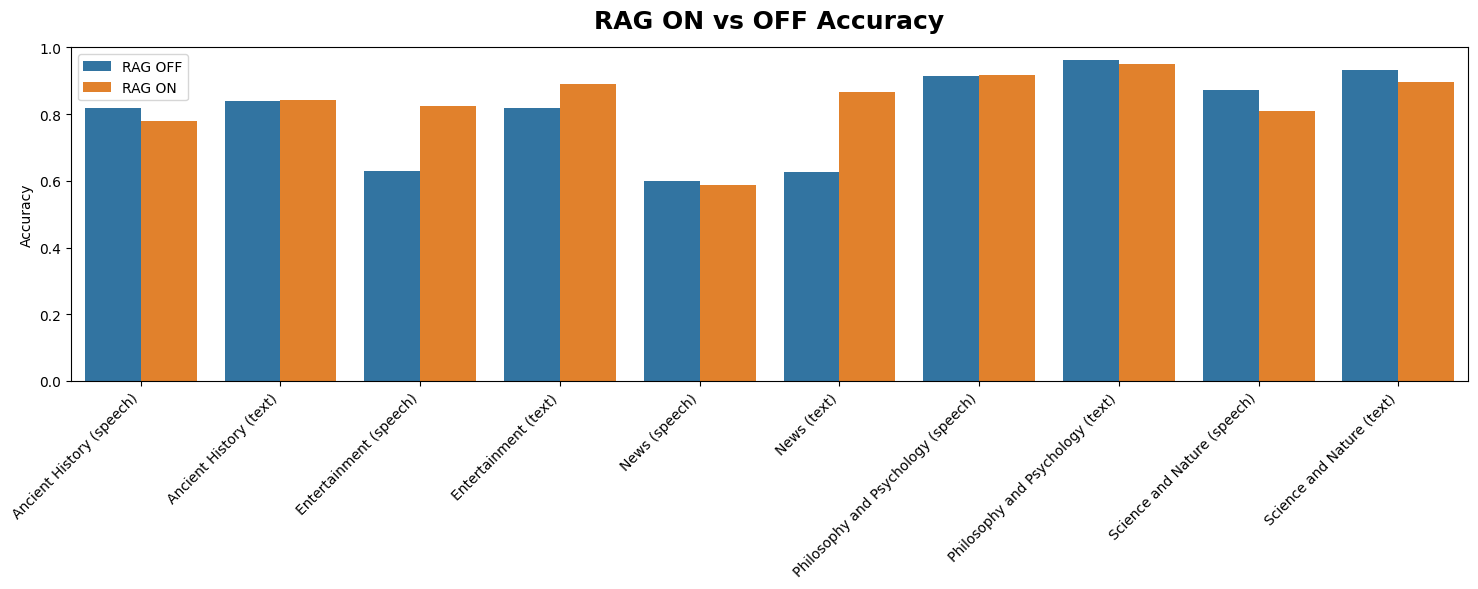

In [ ]:
# ================
# S4 - RAG USAGE
# ================
rag_on_off = plot_rag_on_off_accuracy_only(
    df_rag,
    save_path=HEATMAPS_DIR / "rag_on_off_accuracy.png",
)

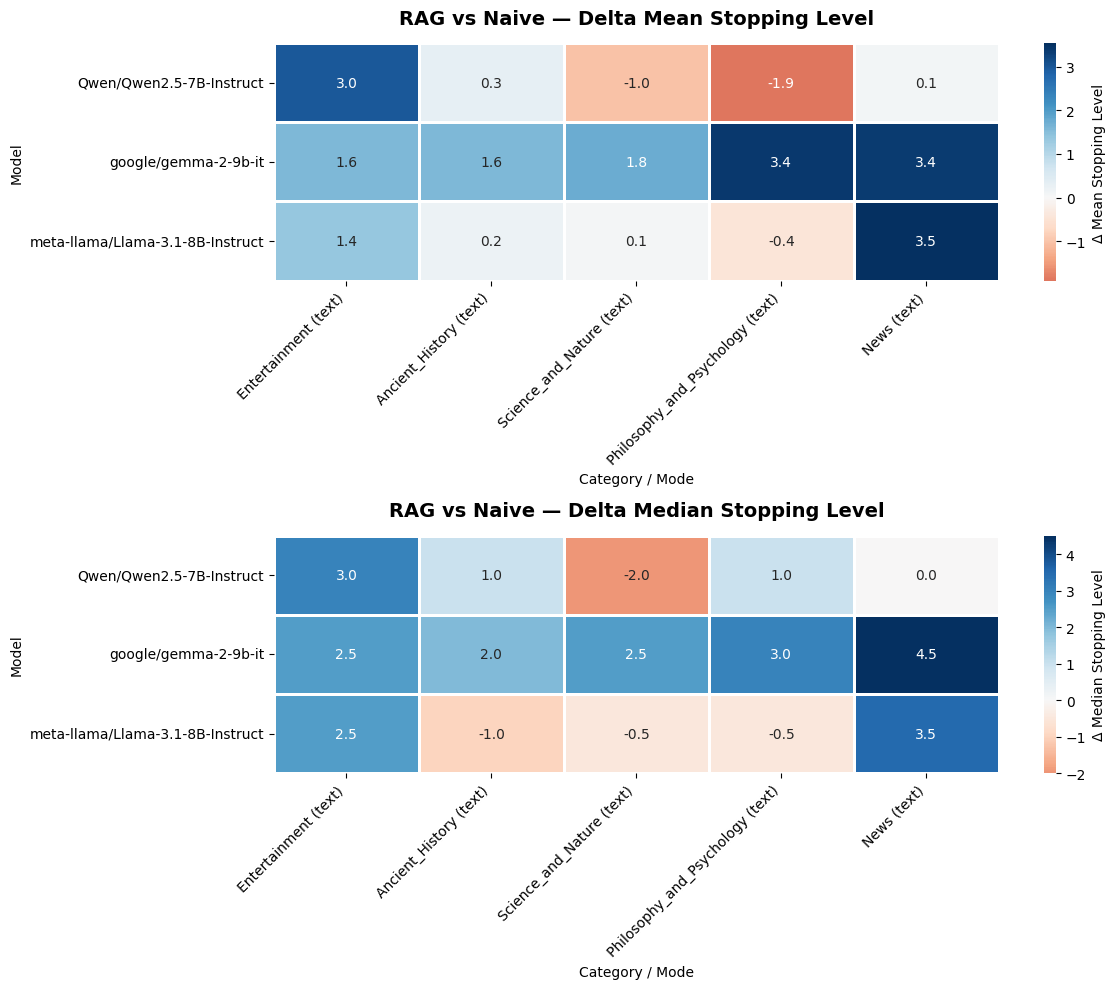

In [ ]:
# ==================================================
# S4 — DELTA VS NAIVE BASELINE (MEAN + MEDIAN)
# ==================================================

common_models = pivot_mean_rag.index.intersection(pivot_mean_naive.index)
common_cols = pivot_mean_rag.columns.intersection(pivot_mean_naive.columns)

delta_mean = (
    pivot_mean_rag.loc[common_models, common_cols]
    - pivot_mean_naive.loc[common_models, common_cols]
)
delta_median = (
    pivot_median_rag.loc[common_models, common_cols]
    - pivot_median_naive.loc[common_models, common_cols]
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, data, metric in zip(axes, [delta_mean, delta_median], ["Mean", "Median"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".1f",
        cmap="RdBu",
        center=0,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": f"Δ {metric} Stopping Level"},
        ax=ax,
    )
    ax.set_title(
        f"RAG vs Naive — Delta {metric} Stopping Level",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Category / Mode")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()

save_path = HEATMAPS_DIR / "delta_rag_vs_naive_mean_median_stopping_level.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## **S4 — Results**

The RAG pipeline improves performance mainly when the retrieved evidence is **relevant, specific, and trusted by the gating mechanism**. This is visible in the **RAG vs Naive delta heatmap**, where positive values indicate that the RAG system reaches a higher mean stopping level than the naive baseline.

The strongest improvements appear in categories where answers depend on **external factual evidence**, such as named entities, dates, events, works, scientific facts, or recent news articles. In particular, the delta heatmap shows that RAG can provide clear gains for several model/category combinations, especially when the retrieved context directly supports the correct option.

However, RAG is **not uniformly beneficial**. Some categories or models show small gains or negative deltas, meaning that retrieval can occasionally introduce noisy or misleading context. This happens especially when the question requires reasoning rather than factual lookup, or when the retrieved passages are related but not decisive.

For this reason, RAG is used **selectively rather than always**. The system activates retrieved context only when the reranker score and option-confidence signals pass category-specific thresholds. Otherwise, it falls back to the naive prompt.

The **RAG ON vs OFF accuracy plot** should be interpreted as a diagnostic view of this gating strategy. It compares questions where RAG was actually used with questions where the system fell back to the non-RAG prompt. Since RAG ON questions are not randomly selected and may often be harder or more information-dependent, this plot is not a direct baseline comparison. The main comparison with the baseline is instead given by the **RAG vs Naive stopping-level delta heatmap**.

---
# **S5 — Math**

## **Objective**

In this section, we focus on the **Math** competition, which is handled separately from the knowledge-intensive categories. Unlike factual questions, Math questions usually require computation, symbolic reasoning, or multi-step problem solving.

For this section, we use **`nvidia/AceMath-7B-Instruct`** as the reference model and compare multiple math-specific answering strategies.

## **Tested Strategies**

| Sub-section | Strategy | Description |
|:---|:---|:---|
| **S5.1** | **Simple Math Prompt** | Use a direct math-oriented prompt and select one of the available answer options. |
| **S5.2** | **Tool Calling** | Let the model call predefined Python tools for numerical and symbolic computations. |
| **S5.3** | **Code Generation** | Ask the model to generate and execute Python code to solve the question. |
| **S5.4** | **Code Generation + Self-Review** | Extend code generation with a verification step that checks and optionally corrects the generated solution. |
| **S5.5** | **Function Registry + Dynamic Code Generation** | Provide the model with a registry of predefined math helper functions while still allowing dynamic code generation. |
| **S5.6** | **Few-Shot CoT + Category-Aware Prompting** | Use category-aware prompting with similar few-shot examples and reasoning traces. |

In [ ]:
#first we free the space from memory (free some VRAM)
unload_model_from_memory()
#the we load the quantized model
tokenizer, model, local_dir, t_load = load_quantized_model(MODEL_ID, quant_config = bnb_config)
LOCAL_DIR = str(local_dir)

In [ ]:
# ==============================================================
# S5 - CORE SETUP
# ==============================================================

MATH_COMP_ID = 3
ANALYSIS_DIR = BASE / "analysis"
MATH_FEWSHOT_PATH = ANALYSIS_DIR / "math_fewshot_candidates.json"

LOGS_DIR_S51 = BASE / "logs_s51"
LOGS_DIR_S52 = BASE / "logs_s52"
LOGS_DIR_S53 = BASE / "logs_s53"
LOGS_DIR_S54 = BASE / "logs_s54"
LOGS_DIR_S55 = BASE / "logs_s55"
LOGS_DIR_S56 = BASE / "logs_s56"

MATH_LOG_DIRS = [
    LOGS_DIR_S51,
    LOGS_DIR_S52,
    LOGS_DIR_S53,
    LOGS_DIR_S54,
    LOGS_DIR_S55,
    LOGS_DIR_S56,
]

for logs_dir in MATH_LOG_DIRS:
    logs_dir.mkdir(parents=True, exist_ok=True)

try:
    with open(MATH_FEWSHOT_PATH, "r", encoding="utf-8") as f:
        MATH_FEWSHOTS = json.load(f)
    print(f"Few-shot examples loaded: {len(MATH_FEWSHOTS)} categories")
except FileNotFoundError:
    MATH_FEWSHOTS = {}
    print("Warning: math_fewshot_candidates.json not found; using 0 few-shot examples.")

print(f"Math competition ID: {MATH_COMP_ID}")
print("Math log dirs:", MATH_LOG_DIRS)


N_RUNS_S5 = 10
SLEEP_BETWEEN_RUNS = 3


def _detect_fallback_answers(df: pd.DataFrame, section_tag: str = "") -> pd.Series:
    """Detect questions solved through the S5.1 fallback."""
    if "raw_output" not in df.columns:
        return pd.Series(False, index=df.index)

    raw = df["raw_output"].fillna("").astype(str)
    fallback = raw.str.contains(r"S5[2-6]_FALLBACK", regex=True, na=False)

    if section_tag.lower() != "s51":
        fallback = fallback | raw.str.contains(r"\[S51_SIMPLE\]", regex=True, na=False)

    return fallback


def _aggregate_run_stack(g: pd.DataFrame) -> pd.Series:
    """Summarize one game run and split levels before/after fallback."""
    g = g.sort_values("level")
    max_level = int(g["level"].max())
    fallback_questions = int(g["_is_fallback"].sum())

    if not g["_is_fallback"].any():
        levels_no_fallback = max_level
        levels_with_fallback = 0
    else:
        levels_no_fallback = 0
        for _, row in g.iterrows():
            if row["_is_fallback"]:
                break
            levels_no_fallback = int(row["level"])
        levels_with_fallback = max_level - levels_no_fallback

    return pd.Series({
        "max_level": max_level,
        "levels_no_fallback": levels_no_fallback,
        "levels_with_fallback": levels_with_fallback,
        "questions_answered": len(g),
        "avg_elapsed": g["elapsed_s"].mean(),
        "used_fallback": fallback_questions > 0,
        "fallback_questions": fallback_questions,
    })


def compute_s5_run_stats(df: pd.DataFrame, section_tag: str = "") -> pd.DataFrame:
    """Compute per-run summary metrics for S5 experiments."""
    if df.empty:
        return pd.DataFrame()

    df = df.copy()
    df["_is_fallback"] = _detect_fallback_answers(df, section_tag)
    return (
        df.groupby("run_idx", group_keys=False)
          .apply(_aggregate_run_stack)
          .reset_index()
    )


def plot_s5_multirun_performance(
    run_stats: pd.DataFrame,
    strategy_label: str,
    section_tag: str,
    save_dir: Path | None = None,
):
    """Plot level reached per run, highlighting S5.1 fallback usage."""
    fig, ax = plt.subplots(figsize=(8, 4.5))

    runs = run_stats["run_idx"].astype(str)
    totals = run_stats["max_level"].astype(float)

    if section_tag.lower() == "s51":
        ax.bar(runs, totals, color="#2980b9", edgecolor="white", linewidth=0.8)
        ax.set_title("Level per run")
    else:
        no_fallback = run_stats["levels_no_fallback"].astype(float)
        with_fallback = run_stats["levels_with_fallback"].astype(float)

        ax.bar(
            runs,
            no_fallback,
            color="#2980b9",
            edgecolor="white",
            linewidth=0.8,
            label="No fallback",
        )
        ax.bar(
            runs,
            with_fallback,
            bottom=no_fallback,
            color="#e74c3c",
            edgecolor="white",
            linewidth=0.8,
            label="With S5.1 fallback",
        )
        ax.set_title("Level per run (stacked: no fallback / fallback)")
        ax.legend(loc="upper right", fontsize=8)

    avg_level = totals.mean()
    ax.axhline(
        avg_level,
        color="#2c3e50",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean level: {avg_level:.1f}",
    )

    for i, total in enumerate(totals):
        ax.text(
            i,
            total + 0.12,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_xlabel("Run")
    ax.set_ylabel("Level reached")

    model_label = get_model_label(MODEL_ID)
    plt.suptitle(
        f"{strategy_label} - {len(run_stats)} runs | Model: {model_label}",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        plot_path = save_dir / f"{section_tag}_multirun_plot_{model_label}.png"
        plt.savefig(plot_path, dpi=120, bbox_inches="tight")
        print(f"Plot saved: {plot_path}")

    plt.show()


def run_s5_multirun(
    ask_llm_fn,
    logs_dir: Path,
    section_tag: str,
    strategy_label: str,
    n_runs: int = N_RUNS_S5,
    sleep_between: float = SLEEP_BETWEEN_RUNS,
    enrich_df=None,
    mode = "text",
):
    """Run multiple Math games with the shared play_automated pipeline."""
    play_params = get_play_params(MODEL_ID)
    logs_dir.mkdir(parents=True, exist_ok=True)

    all_logs = []

    print(f"Starting {n_runs} runs - {strategy_label} | Math competition")
    print("Play params:", play_params)

    for run_idx in range(1, n_runs + 1):
        print(f"\n{'=' * 50} RUN {run_idx}/{n_runs}")

        run_log, _ = play_automated(
            client=client,
            comp_id=MATH_COMP_ID,
            model=model,
            tokenizer=tokenizer,
            ask_llm_fn=ask_llm_fn,
            model_id=MODEL_ID,
            save_logs=True,
            logs_dir=logs_dir,
            mode= mode,
            **play_params,
        )

        for entry in run_log:
            entry["run_idx"] = run_idx

        all_logs.extend(run_log)

        if run_idx < n_runs:
            time.sleep(sleep_between)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    agg_path = logs_dir / (
        f"{section_tag}_multirun_{get_model_label(MODEL_ID)}_{n_runs}runs_{timestamp}.json"
    )

    agg_path.write_text(
        json.dumps(all_logs, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"\nAll {n_runs} runs saved: {agg_path}")

    df = pd.DataFrame(all_logs)
    if enrich_df is not None:
        df = enrich_df(df)

    run_stats = compute_s5_run_stats(df, section_tag=section_tag)

    print(f"\n=== Per-Run Summary - {strategy_label} ===")
    if not run_stats.empty:
        print(run_stats.to_string(index=False))

        if section_tag.lower() != "s51":
            n_fallback_runs = int(run_stats["used_fallback"].sum())
            print(f"\nRuns with S5.1 fallback: {n_fallback_runs}/{len(run_stats)}")

        print(f"Average max level reached: {run_stats['max_level'].mean():.1f}")
        plot_s5_multirun_performance(
            run_stats,
            strategy_label,
            section_tag,
            save_dir=logs_dir,
        )
    else:
        print("No run stats available.")

    return all_logs, run_stats, agg_path, df


print("S5 core setup ready.")

In [ ]:
def add_math_shot(category, question, options, correct_answer, reasoning):
    MATH_FEWSHOTS.setdefault(category, [])
    # avoid duplicate if cell is rerun
    MATH_FEWSHOTS[category] = [
        ex for ex in MATH_FEWSHOTS[category]
        if ex.get("source") != "manual_fewshot_patch" or ex.get("question") != question
    ]
    MATH_FEWSHOTS[category].insert(0, {
        "question": question,
        "options": {str(k): str(v) for k, v in options.items()},
        "correct_answer": int(correct_answer),
        "reasoning": reasoning,
        "source": "manual_fewshot_patch",
    })


add_math_shot(
    "trigonometry_complex",
    "If f(z) is an analytic function that maps the entire finite complex plane into the real axis, then the imaginary axis must be mapped onto",
    {"0": "an open finite interval", "1": "a ray", "2": "a point", "3": "the entire real axis"},
    2,
    "A nonconstant analytic function is open, so it cannot map the complex plane into the real axis. Therefore f is constant, and every subset, including the imaginary axis, maps to a single point."
)

add_math_shot(
    "statistics_sampling_design",
    "A medical research team tests for tumor reduction in a sample of patients using three different dosages of an experimental cancer drug. Which of the following is true?",
    {"0": "There are three explanatory variables and one response variable.", "1": "There are three levels of a single explanatory variable.", "2": "Tumor reduction is the only explanatory variable.", "3": "There is one explanatory variable with three levels of response."},
    1,
    "The explanatory variable is dosage. The three dosages are levels of that one explanatory variable. Tumor reduction is the response variable."
)

add_math_shot(
    "geometry_measurement",
    "The length of a rectangle is twice its width. Given the length of the diagonal is 5sqrt(5), find the area of the rectangle.",
    {"0": "50", "1": "2500", "2": "25", "3": "2"},
    0,
    "Let width be w and length be 2w. The diagonal satisfies w^2+(2w)^2=5w^2=(5sqrt(5))^2=125, so w^2=25. Area=2w^2=50."
)

add_math_shot(
    "probability_basic",
    "When three standard dice are tossed, the numbers a,b,c are obtained. Find the probability that abc = 180.",
    {"0": "1/30", "1": "1/70", "2": "1/72", "3": "1/71"},
    2,
    "Since 180=2^2*3^2*5 and die values are 1..6, the only possible multiset is {5,6,6}. There are 3 ordered rolls out of 6^3=216, so probability=3/216=1/72."
)

add_math_shot(
    "combinatorics_counting",
    "A mathematics department has 10 professors and 20 different courses. Each professor teaches exactly 2 courses and each course has exactly one professor. How many complete assignments are possible?",
    {"0": "10!/2^9", "1": "10^20 - 2^10", "2": "10^20 - 100", "3": "20!/2^10"},
    3,
    "Assign 20 distinct courses into 10 labeled professor-pairs of size 2. This is 20! divided by 2! for each professor, so 20!/(2!)^10 = 20!/2^10."
)

add_math_shot(
    "permutation_group_order",
    "Find the maximum possible order for an element of S_n for n = 7.",
    {"0": "12", "1": "6", "2": "105", "3": "30"},
    0,
    "Element order is the lcm of disjoint cycle lengths whose sum is at most 7. The best partition is 4+3, giving lcm(4,3)=12."
)

add_math_shot(
    "linear_algebra_matrices",
    "Let V and W be 4-dimensional subspaces of a 7-dimensional vector space X. Which CANNOT be the dimension of V intersect W?",
    {"0": "2", "1": "1", "2": "0", "3": "3"},
    2,
    "dim(V+W)=dim(V)+dim(W)-dim(V∩W)=8-dim(V∩W), and dim(V+W)<=7. Thus dim(V∩W)>=1, so 0 cannot occur."
)

add_math_shot(
    "number_theory_modular",
    "What is the sum of all positive integer values of n such that n^2 is a factor of 1200?",
    {"0": "36", "1": "42", "2": "39", "3": "12"},
    1,
    "1200=2^4*3*5^2. For n^2 to divide 1200, n may use 2^0..2 and 5^0..1, but no factor 3. Values: 1,2,4,5,10,20; sum=42."
)

print("Manual few-shot patch added.")

In [ ]:
import re
import time
from typing import Any


METHOD_CATEGORY_HINTS = {
    "permutation_group_order": "Use cycle lengths and maximize the lcm under the sum constraint.",
    "abstract_algebra_structures": "Use group/ring/field/ideal/domain definitions and test the statements/options.",
    "relations_sets_cardinality": "Translate the relation or set definition into its formal condition.",
    "linear_algebra_matrices": "Use determinant, trace, rank, eigenvalue, subspace, or vector rules.",
    "statistics_hypothesis_testing": "Identify null/alternative, Type I/II error, p-value, power, or conclusion.",
    "statistics_confidence_intervals": "Interpret estimate plus/minus margin, confidence level, interval width, or sample size.",
    "statistics_sampling_design": "Identify SRS, stratified, cluster, matched-pairs, experiment, or observational design.",
    "statistics_descriptive_distributions": "Use mean, standard deviation, z-score, quartile, IQR, correlation, or regression rules.",
    "probability_basic": "Model the random experiment and compute or compare the probability.",
    "number_theory_modular": "Use divisibility, prime factorization, gcd/lcm, modular arithmetic, or digit rules.",
    "modular_exponent_remainder": "Reduce powers modulo the divisor using cycles, then combine remainders.",
    "combinatorics_counting": "Count choices, arrangements, permutations, combinations, or cases without overcounting.",
    "arithmetic_fractions_percent": "Perform the fraction, percent, ratio, or arithmetic calculation.",
    "word_rate_cost": "Translate to unit rates, costs, work rates, or proportional relationships.",
    "compound_interest_growth": "Use exponential growth/decay, doubling time, compound interest, or logarithms.",
    "function_domain_restrictions": "Check denominators, square roots, logarithms, and function validity.",
    "polynomial_algebra": "Use polynomial, equation, inequality, root, or expression manipulation rules.",
    "algebra_systems_equations": "Set up and solve the equation or system.",
    "calculus_integrals_differential": "Use derivative, tangent, integral, differential equation, Riemann sum, or optimization rules.",
    "geometry_measurement": "Use geometric formulas, dimensions, angles, area, perimeter, volume, or folding relations.",
    "trigonometry_complex": "Use trigonometric identities, parametric curves, polar/complex arithmetic, or complex division.",
    "calendar_date": "Use day-of-week shifts modulo 7 and month lengths.",
    "misc_math": "Solve with a short calculation and match the result to the option id.",
}


def normalize_options(options: Any) -> dict:
    if isinstance(options, dict):
        return {str(k).strip(): str(v).strip() for k, v in options.items() if k is not None}
    out = {}
    if isinstance(options, list):
        for o in options:
            if isinstance(o, dict):
                oid = o.get("id", o.get("label"))
                txt = o.get("text", o.get("value"))
            else:
                oid = getattr(o, "id", None)
                txt = getattr(o, "text", None)
            if oid is not None:
                out[str(oid).strip()] = "" if txt is None else str(txt).strip()
    return out
def sort_option_ids(ids):
    ids = list(ids)
    return sorted(ids, key=lambda x: int(x)) if all(str(x).isdigit() for x in ids) else sorted(ids)


def _tok(s: str):
    return set(re.findall(r"[a-z0-9]+", (s or "").lower()))


def _jaccard(a: str, b: str) -> float:
    A, B = _tok(a), _tok(b)
    return len(A & B) / max(1, len(A | B)) if (A or B) else 0.0


def parse_math_answer(raw: str, options):
    opts = normalize_options(options)
    valid_ids = set(str(k) for k in opts.keys())
    raw = str(raw or "").strip()

    matches = re.findall(r"FINAL_ANSWER\s*:\s*([^\n]+)", raw, re.IGNORECASE)
    candidate = matches[-1].strip() if matches else raw.strip()
    candidate = candidate.strip().strip(".").split()[0]

    if candidate in valid_ids:
        return int(candidate)

    def norm(x):
        x = str(x).strip().lower()
        x = x.replace("$", "").replace("\\", "")
        x = re.sub(r"\s+", "", x)
        return x

    cand_norm = norm(candidate)
    value_matches = [opt_id for opt_id, opt_text in opts.items() if norm(opt_text) == cand_norm]
    return int(value_matches[0]) if len(value_matches) == 1 else None


def classify_math_question(question_text, options) -> str:
    opts = normalize_options(options)
    text = (str(question_text) + " " + " ".join(opts.values())).lower()
    text = re.sub(r"\s+", " ", text)

    if re.search(r"\bs[_ ]?n\b|s_n|symmetric group|permutation|order for an element|order of an element|cycle", text):
        return "permutation_group_order"
    if re.search(r"type i|type 1|type ii|type 2|null hypothesis|alternative hypothesis|p-?value|z-score|significance|hypothesis test|power of the test", text):
        return "statistics_hypothesis_testing"
    if re.search(r"confidence interval|margin of error|interval estimate|interval width|we are .* confident|sample size", text):
        return "statistics_confidence_intervals"
    if re.search(r"observational study|experimental design|design of experiments|control group|double-blind|survey|sample plan|representative sample|stratified|cluster sample|simple random|matched pairs|random sample|researcher manipulates|treatment group|explanatory variable|response variable|dosage|treatment", text):
        return "statistics_sampling_design"
    if re.search(r"correlation|regression|percentile|quartile|iqr|interquartile|standard deviation|variance|normally distributed|normal distribution|sampling distribution|mean score|mean of|continuous data|discrete data|categorical", text):
        return "statistics_descriptive_distributions"
    if re.search(r"probability|fair coin|coin tossed|random variable|expected value", text):
        return "probability_basic"
    if re.search(r"\\binom|\bbinom\b|c\(\d+,\d+\)|combinations?", text):
        return "combinatorics_counting"
    if re.search(r"matrix|matrices|determinant|det\(|trace|eigen|vector|linear transformation|subspace|\brow\b|\bcolumn\b", text):
        return "linear_algebra_matrices"
    if re.search(r"statement 1|statement 2", text):
        if re.search(r"group|subgroup|ring|field|integral domain|abelian|ideal|quotient|polynomial over a ring", text):
            return "abstract_algebra_structures"
        if re.search(r"sequence|bounded|convergent|limit|complex numbers", text):
            return "calculus_integrals_differential"
        return "relations_sets_cardinality"
    if re.search(r"\bgroup\b|subgroup|ring|field|integral domain|ideal|quotient|cyclic|abelian|non-abelian|homomorphism|isomorphism|field extension|finite group|element of a group|order of g", text):
        return "abstract_algebra_structures"
    if re.search(r"relation|reflexive|symmetric|anti-symmetric|antisymmetric|transitive|equivalence|cardinality|set of all|rational number|functions from", text):
        return "relations_sets_cardinality"
    if re.search(r"modulo|\\pmod| mod |remainder|congruent|divisor|divisible|gcd|lcm|least common multiple|greatest common divisor|prime factor|digits sum|smallest prime|integer", text):
        if re.search(r"\^\{?\d+|\b2\^|\b3\^|power", text) and re.search(r"remainder|modulo|\\pmod| mod ", text):
            return "modular_exponent_remainder"
        return "number_theory_modular"
    if re.search(r"compound|interest rate|same interest rate|compounded|grow to|takes .* to double|doubl(?:e|es|ing) every|doubling time|half-life|radioactive isotope|exponential|logarithm|\\log| log_|e\^", text):
        return "compound_interest_growth"
    if re.search(r"differential equation|derivative|tangent|integral|riemann|trapezoid|midpoint|concave|bounded by|rotated|volume of the solid|maximum value|minimum value|optimization|velocity|reverse direction|acceleration|changes sign", text):
        return "calculus_integrals_differential"
    if re.search(r"domain|range|undefined|sqrt|square root|denominator|inverse of|f\(x\)|g\(x\)|h\(x\)", text):
        return "function_domain_restrictions"
    if re.search(r"triangle|square|circle|rectangle|angle|area|perimeter|volume|radius|polygon|folded|fencing|yard|torus|revolved|surface generated", text):
        return "geometry_measurement"
    if re.search(r"\bsin\b|\bcos\b|\btan\b|trigonometric|complex|parametric|polar|\bi\b", text):
        return "trigonometry_complex"
    if re.search(r"how many ways|arrangements?|permutations?|combinations?|choose|roles|assign", text):
        return "combinatorics_counting"
    if re.search(r"cost|cents|dollars|price|pages|words per minute|labor|restaurant|pencils|pens|work together|unit rate", text):
        return "word_rate_cost"
    if re.search(r"percent|fraction|ratio|reciprocal|multiply|product|nearest whole|waist", text):
        return "arithmetic_fractions_percent"
    if re.search(r"polynomial|quadratic|cubic|root|roots|equation|inequality|simplify|x\^|value of x|satisfying|positive numbers|system", text):
        return "polynomial_algebra"
    if re.search(r"day of the week|february|march|april|january|calendar|month", text):
        return "calendar_date"
    return "misc_math"


def _all_fewshot_examples():
    for category, examples in MATH_FEWSHOTS.items():
        for ex in examples:
            yield category, ex


def select_fewshots(category: str, question_text: str, options, k: int = 2) -> list:
    opts_txt = " ".join(normalize_options(options).values())
    query = f"{question_text} {opts_txt}"

    same_category = []
    cross_category = []
    for ex_category, ex in _all_fewshot_examples():
        ex_text = f"{ex.get('question', '')} {' '.join(ex.get('options', {}).values())}"
        base = _jaccard(query, ex_text)
        has_reasoning = bool(ex.get("reasoning", "").strip())
        score = base + (0.05 if has_reasoning else 0.0)
        if ex_category == category:
            if has_reasoning or base >= 0.12:
                same_category.append((score, ex))
        elif base >= 0.18 or (has_reasoning and base >= 0.12):
            cross_category.append((score, ex))

    same_category.sort(key=lambda x: x[0], reverse=True)
    cross_category.sort(key=lambda x: x[0], reverse=True)

    selected = [ex for _, ex in same_category[:k]]
    if not selected:
        selected.extend(ex for _, ex in cross_category[:k])
    return selected[:k]


def ask_llm_math_answer_only(system, user, options, model, tokenizer, max_new_tokens=8):
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    text = text + "FINAL_ANSWER:"
    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    t0 = time.time()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    elapsed = time.time() - t0

    suffix = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    raw = f"FINAL_ANSWER:{suffix}"
    return parse_math_answer(raw, options), raw, elapsed


def _pick_answer_from_computed(question_text, options, computed, model, tokenizer,
                               max_new_tokens=192):
    opts = normalize_options(options)
    allowed_ids = sort_option_ids(opts.keys())
    opts_str = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)
    allowed = ", ".join(allowed_ids)

    system = (
        "You are a precise multiple-choice answer selector. "
        "Compare the computed result with each option and finish with FINAL_ANSWER: <id>."
    )
    user = (
        f"Question:\n{question_text}\n\n"
        f"Options:\n{opts_str}\n\n"
        f"Computed result: {computed}\n\n"
        f"The answer must be the id of one of these options: {allowed}.\n"
        "Match the final computed value to the current option ids.\n"
        "Use this exact format:\n"
        "WORK: <one line comparing computed to options>\n"
        "FINAL_ANSWER: <id>"
    )

    _, raw2, _ = ask_llm_with_prompt(
        system, user, options, model, tokenizer, max_new_tokens=max_new_tokens,
    )
    ans = parse_math_answer(raw2, options)
    if ans is not None:
        return ans, raw2

    extractor_system = (
        "You extract the final multiple-choice option id from a math solution. "
        "Return only one line: FINAL_ANSWER: <id>."
    )
    extractor_user = (
        f"Question:\n{question_text}\n\n"
        f"Options:\n{opts_str}\n\n"
        f"Computed result: {computed}\n\n"
        f"Previous model output:\n{raw2}\n\n"
        f"The answer must be one of: {allowed}.\n"
        "Return exactly one line: FINAL_ANSWER: <id>"
    )
    ans2, raw_extract, _ = ask_llm_math_answer_only(
        extractor_system, extractor_user, options, model, tokenizer, max_new_tokens=8,
    )
    if ans2 is not None:
        return ans2, raw2 + "\n[EXTRACTED]\n" + raw_extract

    return None, raw2


def append_s5_trace(prefix: str, tag: str, **stages) -> str:
    """Append full model outputs to raw_output saved in Drive logs (S5.1–S5.5)."""
    lines = [str(prefix or "").rstrip(), tag]
    for name, content in stages.items():
        if content is None:
            continue
        lines.append(f"[S5_{name}_BEGIN]")
        text = str(content).strip()
        lines.append(text if text else "<empty>")
        lines.append(f"[S5_{name}_END]")
    return "\n".join(lines)


def build_math_routed_prompt(question_text, options, category, n_shots=2, shot_mode="similar"):
    opts = normalize_options(options) or {"0": "N/A"}
    allowed_ids = sort_option_ids(opts.keys())
    allowed = ", ".join(allowed_ids)
    current_opts = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)

    if n_shots <= 0:
        shots = []
    elif shot_mode == "static":
        shots = MATH_FEWSHOTS.get(category, [])[:n_shots]
    else:
        shots = select_fewshots(category, question_text, options, k=n_shots)

    examples = []
    for ex in shots:
        ex_opts = ex.get("options", {})
        if str(ex.get("correct_answer")) not in ex_opts:
            continue
        ex_opt_ids = sort_option_ids(ex_opts.keys())
        ex_opts_str = "\n".join(f"{k}) {ex_opts[k]}" for k in ex_opt_ids)
        reasoning = ex.get("reasoning", "").strip()
        if reasoning:
            examples.append(
                f"Example\nQuestion:\n{ex['question']}\n\n"
                f"Options:\n{ex_opts_str}\n\n"
                f"WORK: {reasoning}\n"
                f"FINAL_ANSWER: {ex['correct_answer']}"
            )
        else:
            examples.append(
                f"Example\nQuestion:\n{ex['question']}\n\n"
                f"Options:\n{ex_opts_str}\n\n"
                f"FINAL_ANSWER: {ex['correct_answer']}"
            )

    system = (
        "You are a precise math multiple-choice solver. "
        "Use the examples as method templates. "
        "Solve with a brief calculation, compare the result with the options, "
        "and finish with FINAL_ANSWER: <id>."
    )
    user = (
        f"Math category: {category}\n"
        f"Category method: {METHOD_CATEGORY_HINTS.get(category, METHOD_CATEGORY_HINTS['misc_math'])}\n\n"
        + ("\n\n".join(examples) + "\n\n" if examples else "")
        + f"Now solve this question.\nQuestion:\n{question_text}\n\n"
        f"Options:\n{current_opts}\n\n"
        f"The answer must be the id of one of these options: {allowed}.\n"
        "Use this exact format:\n"
        "WORK: <brief calculation, at most 4 lines>\n"
        "FINAL_ANSWER: <id>"
    )
    return system, user, len(examples)


def ask_llm_math_routed(question_text, options, model, tokenizer, max_new_tokens=None, shot_mode="similar", n_shots=2):
    category = classify_math_question(question_text, options)
    system, user, shots_used = build_math_routed_prompt(
        question_text, options, category, n_shots=n_shots, shot_mode=shot_mode
    )

    tokens = max_new_tokens or 192
    _, raw, elapsed = ask_llm_with_prompt(
        system, user, options, model, tokenizer, max_new_tokens=tokens
    )
    ans = parse_math_answer(raw, options)

    if ans is None:
        opts = normalize_options(options)
        allowed_ids = sort_option_ids(opts.keys())
        opts_str = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)
        extractor_system = (
            "You extract the final multiple-choice option id from a math solution. "
            "Return only one line: FINAL_ANSWER: <id>."
        )
        extractor_user = (
            f"Question:\n{question_text}\n\n"
            f"Options:\n{opts_str}\n\n"
            f"Previous model output:\n{raw}\n\n"
            f"The answer must be one of: {', '.join(allowed_ids)}.\n"
            "Return exactly one line: FINAL_ANSWER: <id>"
        )
        ans2, raw2, elapsed2 = ask_llm_math_answer_only(
            extractor_system, extractor_user, options, model, tokenizer, max_new_tokens=8
        )
        if ans2 is not None:
            return (
                ans2,
                raw + "\n[EXTRACTED]\n" + raw2 + f"\n[MATH_CATEGORY={category}][SHOTS_USED={shots_used}]",
                elapsed + elapsed2,
            )

    return ans, raw + f"\n[MATH_CATEGORY={category}][SHOTS_USED={shots_used}]", elapsed


---
## **S5.1 — Simple Math Prompt (Baseline)**

### **Objective**

Establish a **minimal Math baseline**.

### **Approach**

1. Build a short system + user prompt
2. Call the LLM once and parse `FINAL_ANSWER`.



In [ ]:
# ==============================================================
# S5.1 — SIMPLE MATH PROMPT (baseline + global fallback)
# ==============================================================

def _build_prompt_math_simple(question_text, options) -> tuple:
    """Plain multiple-choice prompt: question + options → FINAL_ANSWER."""
    opts = normalize_options(options)
    if not opts:
        opts = {"0": "N/A"}
    allowed_ids = sort_option_ids(opts.keys())
    opts_str = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)
    allowed = ", ".join(allowed_ids)

    system = "You are a helpful assistant answering multiple-choice math questions."
    user = (
        f"Question:\n{question_text}\n\n"
        f"Options:\n{opts_str}\n\n"
        f"Answer with exactly one line: FINAL_ANSWER: <id>\n"
        f"The answer must be one of: {allowed}.\n"
        f"Do not explain."
    )
    return system, user


def ask_llm_math_simple(question_text, options, model, tokenizer, max_new_tokens=None):
    system, user = _build_prompt_math_simple(question_text, options)

    # First pass: allow reasoning
    tokens = max_new_tokens or 192
    _, raw, elapsed = ask_llm_with_prompt(
        system,
        user,
        options,
        model,
        tokenizer,
        max_new_tokens=tokens,
    )

    ans = parse_math_answer(raw, options)

    # Second pass: only if the first pass did not produce a parseable answer
    if ans is None:
        extractor_system = (
            "You extract the final multiple-choice option id from a math solution. "
            "Return only one line: FINAL_ANSWER: <id>."
        )

        opts = normalize_options(options)
        allowed_ids = sort_option_ids(opts.keys())
        opts_str = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)

        extractor_user = (
            f"Question:\n{question_text}\n\n"
            f"Options:\n{opts_str}\n\n"
            f"Previous model output:\n{raw}\n\n"
            f"The answer must be one of: {', '.join(allowed_ids)}.\n"
            f"Return exactly one line: FINAL_ANSWER: <id>"
        )

        ans2, raw2, elapsed2 = ask_llm_math_answer_only(
            extractor_system,
            extractor_user,
            options,
            model,
            tokenizer,
            max_new_tokens=8,
        )

        if ans2 is not None:
            out = append_s5_trace(
                "",
                "[S51_SIMPLE][S51_EXTRACTOR]",
                model_pass1=raw,
                model_extractor=raw2,
            )
            return ans2, out, elapsed + elapsed2

    return ans, append_s5_trace("", "[S51_SIMPLE]", model_pass1=raw), elapsed


def ask_llm_math_simple_wrapper(question_text, options, model, tokenizer,
                                comp_id=None, max_new_tokens=None,
                                time_left_s=None, level=None, **kwargs):
    return ask_llm_math_simple(
        question_text, options, model, tokenizer,
        max_new_tokens=max_new_tokens or kwargs.get("max_new_tokens"),
    )


def ask_llm_math_fallback(question_text, options, model, tokenizer, **kwargs):
    """Shared fallback for S5.2+ — always uses S5.1 simple prompt."""
    return ask_llm_math_simple(
        question_text, options, model, tokenizer,
        max_new_tokens=kwargs.get("max_new_tokens"),
    )


print("S5.1 — ask_llm_math_simple, ask_llm_math_fallback defined.")

# ==============================================================
# S5.1 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

all_logs_s51, run_stats_s51, agg_path_s51, df_s51 = run_s5_multirun(
    ask_llm_math_simple_wrapper,
    LOGS_DIR_S51,
    section_tag="s51",
    strategy_label="S5.1 Simple Math Prompt",
)


S5.1 — ask_llm_math_simple, ask_llm_math_fallback defined.


---
## **S5.2 — Tool Calling**

### **Objective**

Test whether giving the model access to **external computation tools** improves Math performance

Instead of relying only on internal reasoning, the model can call predefined Python functions

### **Approach**

The pipeline has two stages:

1. **Tool selection:** the model receives the question and the tool descriptions, then returns a JSON object with the tool name and arguments.
2. **Option picking:** the selected tool is executed, and the computed result is passed back to the model to choose the closest option.

```text
Pipeline : Question → Tool JSON → invoke_tool() → computed value → FINAL_ANSWER: <id>
```

### **Available Tools**

`calculate`, `compute_combinations`, `compute_permutations`, `compute_gcd`, `compute_modulo`, `solve_quadratic`, `compute_probability`

### **Fallback Rule**

If the JSON is invalid or the tool execution fails or there is no tool that can perform the computation, the system falls back to **S5.1** (baseline).


In [ ]:
# ==============================================================
# S5.2 — TOOL DEFINITIONS  (LangChain @tool pattern)
# ==============================================================

import math as _math_s52
import json as _json_s52
from langchain_core.tools import tool, render_text_description


@tool
def calculate(expression: str) -> str:
    """Evaluates a Python math expression and returns the result as a string.
    The math module is available. Use: math.sqrt, math.factorial, math.comb,
    math.perm, math.log, math.log2, math.log10, math.sin, math.cos, math.tan,
    math.pi, math.e, **, //, %, abs, round.
    Examples: 'math.comb(10, 3)', 'math.sqrt(144)', '17 % 5', '2**10'."""
    try:
        return str(eval(expression, {"math": _math_s52, "__builtins__": {}}))
    except Exception as e:
        return f"Error: {e}"


@tool
def compute_combinations(n: int, k: int) -> str:
    """Computes C(n, k) = n! / (k! * (n-k)!). Use for choosing k items from n (order does NOT matter)."""
    try:
        return str(_math_s52.comb(int(n), int(k)))
    except Exception as e:
        return f"Error: {e}"


@tool
def compute_permutations(n: int, k: int) -> str:
    """Computes P(n, k) = n! / (n-k)!. Use when selecting k items from n where order matters."""
    try:
        return str(_math_s52.perm(int(n), int(k)))
    except Exception as e:
        return f"Error: {e}"


@tool
def compute_gcd(a: int, b: int) -> str:
    """Computes the Greatest Common Divisor (GCD) of two integers."""
    try:
        return str(_math_s52.gcd(int(a), int(b)))
    except Exception as e:
        return f"Error: {e}"


@tool
def compute_modulo(a: int, n: int) -> str:
    """Computes a mod n (remainder when a is divided by n). Use for modular arithmetic."""
    try:
        return str(int(a) % int(n))
    except Exception as e:
        return f"Error: {e}"


@tool
def solve_quadratic(a: float, b: float, c: float) -> str:
    """Solves a*x^2 + b*x + c = 0. Returns real solutions or 'No real solutions'."""
    try:
        disc = b ** 2 - 4 * a * c
        if disc < 0:
            return "No real solutions"
        elif disc == 0:
            return str(round(-b / (2 * a), 6))
        x1 = (-b + _math_s52.sqrt(disc)) / (2 * a)
        x2 = (-b - _math_s52.sqrt(disc)) / (2 * a)
        return f"{round(x1, 6)}, {round(x2, 6)}"
    except Exception as e:
        return f"Error: {e}"


@tool
def compute_probability(favorable: int, total: int) -> str:
    """Computes basic probability = favorable / total outcomes. Returns a decimal in [0, 1]."""
    try:
        return str(round(int(favorable) / int(total), 6))
    except Exception as e:
        return f"Error: {e}"


MATH_TOOLS = [calculate, compute_combinations, compute_permutations,
              compute_gcd, compute_modulo, solve_quadratic, compute_probability]
rendered_math_tools = render_text_description(MATH_TOOLS)

print(f"Tools loaded: {[t.name for t in MATH_TOOLS]}")

In [ ]:
# ==============================================================
# S5.2 — TOOL CALLING PIPELINE
# invoke_tool + prompt builders + ask_llm_math_with_tool
# ==============================================================

def _get_options_str(options) -> tuple:
    """Returns (multiline_opts_str, allowed_ids_str)."""
    opts_dict = normalize_options(options)
    ids       = sort_option_ids(opts_dict.keys())
    opts_str  = "\n".join(f"{k}) {opts_dict[k]}" for k in ids)
    allowed   = ", ".join(str(k) for k in ids)
    return opts_str, allowed


def _extract_json_from_text(text: str):
    """Extract a tool-call JSON object (supports nested arguments)."""
    text = str(text or "").strip()
    if not text:
        return None

    candidates = []
    for m in re.finditer(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL | re.IGNORECASE):
        try:
            obj = json.loads(m.group(1))
            if isinstance(obj, dict):
                candidates.append(obj)
        except json.JSONDecodeError:
            continue

    i = 0
    while i < len(text):
        if text[i] != "{":
            i += 1
            continue
        depth = 0
        for j in range(i, len(text)):
            if text[j] == "{":
                depth += 1
            elif text[j] == "}":
                depth -= 1
                if depth == 0:
                    try:
                        obj = json.loads(text[i : j + 1])
                        if isinstance(obj, dict):
                            candidates.append(obj)
                    except json.JSONDecodeError:
                        pass
                    i = j + 1
                    break
        else:
            i += 1

    for obj in candidates:
        if obj.get("name"):
            return obj
    return candidates[0] if candidates else None


def _normalize_tool_call(tool_call: dict) -> dict:
    """Fix common model mistakes (empty name, math.* aliases)."""
    if not tool_call:
        return tool_call
    name = str(tool_call.get("name", "")).strip()
    args = tool_call.get("arguments") or {}
    if not isinstance(args, dict):
        args = {}

    alias = {
        "math.sqrt": "calculate",
        "math.comb": "compute_combinations",
        "math.perm": "compute_permutations",
        "gcd": "compute_gcd",
        "mod": "compute_modulo",
    }
    low = name.lower()
    if low in alias:
        name = alias[low]
    elif low.startswith("math.") and "expression" not in args:
        args = {"expression": name}
        name = "calculate"

    return {"name": name, "arguments": args}


def invoke_tool(tool_call: dict):
    """Invoke the tool specified in the model's JSON output."""
    tool_map = {t.name: t for t in MATH_TOOLS}
    name = tool_call.get("name", "")
    if name not in tool_map:
        raise ValueError(f"Tool '{name}' not found. Available: {list(tool_map.keys())}")
    return tool_map[name].invoke(tool_call.get("arguments", {}))


def _build_prompt_tool_select(question_text: str, options) -> tuple:
    """Stage 1: ask the model which tool to call and with what arguments."""
    opts_str, _ = _get_options_str(options)
    system = (
      f"You are a math solver with access to the following tools:\n\n"
      f"{rendered_math_tools}\n\n"
      "Valid tool names are exactly: calculate, compute_combinations, "
      "compute_permutations, compute_gcd, compute_modulo, solve_quadratic, "
      "compute_probability. "
      "Do not use names like math.sqrt, math.comb, or python. "
      "If you need math.sqrt or math.log, use calculate with expression='math.sqrt(...)' or expression='math.log(...)'. "
      "If no tool is clearly useful, return {\"name\": \"none\", \"arguments\": {}}. "
      "Given the math question, return the name and input of the tool to use. "
      "Return your response as a JSON object with 'name' and 'arguments' keys. "
      "Do NOT write FINAL_ANSWER, reasoning, or LaTeX — ONLY one JSON object. "
      "Example: {\"name\": \"calculate\", \"arguments\": {\"expression\": \"math.comb(10, 3)\"}}"
    )
    user = (
        f"Question: {question_text}\n\n"
        f"Options (for reference only):\n{opts_str}\n\n"
        f'Return exactly: {{"name": "...", "arguments": {{...}}}}'
    )
    return system, user


def _build_prompt_pick_option(question_text: str, options, computed_value: str) -> tuple:
    """Stage 2: given the computed value, ask the model to select the matching option."""
    opts_str, allowed = _get_options_str(options)
    system = "You are a precise multiple-choice answer selector."
    user = (
        f"The following result was computed for this math problem:\n\n"
        f"Question: {question_text}\n\n"
        f"Options:\n{opts_str}\n\n"
        f"Computed result: {computed_value}\n\n"
        f"Compare the computed result with each option and select the closest match.\n"
        f"Allowed ids: {allowed}\n"
        f"Respond with exactly one line: FINAL_ANSWER: <id>"
    )
    return system, user


def _s52_build_trace(raw1, extracted, tool_call, tag: str, **extra_stages) -> str:
    stages = {"stage1_tool_select": raw1}
    if extracted is not None:
        stages["tool_json_extracted"] = json.dumps(extracted, ensure_ascii=False)
    if tool_call is not None:
        stages["tool_call_normalized"] = json.dumps(tool_call, ensure_ascii=False)
    stages.update(extra_stages)
    return append_s5_trace("", tag, **stages)


def ask_llm_math_with_tool(question_text, options, model, tokenizer,
                           max_new_tokens_tool=512, max_new_tokens_pick=192):
    """
    S5.2 tool pipeline:
    Stage 1: LLM selects a tool via JSON.
    Stage 2: tool is called.
    Stage 3: computed result is matched to option id.
    Fallback: S5.1 simple prompt.
    """
    t_start = time.time()

    sys1, usr1 = _build_prompt_tool_select(question_text, options)
    _, raw1, _ = ask_llm_with_prompt(
        sys1, usr1, options, model, tokenizer,
        max_new_tokens=max_new_tokens_tool,
    )

    extracted = _extract_json_from_text(raw1)
    tool_call = _normalize_tool_call(extracted)
    preview = (raw1 or "").replace("\n", " ")[:120]
    print(f"  [S5.2] stage1 raw (preview): {preview!r}")
    if tool_call:
        print(f"  [S5.2] parsed tool_call: {json.dumps(tool_call, ensure_ascii=False)}")

    if not tool_call or not tool_call.get("name") or tool_call.get("name") == "none":
        print(f"  [S5.2] JSON/tool name missing — fallback to S5.1")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = _s52_build_trace(raw1, extracted, tool_call, "[S52_FALLBACK_JSON]", model_fallback=raw_fb)
        return ans, trace, time.time() - t_start

    try:
        computed = str(invoke_tool(tool_call))
    except Exception as e:
        print(f"  [S5.2] Tool error: {e} — fallback to S5.1")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = _s52_build_trace(
            raw1, extracted, tool_call, "[S52_FALLBACK_TOOL_ERROR]",
            tool_error=str(e), model_fallback=raw_fb,
        )
        return ans, trace, time.time() - t_start

    if computed.startswith("Error:"):
        print(f"  [S5.2] Tool returned error: {computed} — fallback to S5.1")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = _s52_build_trace(
            raw1, extracted, tool_call, "[S52_FALLBACK_TOOL_RESULT]",
            tool_result=computed, model_fallback=raw_fb,
        )
        return ans, trace, time.time() - t_start

    print(f"  [S5.2] Tool: {tool_call.get('name')} → {computed[:80]}")

    ans, raw2 = _pick_answer_from_computed(
        question_text, options, computed, model, tokenizer, max_new_tokens_pick,
    )

    if ans is None:
        print("  [S5.2] Pick option failed — fallback to S5.1")
        ans_fb, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = _s52_build_trace(
            raw1, extracted, tool_call, "[S52_FALLBACK_PICK]",
            tool_result=computed, stage2_pick=raw2, model_fallback=raw_fb,
        )
        return ans_fb, trace, time.time() - t_start

    trace = _s52_build_trace(
        raw1, extracted, tool_call,
        f"[S52_OK][S52_TOOL={tool_call.get('name')}]",
        tool_result=computed, stage2_pick=raw2,
    )
    return ans, trace, time.time() - t_start


def ask_llm_math_tool_wrapper(question_text, options, model, tokenizer,
                              comp_id=None, max_new_tokens=None,
                              time_left_s=None, level=None, **kwargs):
    return ask_llm_math_with_tool(question_text, options, model, tokenizer)


print("S5.2 — ask_llm_math_with_tool and ask_llm_math_tool_wrapper defined.")

Starting 10 runs - S5.2 Tool Calling | Math competition
Play params: {'max_new_tokens': 256, 'max_think_s': 22.0, 'reserve_submit_s': 3.0}

================================================== RUN 1/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268639

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Some group (G, 0) is known to be abelian. Then which one of the following is TRUE for G?
  [0] (g o h)^2 = g^2 o h^2 for every g,h in G
  [1] G is of finite order
  [2] g = g^-1 for every g in G
  [3] g = g^2 for every g in G


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [S5.2] stage1 raw (preview): '{"name": "calculate", "arguments": {"expression": "(g o h)^2 = g^2 o h^2 for every g,h in G"}}'
  [S5.2] parsed tool_call: {"name": "calculate", "arguments": {"expression": "(g o h)^2 = g^2 o h^2 for every g,h in G"}}
  [S5.2] Tool returned error: Error: invalid syntax. Perhaps you forgot a comma? (<string>, line 1) — fallback to S5.1
  → Answer: 0 (LLM: 3.82s | total: 3.82s)
  → Raw: '
[S52_FALLBACK_TOOL_RESULT]
[S5_stage1_tool_select_BEGIN]
{"name": "calculate", "arguments": {"expression": "(g o h)^2 =...'
  ✅ CORRECT! Earned: $100.00

--- Level 2 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Suppose that the weights of trucks traveling on the interstate highway system are normally distributed. If 70% of the trucks weigh more than 12,000 pounds and 80% weigh more than 10,000 pounds, what are the mean and standard deviation for the weights of trucks traveling on the interstate system?
  [0] μ = 15,100; σ = 6200
  [1] μ = 15,300; σ = 6300
  [2] μ

/tmp/ipykernel_3538/1752690160.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_run_stack)


Plot saved: /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s52/s52_multirun_plot_AceMath-7B-Instruct.png


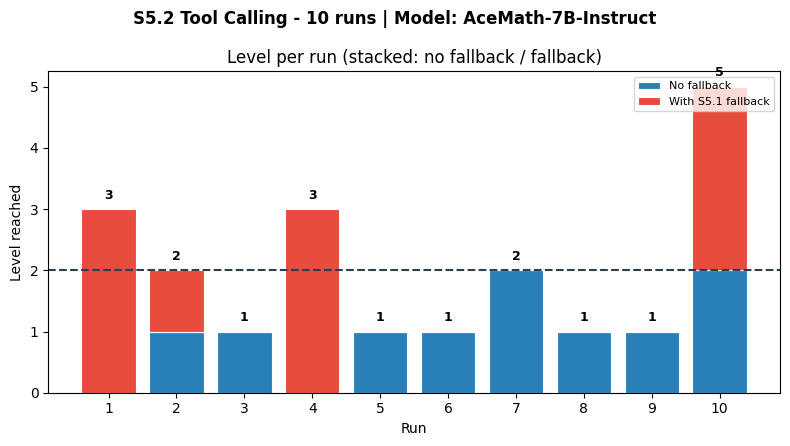

In [ ]:
# ==============================================================
# S5.2 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

all_logs_s52, run_stats_s52, agg_path_s52, df_s52 = run_s5_multirun(
    ask_llm_math_tool_wrapper,
    LOGS_DIR_S52,
    section_tag="s52",
    strategy_label="S5.2 Tool Calling",
)


### **S5.2 — Final Summary (main failures)**

1. **No valid tool call from the LLM (~40% of questions)** — broken or incomplete JSON, `none`, or a call the pipeline cannot use → **fallback to S5.1** (no tools).

2. **Tool output OK, wrong final option (~30% of paths that completed a tool run)** — a number is returned, but the follow-up step still selects the wrong answer.


---
## **S5.3 — Agentic Math: Free-Form Code Generation + Execution**

### **Objective**

Increase flexibility beyond predefined tools by letting the model **write arbitrary Python code** to solve the question.

### **Approach**

The pipeline has two stages:

1. **Code generation:** the model writes a short Python script to compute the answer.
2. **Execution + option picking:** the code is executed, and the resulting value is used to select the final option.

```text
Question → python code generation → _safe_exec() → computed value → FINAL_ANSWER: <id>
```

### **Fallback Rule**

If code extraction or execution fails, the system falls back to **S5.1**. (baseline)


In [ ]:
# ==============================================================
# S5.3 — CODE GENERATION + EXECUTION PIPELINE
# ==============================================================

import io as _io, contextlib as _ctx, traceback as _tb
import math as _m, cmath as _cm, fractions as _fr
import itertools as _it, statistics as _st, functools as _fc, operator as _op


def _extract_code_from_text(text: str) -> str:
    """Extract Python code from model output (prefers last ``` block)."""
    text = str(text or "").strip()
    blocks = re.findall(r"```(?:python)?\s*(.*?)```", text, re.DOTALL | re.IGNORECASE)
    if blocks:
        return blocks[-1].strip()
    blocks = re.findall(r"```\s*(.*?)```", text, re.DOTALL)
    if blocks:
        return blocks[-1].strip()
    return text.strip()


def _sandbox_builtins() -> dict:
    """Shared restricted builtins for S5.3–S5.5 code execution."""
    return {
        "abs": abs, "round": round, "int": int, "float": float,
        "str": str, "bool": bool, "len": len, "range": range,
        "list": list, "tuple": tuple, "dict": dict, "set": set,
        "sum": sum, "min": min, "max": max, "sorted": sorted,
        "enumerate": enumerate, "zip": zip, "map": map, "filter": filter,
        "all": all, "any": any, "reversed": reversed, "divmod": divmod,
        "print": print, "pow": pow, "True": True, "False": False, "None": None,
        "isinstance": isinstance, "type": type, "__import__": __import__,
    }


def _safe_exec(code: str) -> tuple:
    """
    Execute Python code in an isolated namespace (only math modules allowed).
    Returns (ok: bool, output: str).
    Captures print() output; falls back to looking for 'result' variable.
    """
    buf = _io.StringIO()
    local_ns = {}
    safe_globals = {
        "__builtins__": _sandbox_builtins(),
        "math": _m, "cmath": _cm, "fractions": _fr, "Fraction": _fr.Fraction,
        "itertools": _it, "statistics": _st, "functools": _fc, "operator": _op,
    }
    try:
        compiled = compile(code, "<s53_generated>", "exec")
        with _ctx.redirect_stdout(buf):
            exec(compiled, safe_globals, local_ns)
        out = buf.getvalue().strip()
        if not out:
            for key in ("result", "answer", "ans", "output", "value"):
                if key in local_ns:
                    out = str(local_ns[key])
                    break
        return True, out
    except Exception as e:
        return False, f"EXEC_ERROR: {e}\n{_tb.format_exc(limit=2)}"


def _build_prompt_code_gen(question_text: str, options) -> tuple:
    """Stage 1: ask the model to write Python code that computes the answer."""
    opts_str, _ = _get_options_str(options)
    system = (
        "You are a math computation expert. "
        "Given a math problem, write a short Python script that computes the answer. "
        "Available modules: math, cmath, fractions.Fraction, itertools, statistics. "
        "Do NOT import numpy, sympy, or any external library. "
        "Do NOT write FINAL_ANSWER or pick an option id — only Python code. "
        "Store the final answer in 'result' and end with print(result)."
    )
    user = (
        f"Solve this math problem by writing Python code.\n\n"
        f"Question:\n{question_text}\n\n"
        f"Options (for reference — do NOT pick one yet):\n{opts_str}\n\n"
        "Rules:\n"
        "- Use `import math` if needed (math is already available).\n"
        "- The last line must be: print(result)\n"
        "- Output ONLY the Python code block.\n\n"
        "```python\nimport math\n# solve here\nresult = ...\nprint(result)\n```"
    )
    return system, user


def ask_llm_math_code_exec(question_text, options, model, tokenizer,
                           max_new_tokens_code=512, max_new_tokens_pick=192):
    """
    S5.3 two-stage pipeline:
    Stage 1 — LLM generates Python code.
    Stage 2 — Code executed; result passed to LLM for option picking.
    Fallback: exec error → S5.1 simple prompt.
    """
    t_start  = time.time()
    sys1, usr1 = _build_prompt_code_gen(question_text, options)
    _, raw1, _ = ask_llm_with_prompt(sys1, usr1, options, model, tokenizer,
                                      max_new_tokens=max_new_tokens_code)
    code = _extract_code_from_text(raw1)
    ok, computed = _safe_exec(code)
    print(f"  [S5.3] exec_ok={ok} | computed={computed[:60]!r}")

    if not ok or not computed.strip() or str(computed).startswith("EXEC_ERROR"):
        preview = (code or "")[:80].replace("\n", " ")
        print(f"  [S5.3] exec failed — fallback | code: {preview!r}")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = append_s5_trace(
            "", "[S53_FALLBACK_EXEC]",
            stage1_code_gen=raw1, code_extracted=code, exec_output=computed, model_fallback=raw_fb,
        )
        return ans, trace, time.time() - t_start

    ans, raw2 = _pick_answer_from_computed(
        question_text, options, computed, model, tokenizer, max_new_tokens_pick,
    )

    if ans is None:
        ans_fb, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = append_s5_trace(
            "", "[S53_FALLBACK_PICK]",
            stage1_code_gen=raw1, code_extracted=code, exec_output=computed,
            stage2_pick=raw2, model_fallback=raw_fb,
        )
        return ans_fb, trace, time.time() - t_start

    trace = append_s5_trace(
        "", "[S53_CODE_OK]",
        stage1_code_gen=raw1, code_extracted=code, exec_output=computed, stage2_pick=raw2,
    )
    return ans, trace, time.time() - t_start


def ask_llm_math_code_wrapper(question_text, options, model, tokenizer,
                              comp_id=None, max_new_tokens=None,
                              time_left_s=None, level=None, **kwargs):
    return ask_llm_math_code_exec(question_text, options, model, tokenizer)


# ── Quick sanity check ──────────────────────────────────────────
ok, val = _safe_exec("import math\nresult = math.comb(10, 3)\nprint(result)")
print(f"_safe_exec sanity check: ok={ok}, val={val!r}  (expected '120')")
print("S5.3 — ask_llm_math_code_exec defined.")

_safe_exec sanity check: ok=True, val='120'  (expected '120')
S5.3 — ask_llm_math_code_exec defined.


Starting 10 runs - S5.3 Code Generation | Math competition
Play params: {'max_new_tokens': 256, 'max_think_s': 22.0, 'reserve_submit_s': 3.0}

================================================== RUN 1/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268690

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Statement 1 | If H is a subgroup of G and a belongs to G then |aH| = |Ha|. Statement 2 | If H is a subgroup of G and a and b belong to G, then aH and Hb are identical or disjoint.
  [0] True, True
  [1] False, True
  [2] True, False
  [3] False, False


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [S5.3] exec_ok=True | computed='(True, True)'
  → Answer: 0 (LLM: 11.59s | total: 11.59s)
  → Raw: '
[S53_CODE_OK]
[S5_stage1_code_gen_BEGIN]
```python
import math

# Statement 1: If H is a subgroup of G and a belongs to...'
  ❌ WRONG! Game over. Earned: $0.00

GAME OVER — Level reached: 1
Total earned: $0.00
Log saved: 1 entries → /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s53/game_log_AceMath-7B-Instruct_2026-05-29_18-32-30_Math.json

================================================== RUN 2/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268692

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: In a survey of 100 undergraduate math majors at a certain college, the following information is
obtained about the courses they are taking during the Spring semester:
41 are enrolled in real analysis,
44 are enrolled in differential equations, 48 are enrolled in linear algebra,
11 are enrolled in both real analysis and linear

/tmp/ipykernel_3538/1752690160.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_run_stack)


Plot saved: /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s53/s53_multirun_plot_AceMath-7B-Instruct.png


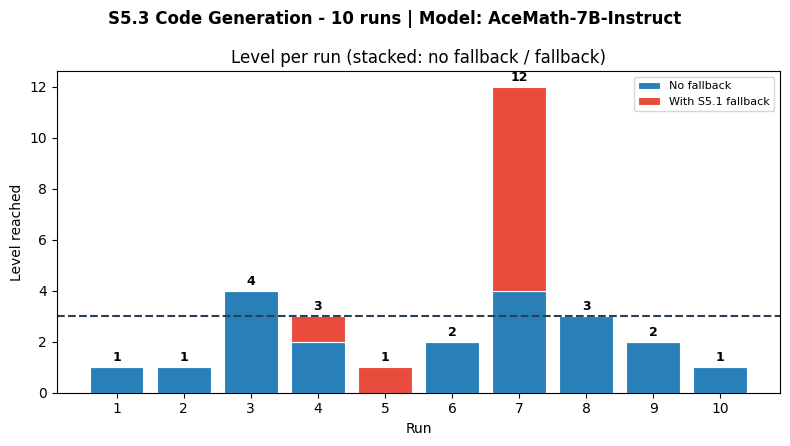

In [ ]:
# ==============================================================
# S5.3 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

all_logs_s53, run_stats_s53, agg_path_s53, df_s53 = run_s5_multirun(
    ask_llm_math_code_wrapper,
    LOGS_DIR_S53,
    section_tag="s53",
    strategy_label="S5.3 Code Generation",
)


### **S5.3 — Final Summary (main failures)**


1. **Generated code does not run** — syntax errors, undefined names, or bad scoping in the script

2. **Code runs but does not really solve the problem** — the block executes and prints something, but the logic is wrong: hardcoded `result = <option>`, incorrect formulas, or a script that encodes the answer instead of computing it.

3. **time limit**


---
## **S5.4 — Code Generation + Self-Review**

### **Objective**

Reduce execution errors observed in S5.3 by adding a **self-review stage** before the final option is selected.

The goal is to catch incorrect generated code (wrong coefficients, incomplete conditionals, or logic errors) and optionally regenerate a corrected script.

### **Approach**

S5.4 extends the S5.3 pipeline with one additional verification step:

1. **Code generation**
2. **Sandbox execution**
3. **Self-review** of code and result
4. **Optional fix + re-execution**
5. **Final option selection**

```text
Question → code generation → execute → review → (fix + re-execute) → FINAL_ANSWER: <id>
```

During review, the model sees:
* the original question;
* the generated code;
* the execution result.

It returns either `REVIEW: OK` or `REVIEW: FIX` followed by corrected code.

### **Budget Management**

If the first stages already consume more than half of the available time budget, the review step is skipped to reduce the risk of timeout.

### **Fallback Rule**

If execution fails before review, the system falls back to **S5.1**.


In [ ]:
# ==============================================================
# S5.4 — CODE GENERATION + SELF-REVIEW
# ==============================================================

import io as _io6, contextlib as _ctx6, traceback as _tb6
import math as _m6, cmath as _cm6, fractions as _fr6
import itertools as _it6, statistics as _st6, functools as _fc6, operator as _op6


def _safe_exec_s54(code: str) -> tuple:
    buf = _io6.StringIO()
    local_ns = {}
    safe_globals = {
        "__builtins__": _sandbox_builtins(),
        "math": _m6, "cmath": _cm6, "fractions": _fr6, "Fraction": _fr6.Fraction,
        "itertools": _it6, "statistics": _st6, "functools": _fc6, "operator": _op6,
    }

    try:
        with _ctx6.redirect_stdout(buf):
            exec(compile(code, "<s54_generated>", "exec"), safe_globals, local_ns)

        out = buf.getvalue().strip()
        if not out:
            for key in ("result", "answer", "ans", "output", "value"):
                if key in local_ns:
                    out = str(local_ns[key])
                    break

        return True, out

    except Exception as e:
        return False, f"EXEC_ERROR: {e}\n{_tb6.format_exc(limit=2)}"


def _build_review_prompt(question_text: str, options, code: str, computed: str) -> tuple:
    opts_str, _ = _get_options_str(options)

    system = (
        "You are a precise math code reviewer. "
        "Check whether the code actually solves the given multiple-choice math question."
    )

    user = (
        f"Question:\n{question_text}\n\n"
        f"Options:\n{opts_str}\n\n"
        f"Executed code:\n```python\n{code}\n```\n\n"
        f"Execution result: {computed}\n\n"
        "Task:\n"
        "- If the code is logically correct, respond exactly: REVIEW: OK\n"
        "- If the code is wrong, respond with: REVIEW: FIX\n"
        "  followed by one corrected Python code block.\n"
        "- Corrected code must set result and end with print(result)."
    )

    return system, user


def ask_llm_math_code_exec_s54(
    question_text,
    options,
    model,
    tokenizer,
    max_new_tokens_code=512,
    max_new_tokens_review=192,
    max_new_tokens_pick=192,
    time_budget_s=22.0,
):
    """
    S5.4 three-stage pipeline:
    Stage 1 — code generation.
    Stage 2 — sandbox execution.
    Stage 3 — optional self-review.
    Stage 4 — option picking from computed result.
    Fallback: S5.1 simple prompt.
    """
    t_start = time.time()

    sys1, usr1 = _build_prompt_code_gen(question_text, options)
    _, raw1, _ = ask_llm_with_prompt(
        sys1,
        usr1,
        options,
        model,
        tokenizer,
        max_new_tokens=max_new_tokens_code,
    )

    code = _extract_code_from_text(raw1)
    ok, computed = _safe_exec_s54(code)
    print(f"  [S5.4-S1] exec_ok={ok} | computed={computed[:50]!r}")

    if not ok or not computed.strip() or str(computed).startswith("EXEC_ERROR"):
        preview = (code or "")[:80].replace("\n", " ")
        print(f"  [S5.4] exec failed — fallback | code: {preview!r}")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = append_s5_trace(
            "", "[S54_FALLBACK_EXEC]",
            stage1_code_gen=raw1, code_extracted=code, exec_output=computed, model_fallback=raw_fb,
        )
        return ans, trace, time.time() - t_start

    tag = "[S54_REVIEW_SKIPPED_BUDGET]"
    raw_rev = None
    elapsed_so_far = time.time() - t_start

    if elapsed_so_far < time_budget_s * 0.45:
        sys_rev, usr_rev = _build_review_prompt(question_text, options, code, computed)
        _, raw_rev, _ = ask_llm_with_prompt(
            sys_rev,
            usr_rev,
            options,
            model,
            tokenizer,
            max_new_tokens=max_new_tokens_review,
        )

        if "REVIEW: FIX" in raw_rev.upper():
            fixed_code = _extract_code_from_text(raw_rev)
            ok2, computed2 = _safe_exec_s54(fixed_code)
            print(f"  [S5.4-S3] fixed_exec_ok={ok2} | computed={computed2[:50]!r}")

            if ok2 and computed2.strip():
                code = fixed_code
                computed = computed2
                tag = "[S54_REVIEW_FIXED]"
            else:
                tag = "[S54_REVIEW_FIX_FAILED]"
        else:
            print("  [S5.4-S3] REVIEW: OK")
            tag = "[S54_REVIEW_OK]"
    else:
        print("  [S5.4-S3] review skipped — budget tight")

    ans, raw2 = _pick_answer_from_computed(
        question_text, options, computed, model, tokenizer, max_new_tokens_pick,
    )

    trace_kwargs = dict(
        stage1_code_gen=raw1, code_extracted=code, exec_output=computed, stage2_pick=raw2,
    )
    if raw_rev is not None:
        trace_kwargs["stage_review"] = raw_rev

    if ans is None:
        ans_fb, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace_kwargs["model_fallback"] = raw_fb
        trace = append_s5_trace("", f"[S54_FALLBACK_PICK]{tag}", **trace_kwargs)
        return ans_fb, trace, time.time() - t_start

    trace = append_s5_trace("", f"[S54_CODE_OK]{tag}", **trace_kwargs)
    return ans, trace, time.time() - t_start


def ask_llm_math_s54_wrapper(
    question_text,
    options,
    model,
    tokenizer,
    comp_id=None,
    max_new_tokens=None,
    time_left_s=None,
    level=None,
    **kwargs,
):
    budget = time_left_s if time_left_s else 22.0
    return ask_llm_math_code_exec_s54(
        question_text,
        options,
        model,
        tokenizer,
        time_budget_s=budget,
    )


print("S5.4 — ask_llm_math_code_exec_s54 defined.")

Starting 10 runs - S5.4 Code Generation + Self-Review | Math competition
Play params: {'max_new_tokens': 256, 'max_think_s': 22.0, 'reserve_submit_s': 3.0}

================================================== RUN 1/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268816

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Suppose V is a real vector space of finite dimension n. Call the set of matrices from V into itself M(V). Let T be in M(V). Consider the two subspaces U = {X ∈ M(V) : TX = XT} and W = {TX − XT : X ∈ M(V)}. Which of the following must be TRUE?
I. If V has a basis containing only eigenvectors of T then U = M(V).
II. dim (U) + dim (W) = n^2
III. dim (U) < n
  [0] I only
  [1] I and II only
  [2] II only
  [3] III only


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [S5.4-S1] exec_ok=True | computed='1'
  [S5.4-S3] review skipped — budget tight
  → Answer: 2 (LLM: 31.65s | total: 31.65s)
  → Raw: '
[S54_CODE_OK][S54_REVIEW_SKIPPED_BUDGET]
[S5_stage1_code_gen_BEGIN]
```python
import math

# Define the dimension n
n =...'
  [TIME] Too late to submit safely: 0.00s left

GAME OVER — Level reached: 1
Total earned: $0.00
Log saved: 1 entries → /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s54/game_log_AceMath-7B-Instruct_2026-05-29_18-41-16_Math.json

================================================== RUN 2/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268825

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Statement 1 | Every free abelian group is torsion free. Statement 2 | Every finitely generated torsion-free abelian group is a free abelian group.
  [0] True, True
  [1] False, False
  [2] False, True
  [3] True, False
  [S5.4-S1] exec_ok=True | computed='0'
  [S5.4-S3] REVIEW: OK


/tmp/ipykernel_3538/1752690160.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_run_stack)


Plot saved: /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s54/s54_multirun_plot_AceMath-7B-Instruct.png


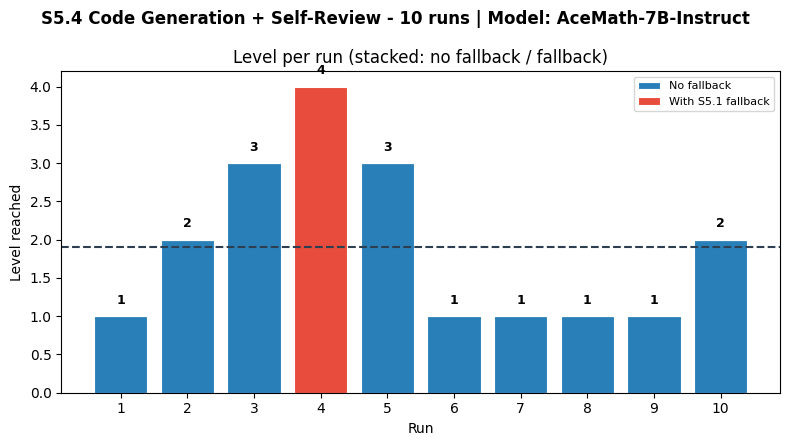

Review OK events: 9
Review fixed events: 1
Fallback events: 2
Avg elapsed/question: 22.4s


In [ ]:
# ==============================================================
# S5.4 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

def _enrich_s54(df):
    df = df.copy()
    df["is_review_ok"]    = df["raw_output"].str.contains(r"S54_REVIEW_OK",    na=False)
    df["is_review_fixed"] = df["raw_output"].str.contains(r"S54_REVIEW_FIXED", na=False)
    df["is_fallback"]     = df["raw_output"].str.contains(r"S54_FALLBACK",      na=False)
    return df


all_logs_s54, run_stats_s54, agg_path_s54, df_s54 = run_s5_multirun(
    ask_llm_math_s54_wrapper,
    LOGS_DIR_S54,
    section_tag="s54",
    strategy_label="S5.4 Code Generation + Self-Review",
    enrich_df=_enrich_s54,
)

print(f"Review OK events: {df_s54['is_review_ok'].sum()}")
print(f"Review fixed events: {df_s54['is_review_fixed'].sum()}")
print(f"Fallback events: {df_s54['is_fallback'].sum()}")
print(f"Avg elapsed/question: {df_s54['elapsed_s'].mean():.1f}s")


### **S5.4 — Final Summary (main failures)**


**Self-review is largely ineffective** the pipeline often **exceeds time** When review does run, it usually **does not fix the real problems**: hardcoded answers, wrong formulas, and conceptual items are left unchanged.

---
## **S5.5 — Function Registry + Dynamic Code Generation**

### **Objective**
Combine the flexibility of code generation of S5.3 with the reliability of **pre-defined functions** of S5.2.

The motivation is to reduce formula errors that appear when the model writes all computations from scratch, while still allowing custom code when the registry is not sufficient.


### **How it works**
* if a registry function fits → it writes Python that **calls it by name** (e.g. `result = combinations(10, 3)`);
* otherwise → it writes **custom Python** in the same script.

```text
Question → code generation → _safe_exec_s55() → computed value → FINAL_ANSWER: <id>
```

### **Fallback Rule**

If execution fails, the system falls back to **S5.1**.



In [ ]:
# ==============================================================
# S5.5 — FUNCTION REGISTRY (28 verified math helper functions)
# ==============================================================

import math as _mr, fractions as _frr, itertools as _itr
import statistics as _str, inspect as _insp


# ── Arithmetic & Expressions ─────────────────────────────────────

def reg_calculate(expression: str) -> str:
    """Evaluates a Python math expression. Available: math.*, fractions.Fraction, itertools, abs, round, sum, min, max."""
    return str(eval(expression, {
        "math": _mr, "fractions": _frr, "Fraction": _frr.Fraction,
        "itertools": _itr, "abs": abs, "round": round, "sum": sum,
        "min": min, "max": max, "sorted": sorted, "__builtins__": {}
    }))

def reg_modular_power(base: int, exp: int, mod: int) -> int:
    """(base ** exp) % mod efficiently. Use for modular arithmetic with large exponents."""
    return pow(int(base), int(exp), int(mod))

def reg_compute_modulo(a: int, n: int) -> int:
    """a mod n. Use for last digits, congruence problems."""
    return int(a) % int(n)


# ── Number Theory ────────────────────────────────────────────────

def reg_compute_gcd(a: int, b: int) -> int:
    """Greatest Common Divisor of two integers."""
    return _mr.gcd(int(a), int(b))

def reg_compute_lcm(a: int, b: int) -> int:
    """Least Common Multiple of two integers."""
    return abs(int(a) * int(b)) // _mr.gcd(int(a), int(b))

def reg_is_prime(n: int) -> bool:
    """True if n is prime. Works for n >= 0."""
    n = int(n)
    if n < 2: return False
    if n < 4: return True
    if n % 2 == 0 or n % 3 == 0: return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0: return False
        i += 6
    return True

def reg_prime_factorization(n: int) -> list:
    """Prime factorization as [(prime, exponent), ...]. Useful for Abelian groups, number theory."""
    n, factors = int(n), {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors[d] = factors.get(d, 0) + 1
            n //= d
        d += 1
    if n > 1: factors[n] = factors.get(n, 0) + 1
    return list(factors.items())

def reg_euler_totient(n: int) -> int:
    """Euler's totient φ(n): count of integers in [1,n] coprime with n."""
    n, result, temp = int(n), int(n), int(n)
    p = 2
    while p * p <= temp:
        if temp % p == 0:
            while temp % p == 0: temp //= p
            result -= result // p
        p += 1
    if temp > 1: result -= result // temp
    return result

def reg_digits_sum(n: int) -> int:
    """Sum of decimal digits of n."""
    return sum(int(d) for d in str(abs(int(n))))

def reg_count_divisors(n: int) -> int:
    """Number of positive divisors of n."""
    n, count = abs(int(n)), 0
    for i in range(1, int(_mr.isqrt(n)) + 1):
        if n % i == 0:
            count += 2 if i != n // i else 1
    return count


# ── Combinatorics ────────────────────────────────────────────────

def reg_combinations(n: int, k: int) -> int:
    """C(n, k) = n! / (k! * (n-k)!). Choosing k from n, order does NOT matter."""
    return _mr.comb(int(n), int(k))

def reg_permutations(n: int, k: int) -> int:
    """P(n, k) = n! / (n-k)!. Choosing k from n, order matters."""
    return _mr.perm(int(n), int(k))

def reg_factorial(n: int) -> int:
    """n! (factorial)."""
    return _mr.factorial(int(n))

def reg_count_arrangements_with_repetition(n: int, *ks) -> int:
    """Multinomial: n! / (k1! * k2! * ...) for arrangements with repetition."""
    denom = 1
    for k in ks: denom *= _mr.factorial(int(k))
    return _mr.factorial(int(n)) // denom


# ── Algebra ──────────────────────────────────────────────────────

def reg_solve_quadratic(a: float, b: float, c: float) -> str:
    """Roots of a*x^2 + b*x + c = 0."""
    disc = b**2 - 4*a*c
    if disc < 0: return "No real solutions"
    if disc == 0: return str(round(-b / (2*a), 6))
    return f"{round((-b+_mr.sqrt(disc))/(2*a), 6)}, {round((-b-_mr.sqrt(disc))/(2*a), 6)}"

def reg_arithmetic_sum(a1: float, n: int, d: float) -> float:
    """Sum of arithmetic sequence: S = n/2 * (2*a1 + (n-1)*d)."""
    return n / 2 * (2*a1 + (n-1)*d)

def reg_geometric_sum(a1: float, r: float, n: int) -> float:
    """Sum of geometric sequence: S = a1*(1 - r^n)/(1 - r)."""
    if r == 1: return a1 * n
    return a1 * (1 - r**n) / (1 - r)

def reg_log_base(x: float, base: float) -> float:
    """Logarithm of x in the given base."""
    return _mr.log(x) / _mr.log(base)


# ── Probability ──────────────────────────────────────────────────

def reg_probability(favorable: int, total: int) -> float:
    """Simple probability = favorable / total."""
    return int(favorable) / int(total)

def reg_conditional_probability(p_a_and_b: float, p_b: float) -> float:
    """P(A|B) = P(A ∩ B) / P(B)."""
    return p_a_and_b / p_b


# ── Statistics ───────────────────────────────────────────────────

def reg_mean(values: list) -> float:
    """Arithmetic mean of a list of numbers."""
    return sum(values) / len(values)

def reg_variance(values: list) -> float:
    """Population variance."""
    mu = reg_mean(values)
    return sum((x - mu)**2 for x in values) / len(values)

def reg_std_dev(values: list) -> float:
    """Population standard deviation."""
    return _mr.sqrt(reg_variance(values))


# ── Geometry ─────────────────────────────────────────────────────

def reg_circle_area(r: float) -> float:
    """Area of a circle with radius r."""
    return _mr.pi * r**2

def reg_triangle_area(base: float, height: float) -> float:
    """Area of a triangle."""
    return 0.5 * base * height

def reg_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """Euclidean distance between two 2D points."""
    return _mr.sqrt((x2-x1)**2 + (y2-y1)**2)


# ── Build registry dict + description string ─────────────────────

FUNCTION_REGISTRY = {
    name: func for name, func in [
        ("calculate", reg_calculate), ("modular_power", reg_modular_power),
        ("compute_modulo", reg_compute_modulo), ("compute_gcd", reg_compute_gcd),
        ("compute_lcm", reg_compute_lcm), ("is_prime", reg_is_prime),
        ("prime_factorization", reg_prime_factorization), ("euler_totient", reg_euler_totient),
        ("digits_sum", reg_digits_sum), ("count_divisors", reg_count_divisors),
        ("combinations", reg_combinations), ("permutations", reg_permutations),
        ("factorial", reg_factorial), ("count_arrangements_with_repetition", reg_count_arrangements_with_repetition),
        ("solve_quadratic", reg_solve_quadratic), ("arithmetic_sum", reg_arithmetic_sum),
        ("geometric_sum", reg_geometric_sum), ("log_base", reg_log_base),
        ("probability", reg_probability), ("conditional_probability", reg_conditional_probability),
        ("mean", reg_mean), ("variance", reg_variance), ("std_dev", reg_std_dev),
        ("circle_area", reg_circle_area), ("triangle_area", reg_triangle_area),
        ("distance", reg_distance),
    ]
}

REGISTRY_DESCRIPTION = "\n".join(
    f"- {name}({', '.join(_insp.signature(fn).parameters)}): {fn.__doc__.split('.')[ 0]}"
    for name, fn in FUNCTION_REGISTRY.items()
)

print(f"Function Registry loaded: {len(FUNCTION_REGISTRY)} functions")
print("\nAvailable functions:")
print(REGISTRY_DESCRIPTION)

In [ ]:
# ==============================================================
# S5.5 — PIPELINE: ask_llm_math_code_s55
# ==============================================================

import io as _io7, contextlib as _ctx7, traceback as _tb7
import math as _m7, cmath as _cm7, fractions as _fr7
import itertools as _it7, statistics as _st7, functools as _fc7, operator as _op7


def _safe_exec_s55(code: str, registry: dict) -> tuple:
    """Execute code in namespace pre-loaded with all registry functions + math modules."""
    buf = _io7.StringIO()
    local_ns = {}
    safe_globals = {
        "__builtins__": _sandbox_builtins(),
        "math": _m7, "cmath": _cm7, "fractions": _fr7, "Fraction": _fr7.Fraction,
        "itertools": _it7, "statistics": _st7, "functools": _fc7, "operator": _op7,
        **registry,
    }
    try:
        with _ctx7.redirect_stdout(buf):
            exec(compile(code, "<s54_generated>", "exec"), safe_globals, local_ns)
        out = buf.getvalue().strip()
        if not out:
            for key in ("result", "answer", "ans", "output", "value"):
                if key in local_ns:
                    out = str(local_ns[key])
                    break
        return True, out
    except Exception as e:
        return False, f"EXEC_ERROR: {e}\n{_tb7.format_exc(limit=2)}"


def _build_prompt_code_gen_s55(question_text: str, options) -> tuple:
    """Stage 1: ask the LLM to write code that uses the pre-loaded registry."""
    opts_str, _ = _get_options_str(options)
    system = (
        "You are a math computation expert with access to a pre-loaded function registry.\n\n"
        "Available functions (already in scope — do NOT import or redefine them):\n"
        f"{REGISTRY_DESCRIPTION}\n\n"
        "Also available: math, cmath, fractions.Fraction, itertools, statistics.\n"
        "Do NOT import numpy, sympy, or any external library.\n"
        "Do NOT write FINAL_ANSWER — only Python code.\n"
        "Use registry functions where possible; define new functions only if needed.\n"
        "Store the final answer in 'result' and end with print(result)."
    )
    user = (
        f"Solve this math problem using Python.\n\n"
        f"Question:\n{question_text}\n\n"
        f"Options (for reference — do NOT pick one yet):\n{opts_str}\n\n"
        "Output ONLY a Python code block ending with print(result).\n"
        "```python\n# use registry functions directly\nresult = ...\nprint(result)\n```"
    )
    return system, user


def ask_llm_math_code_s55(question_text, options, model, tokenizer,
                           max_new_tokens_code=512, max_new_tokens_pick=192):
    """
    S5.5 pipeline:
    Stage 1 — LLM writes code using registry functions.
    Stage 2 — _safe_exec_s54() runs code with registry injected.
    Stage 3 — LLM picks the closest option.
    Fallback: exec error → S5.1 simple prompt.
    """
    t_start = time.time()
    sys1, usr1 = _build_prompt_code_gen_s55(question_text, options)
    _, raw1, _ = ask_llm_with_prompt(sys1, usr1, options, model, tokenizer,
                                      max_new_tokens=max_new_tokens_code)
    code = _extract_code_from_text(raw1)
    ok, computed = _safe_exec_s55(code, FUNCTION_REGISTRY)
    print(f"  [S5.5] exec_ok={ok} | computed={computed[:60]!r}")

    if not ok or not computed.strip() or str(computed).startswith("EXEC_ERROR"):
        preview = (code or "")[:80].replace("\n", " ")
        print(f"  [S5.5] exec failed — fallback | code: {preview!r}")
        ans, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = append_s5_trace(
            "", "[S55_FALLBACK_EXEC]",
            stage1_code_gen=raw1, code_extracted=code, exec_output=computed, model_fallback=raw_fb,
        )
        return ans, trace, time.time() - t_start

    ans, raw2 = _pick_answer_from_computed(
        question_text, options, computed, model, tokenizer, max_new_tokens_pick,
    )
    if ans is None:
        ans_fb, raw_fb, _ = ask_llm_math_fallback(question_text, options, model, tokenizer)
        trace = append_s5_trace(
            "", "[S55_FALLBACK_PICK]",
            stage1_code_gen=raw1, code_extracted=code, exec_output=computed,
            stage2_pick=raw2, model_fallback=raw_fb,
        )
        return ans_fb, trace, time.time() - t_start

    trace = append_s5_trace(
        "", "[S55_OK]",
        stage1_code_gen=raw1, code_extracted=code, exec_output=computed, stage2_pick=raw2,
    )
    return ans, trace, time.time() - t_start


def ask_llm_math_s55_wrapper(question_text, options, model, tokenizer,
                              comp_id=None, max_new_tokens=None,
                              time_left_s=None, level=None, **kwargs):
    """Drop-in wrapper for play_automated."""
    return ask_llm_math_code_s55(question_text, options, model, tokenizer)


print("S5.5 — ask_llm_math_code_s55 defined.")

Starting 10 runs - S5.5 Function Registry | Math competition
Play params: {'max_new_tokens': 256, 'max_think_s': 22.0, 'reserve_submit_s': 3.0}

================================================== RUN 1/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 268935

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: Consider a hypothesis test with H0 : μ = 70 and Ha : μ < 70. Which of the following choices of significance level and sample size results in the greatest power of the test when μ = 65?
  [0] α = 0.01, n = 15
  [1] α = 0.01, n = 30
  [2] α = 0.05, n = 15
  [3] α = 0.05, n = 30


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [S5.5] exec_ok=True | computed='3'
  → Answer: 3 (LLM: 20.60s | total: 20.60s)
  → Raw: '
[S55_OK]
[S5_stage1_code_gen_BEGIN]
```python
# use registry functions directly
result = 3  # The choice with α = 0.05 ...'
  ✅ CORRECT! Earned: $100.00

--- Level 2 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: An amoeba is placed in a puddle one day, and on that same day it splits into two amoebas. The next day, each new amoeba splits into two new amoebas, and so on, so that each day every living amoeba splits into two new amoebas. After one week, how many amoebas are in the puddle? (Assume the puddle has no amoebas before the first one is placed in the puddle.)
  [0] 128
  [1] 256
  [2] 64
  [3] 1024
  [S5.5] exec_ok=True | computed='128'
  → Answer: 0 (LLM: 30.54s | total: 30.54s)
  → Raw: '
[S55_OK]
[S5_stage1_code_gen_BEGIN]
```python
# The number of amoebas doubles each day, starting with 1 amoeba.
# After...'
  [TIME] Too late to submit safely: 0.00s left

GAME OVER — Level reach

/tmp/ipykernel_3538/1752690160.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_run_stack)


Plot saved: /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s55/s55_multirun_plot_AceMath-7B-Instruct.png


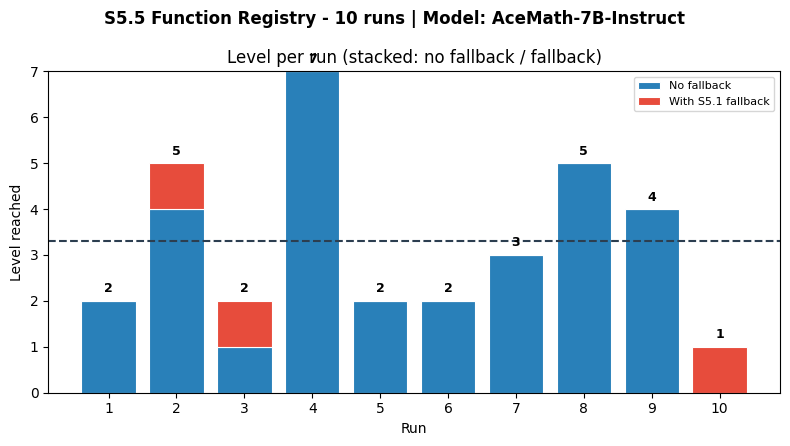

Fallback events: 3


In [ ]:
# ==============================================================
# S5.5 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

def _enrich_s55(df):
    df = df.copy()
    df["is_fallback"] = df["raw_output"].str.contains("S55_FALLBACK", na=False)
    return df


all_logs_s55, run_stats_s55, agg_path_s55, df_s55 = run_s5_multirun(
    ask_llm_math_s55_wrapper,
    LOGS_DIR_S55,
    section_tag="s55",
    strategy_label="S5.5 Function Registry",
    enrich_df=_enrich_s55,
)

print(f"Fallback events: {df_s55['is_fallback'].sum()}")


### **S5.5 — Final Summary**
There was no accuracy gain, only higher latency and complexity.

---
## **S5.6.1 — Few-Shot with Category-Aware prompt**

### **Approach**

Enable Chain of Thought (CoT) to improve reasoning performance, and provide the model with two examples that closely resemble the target question. Each example include the question, the correct answer, and the reasoning process used to arrive at that answer.

In [ ]:
# ==============================================================
# S5.6 — FEW-SHOT COT PROMPT BUILDER
# ==============================================================

def build_math_routed_prompt(question_text, options, category, n_shots=2, shot_mode="similar"):
    opts = normalize_options(options) or {"0": "N/A"}
    allowed_ids = sort_option_ids(opts.keys())
    allowed = ", ".join(allowed_ids)
    current_opts = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)

    if n_shots <= 0:
        shots = []
    elif shot_mode == "static":
        shots = MATH_FEWSHOTS.get(category, [])[:n_shots]
    else:
        shots = select_fewshots(category, question_text, options, k=n_shots)

    examples = []
    for ex in shots:
        ex_opts = ex.get("options", {})
        if str(ex.get("correct_answer")) not in ex_opts:
            continue

        ex_opt_ids = sort_option_ids(ex_opts.keys())
        ex_opts_str = "\n".join(f"{k}) {ex_opts[k]}" for k in ex_opt_ids)
        reasoning = ex.get("reasoning", "").strip()

        if reasoning:
            examples.append(
                f"Example\nQuestion:\n{ex['question']}\n\n"
                f"Options:\n{ex_opts_str}\n\n"
                f"WORK: {reasoning}\n"
                f"FINAL_ANSWER: {ex['correct_answer']}"
            )
        else:
            examples.append(
                f"Example\nQuestion:\n{ex['question']}\n\n"
                f"Options:\n{ex_opts_str}\n\n"
                f"FINAL_ANSWER: {ex['correct_answer']}"
            )

    system = (
        "You are a precise math multiple-choice solver. "
        "Use the examples as method templates. "
        "Solve with a brief calculation, compare the result with the options, "
        "and finish with FINAL_ANSWER: <id>."
    )

    user = (
        f"Math category: {category}\n"
        f"Category method: {METHOD_CATEGORY_HINTS.get(category, METHOD_CATEGORY_HINTS['misc_math'])}\n\n"
        + ("\n\n".join(examples) + "\n\n" if examples else "")
        + f"Now solve this question.\nQuestion:\n{question_text}\n\n"
        f"Options:\n{current_opts}\n\n"
        f"The answer must be the id of one of these options: {allowed}.\n"
        "If the question asks CANNOT, NOT, EXCEPT, or false, choose the impossible/false option, not a valid one.\n"
        "If the question asks for all values, a sum, a count, or a product, complete that final requested operation before choosing the option.\n"
        "For Statement 1 / Statement 2 questions, evaluate both statements independently and match the exact True/False pair.\n"
        "In experimental-design questions, distinguish explanatory variable, response variable, and levels carefully.\n"
        "Match the final computed value to the current option ids; do not copy ids from examples.\n"
        "Use this exact format:\n"
        "WORK: <brief calculation, at most 4 lines>\n"
        "FINAL_ANSWER: <id>"
    )

    return system, user, len(examples)


def ask_llm_math_routed(question_text, options, model, tokenizer,
                        max_new_tokens=None, shot_mode="similar", n_shots=2):
    category = classify_math_question(question_text, options)

    system, user, shots_used = build_math_routed_prompt(
        question_text,
        options,
        category,
        n_shots=n_shots,
        shot_mode=shot_mode,
    )

    tokens = max_new_tokens or 192

    _, raw, elapsed = ask_llm_with_prompt(
        system,
        user,
        options,
        model,
        tokenizer,
        max_new_tokens=tokens,
    )

    ans = parse_math_answer(raw, options)

    if ans is None:
        opts = normalize_options(options)
        allowed_ids = sort_option_ids(opts.keys())
        opts_str = "\n".join(f"{k}) {opts[k]}" for k in allowed_ids)

        extractor_system = (
            "You extract the final multiple-choice option id from a math solution. "
            "Return only one line: FINAL_ANSWER: <id>."
        )

        extractor_user = (
            f"Question:\n{question_text}\n\n"
            f"Options:\n{opts_str}\n\n"
            f"Previous model output:\n{raw}\n\n"
            f"The answer must be one of: {', '.join(allowed_ids)}.\n"
            "Return exactly one line: FINAL_ANSWER: <id>"
        )

        ans2, raw2, elapsed2 = ask_llm_math_answer_only(
            extractor_system,
            extractor_user,
            options,
            model,
            tokenizer,
            max_new_tokens=8,
        )

        if ans2 is not None:
            return (
                ans2,
                raw + "\n[EXTRACTED]\n" + raw2 + f"\n[MATH_CATEGORY={category}][SHOTS_USED={shots_used}]",
                elapsed + elapsed2,
            )

    return ans, raw + f"\n[MATH_CATEGORY={category}][SHOTS_USED={shots_used}]", elapsed


def ask_llm_math_routed_wrapper(question_text, options, model, tokenizer,
                                comp_id=None, max_new_tokens=None,
                                time_left_s=None, level=None, **kwargs):
    return ask_llm_math_routed(
        question_text,
        options,
        model,
        tokenizer,
        max_new_tokens=max_new_tokens,
        shot_mode="similar",
        n_shots=2,
    )


print("S5.6 — build_math_routed_prompt and ask_llm_math_routed defined.")

S5.6 — build_math_routed_prompt and ask_llm_math_routed defined.


Starting 10 runs - S5.6 Few-Shot CoT + Routing | Math competition
Play params: {'max_new_tokens': 256, 'max_think_s': 22.0, 'reserve_submit_s': 3.0}

================================================== RUN 1/10

Starting game [text]: competition 3 (Math) | model: nvidia/AceMath-7B-Instruct
Session ID: 269073

--- Level 1 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: How many three-digit positive integers are there?
  [0] 1000
  [1] 900
  [2] 899
  [3] 999


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  → Answer: 1 (LLM: 4.46s | total: 4.46s)
  → Raw: 'WORK: Three-digit positive integers range from 100 to 999. The count of these integers is 999 - 100 + 1 = 900.
FINAL_ANS...'
  ✅ CORRECT! Earned: $100.00

--- Level 2 | mode=text | Time left: 29.9s | Budget: 22.0s ---
Q: A telephone survey of 400 registered voters showed that 256 had not yet made up their minds 1 month before the election. How sure can we be that between 60% and 68% of the electorate were still undecided at that time?
  [0] 64.0%
  [1] 2.4%
  [2] 90.4%
  [3] 8.0%
  → Answer: 0 (LLM: 11.15s | total: 11.15s)
  → Raw: 'WORK: The proportion of undecided voters in the sample is 256/400 = 0.64 or 64%. The confidence interval for the proport...'
  ❌ WRONG! Game over. Earned: $100.00

GAME OVER — Level reached: 2
Total earned: $100.00
Log saved: 2 entries → /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s56_speech/game_log_AceMath-7B-Instruct_2026-05-29_18-58-34_Math.json

================================================== RU

/tmp/ipykernel_3538/1752690160.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_aggregate_run_stack)


Plot saved: /content/drive/MyDrive/NLP/NLP_ASSIGNMENT/logs_s56_speech/s56_multirun_plot_AceMath-7B-Instruct.png


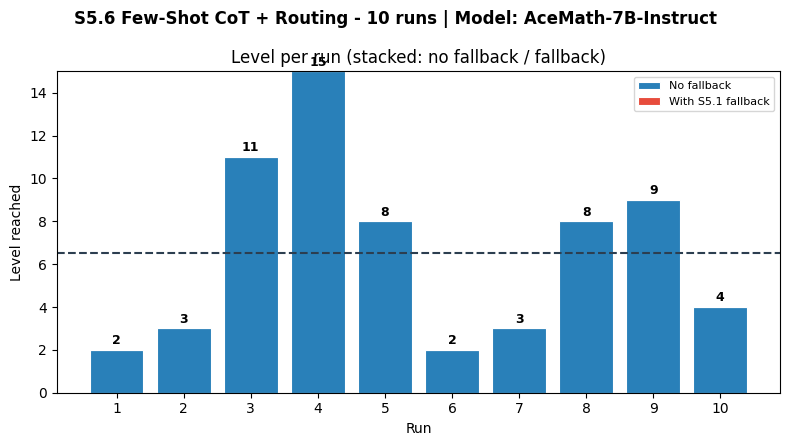

In [ ]:
# ==============================================================
# S5.6 — 10 RUNS + PERFORMANCE PLOT
# ==============================================================

all_logs_s56, run_stats_s56, agg_path_s56, df_s56 = run_s5_multirun(
    ask_llm_math_routed_wrapper,
    LOGS_DIR_S56,
    section_tag="s56",
    strategy_label="S5.6 Few-Shot CoT + Routing",
    n_runs = 10
)


---
# **S6 — Final Considerations and Competition Setup**

## **Objective**

In this final section, we summarize the main findings from the previous experiments and define the final routing strategy that would be used in a competition-like setting.

The goal is not to use a single model and a single strategy for every category, but to select the most appropriate configuration depending on the type of question.

## **Final Strategy**

| Competition ID | Category | Final Strategy | Model |
|:---|:---|:---|:---|
| **0** | **Entertainment** | RAG | `google/gemma-2-9b-it` |
| **1** | **Ancient History** | RAG | `google/gemma-2-9b-it` |
| **2** | **Science and Nature** | RAG | `google/gemma-2-9b-it` |
| **3** | **Math** | Math-specific prompting / routing | `nvidia/AceMath-7B-Instruct` |
| **4** | **Philosophy and Psychology** | Baseline prompt | `google/gemma-2-9b-it` |
| **5** | **News** | RAG with news retrieval | `google/gemma-2-9b-it` |

<br>
The final setup follows a selective routing approach.

For **Entertainment**, **Ancient History**, **Science and Nature**, and **News**, retrieval is enabled because these categories often require external factual evidence, named entities, dates, works, events, or article-specific information. In particular, **News** benefits from retrieval because questions can refer to recent or source-specific articles that are not reliably available from the model parameters alone.

For **Math**, retrieval is not used because most questions require computation, symbolic reasoning, or multi-step problem solving rather than factual lookup. For this reason, Math is routed to the dedicated model **`nvidia/AceMath-7B-Instruct`**.

For **Philosophy and Psychology**, the strongest baseline results were already high and RAG did not provide a sufficiently consistent benefit to justify the additional retrieval latency and possible context noise. Therefore, this category keeps the baseline prompt with **`google/gemma-2-9b-it`**.

## **Final Considerations**

The final competition setup combines the most reliable components: **Gemma-2-9B-it** as the main factual model, selective RAG for categories where external evidence is useful, and **AceMath-7B-Instruct** for Math.

In [ ]:
# ==================================================
# S6.1 — FINAL COMPETITION CONFIGURATION
# ==================================================

LOGS_DIR_FINAL = BASE / "logs_s6_final_competition_setup"
LOGS_DIR_FINAL.mkdir(parents=True, exist_ok=True)

FINAL_FACTUAL_MODEL_ID = "google/gemma-2-9b-it"
FINAL_MATH_MODEL_ID = "nvidia/AceMath-7B-Instruct"

FINAL_RAG_CATEGORIES = {0, 1, 2, 5}
FINAL_BASELINE_CATEGORIES = {4}

FINAL_GEMMA_CATEGORIES = {
    0: "Entertainment",
    1: "Ancient_History",
    2: "Science_and_Nature",
    4: "Philosophy_and_Psychology",
    5: "News",
}

FINAL_MATH_CATEGORIES = {
    3: "Math",
}

N_GAMES_PER_CAT_FINAL = 5

In [ ]:
# ==================================================
# S6.2 — FINAL GEMMA ROUTER
# ==================================================

def _append_strategy_tag(result, tag: str):
    """Attach final strategy metadata to the raw output stored in logs."""
    answer, raw_output, elapsed = result
    raw_output = f"{raw_output}\n[{tag}]"
    return answer, raw_output, elapsed


def ask_llm_final_gemma_router(
    question_text,
    options,
    model,
    tokenizer,
    comp_id=None,
    model_id=None,
    max_new_tokens=None,
    time_left_s=None,
    level=None,
    **kwargs,
):
    """
    Final routing for non-Math categories:
    - RAG for knowledge-intensive categories: 0, 1, 2, 5
    - Naive baseline for Philosophy and Psychology: 4
    """
    if comp_id in FINAL_RAG_CATEGORIES:
        result = ask_llm_retrieval_rag(
            question_text,
            options,
            model=model,
            tokenizer=tokenizer,
            comp_id=comp_id,
            model_id=model_id,
            max_new_tokens=max_new_tokens,
            time_left_s=time_left_s,
            level=level,
        )
        return _append_strategy_tag(result, "FINAL_STRATEGY=RAG")

    result = ask_llm_naive(
        question_text,
        options,
        model,
        tokenizer,
        comp_id=comp_id,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        time_left_s=time_left_s,
        level=level,
    )
    tag = "FINAL_STRATEGY=BASELINE" if comp_id in FINAL_BASELINE_CATEGORIES else "FINAL_STRATEGY=FALLBACK_BASELINE"
    return _append_strategy_tag(result, tag)

In [ ]:
# ====================
# S6.3 — GEMMA SETUP
# ====================

MODEL_ID = FINAL_FACTUAL_MODEL_ID

unload_model_from_memory()
tokenizer, model, local_dir, t_load = load_quantized_model(
    MODEL_ID,
    quant_config=bnb_config,
)

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)

In [ ]:
# ==================================================
# S6.3 — RUN FINAL GEMMA CATEGORIES (TEXT- MODE)
# ==================================================

df_s6_gemma = run_experiment(
    client=client,
    categories=FINAL_GEMMA_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT_FINAL,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_final_gemma_router,
    model_id=MODEL_ID,
    run_prefix="s6_final_gemma",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_FINAL,
    mode="text",
)

In [ ]:
# ==================================================
# S6.3 — RUN FINAL GEMMA CATEGORIES (SPEECH - MODE)
# ==================================================

df_s6_gemma = run_experiment(
    client=client,
    categories=FINAL_GEMMA_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT_FINAL,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_final_gemma_router,
    model_id=MODEL_ID,
    run_prefix="s6_final_gemma",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_FINAL,
    mode="speech",
)

In [ ]:
# ===================
# S6.4 — MATH SETUP
# ===================

MODEL_ID = FINAL_MATH_MODEL_ID

unload_model_from_memory()
tokenizer, model, local_dir, t_load = load_quantized_model(
    MODEL_ID,
    quant_config=bnb_config,
)

play_params = get_play_params(MODEL_ID)
print("Play params:", play_params)


In [ ]:
# =====================================
# S6.4 — RUN FINAL MATH  (TEXT - MODE)
# =====================================

df_s6_math = run_experiment(
    client=client,
    categories=FINAL_MATH_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT_FINAL,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_math_routed_wrapper,
    model_id=MODEL_ID,
    run_prefix="s6_final_math",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_FINAL,
    mode="text",
)

In [ ]:
# =====================================
# S6.4 — RUN FINAL MATH  (SPEECH - MODE)
# =====================================

df_s6_math = run_experiment(
    client=client,
    categories=FINAL_MATH_CATEGORIES,
    n_games_per_cat=N_GAMES_PER_CAT_FINAL,
    model=model,
    tokenizer=tokenizer,
    ask_llm_fn=ask_llm_math_routed_wrapper,
    model_id=MODEL_ID,
    run_prefix="s6_final_math",
    save_logs=True,
    play_params=play_params,
    logs_dir=LOGS_DIR_FINAL,
    mode="speech",
)

In [ ]:
# ==================================================
# S6.5 — FINAL SETUP METRICS
# ==================================================

# Load logs
df_text = load_all_logs(LOGS_DIR_FINAL)
if df_text.empty:
    raise RuntimeError("No S6 final text logs found.")

df_speech = load_all_logs(SPEECH_LOGS_DIR_LARGE)
if df_speech.empty:
    print("⚠️  No speech logs found.")

for df in [df_text, df_speech]:
    df["result"]    = df["result"].astype(str).str.lower()
    df["is_correct"]= df["result"].eq("correct")
    df["level"]     = pd.to_numeric(df["level"], errors="coerce")
    df["elapsed_s"] = pd.to_numeric(df.get("elapsed_s", 0), errors="coerce").fillna(0.0)

df_speech["model_name"] = FINAL_FACTUAL_MODEL_ID

# ===========================================
# Heatmap 1 — Gemma: non-Math, text + speech
# ===========================================
GEMMA_CATS = ["Entertainment", "Ancient_History", "Science_and_Nature",
              "Philosophy_and_Psychology", "News"]

DESIRED_COLS_GEMMA = [
    "Entertainment (text)",                 "Entertainment (speech)",
    "Ancient_History (text)",               "Ancient_History (speech)",
    "Science_and_Nature (text)",            "Science_and_Nature (speech)",
    "Philosophy_and_Psychology (text)",     "Philosophy_and_Psychology (speech)",
    "News (text)",                          "News (speech)",
]

df_gemma = pd.concat([
    df_text[df_text["competition_name"].isin(GEMMA_CATS)],
    df_speech[df_speech["competition_name"].isin(GEMMA_CATS)],
], ignore_index=True)

game_stats_gemma = (
    df_gemma
    .groupby(["model_name", "competition_name", "mode", "session_id"], as_index=False)
    .agg(
        stopping_level  =("is_correct", "sum"),
        answered_questions=("level", "size"),
        avg_elapsed_s   =("elapsed_s", "mean"),
        total_elapsed_s =("elapsed_s", "sum"),
    )
)

table_gemma, _          = table_accuracy(df_gemma)
table_gemma             = table_gemma.reindex(columns=DESIRED_COLS_GEMMA)
pivot_mean_gemma        = make_metric_pivot(game_stats_gemma, "stopping_level", "mean",   desired_cols=DESIRED_COLS_GEMMA)
pivot_median_gemma      = make_metric_pivot(game_stats_gemma, "stopping_level", "median", desired_cols=DESIRED_COLS_GEMMA)

# ===========================================
# Heatmap 2 — AceMath: Math only, text
# ===========================================
DESIRED_COLS_MATH = ["Math (text)", "Math (speech)"]

df_math = df_text[df_text["competition_name"] == "Math"].copy()

game_stats_math = (
    df_math
    .groupby(["model_name", "competition_name", "mode", "session_id"], as_index=False)
    .agg(
        stopping_level    =("is_correct", "sum"),
        answered_questions=("level", "size"),
        avg_elapsed_s     =("elapsed_s", "mean"),
        total_elapsed_s   =("elapsed_s", "sum"),
    )
)

table_math, _       = table_accuracy(df_math)
table_math          = table_math.reindex(columns=DESIRED_COLS_MATH)
pivot_mean_math     = make_metric_pivot(game_stats_math, "stopping_level", "mean",   desired_cols=DESIRED_COLS_MATH)
pivot_median_math   = make_metric_pivot(game_stats_math, "stopping_level", "median", desired_cols=DESIRED_COLS_MATH)

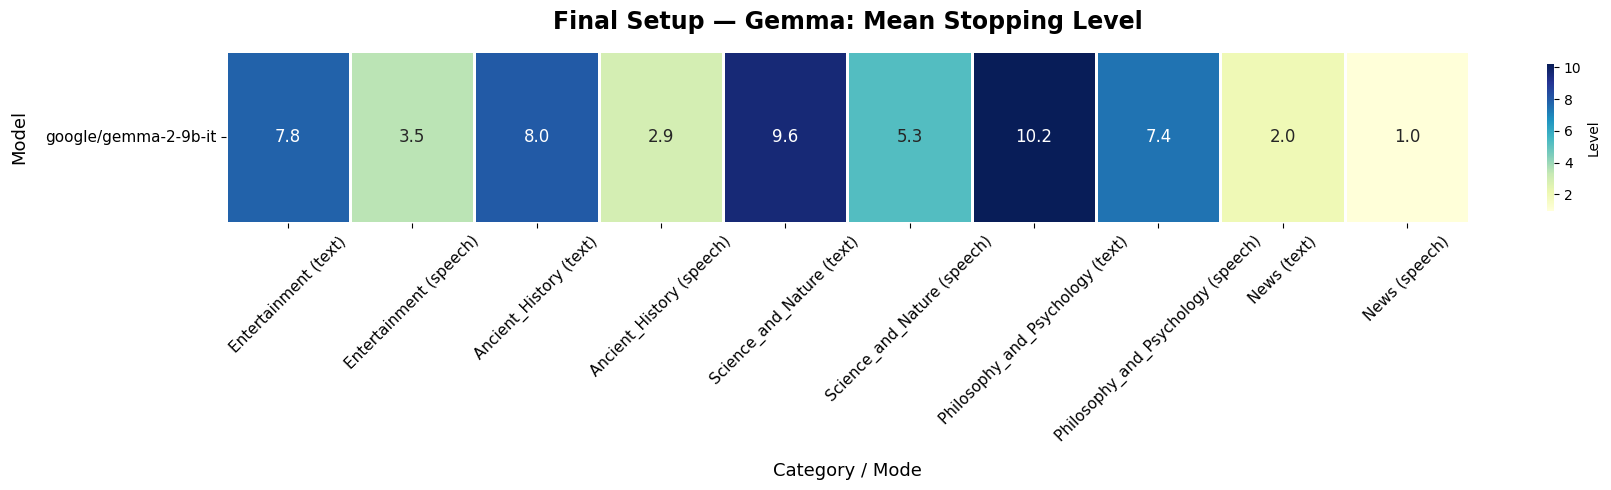

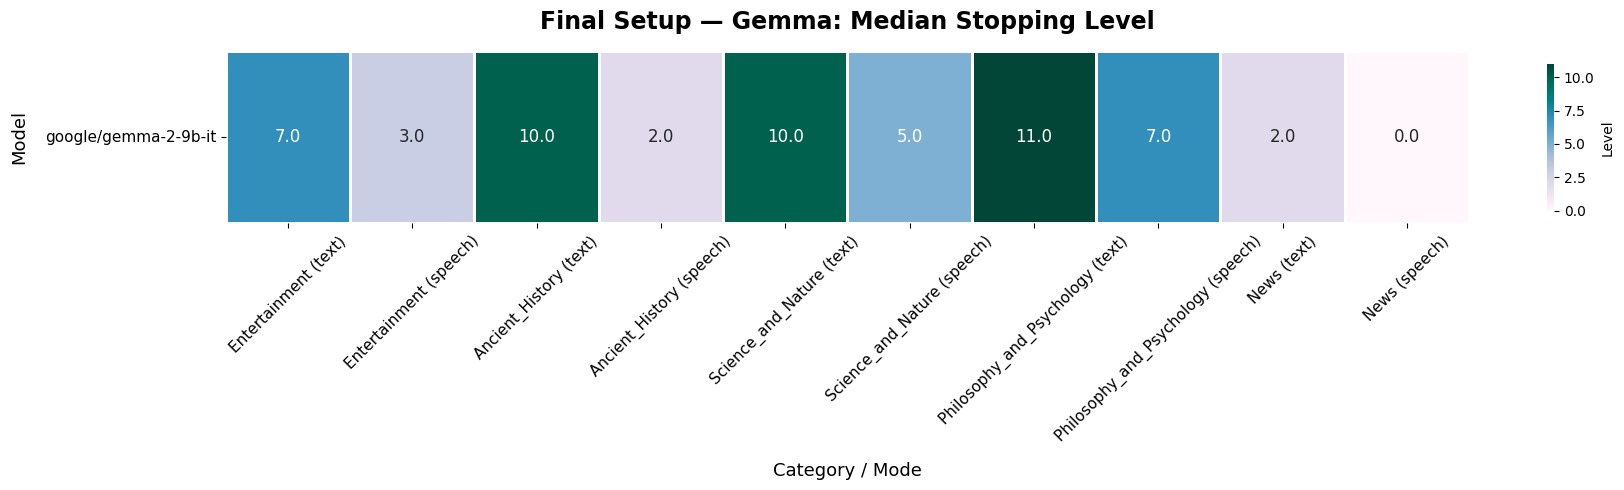

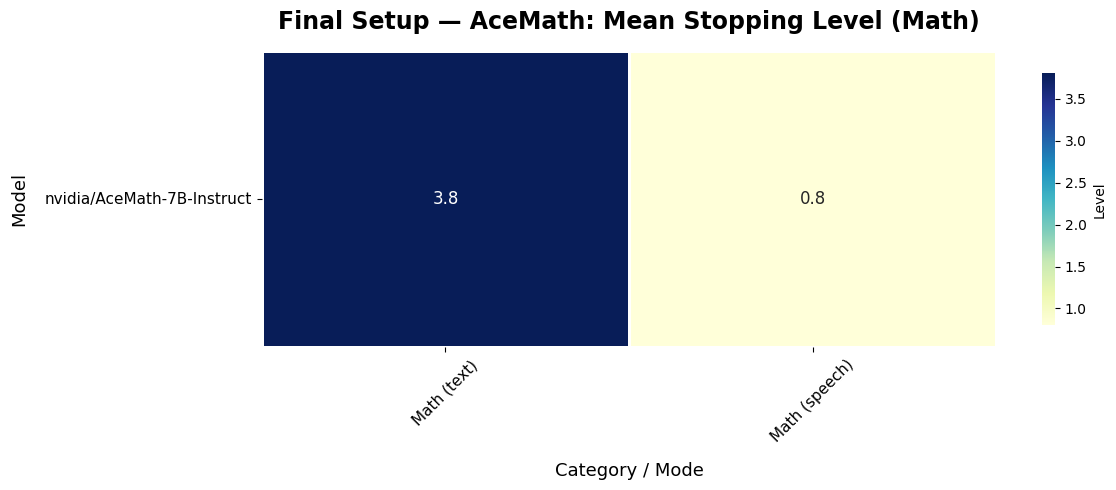

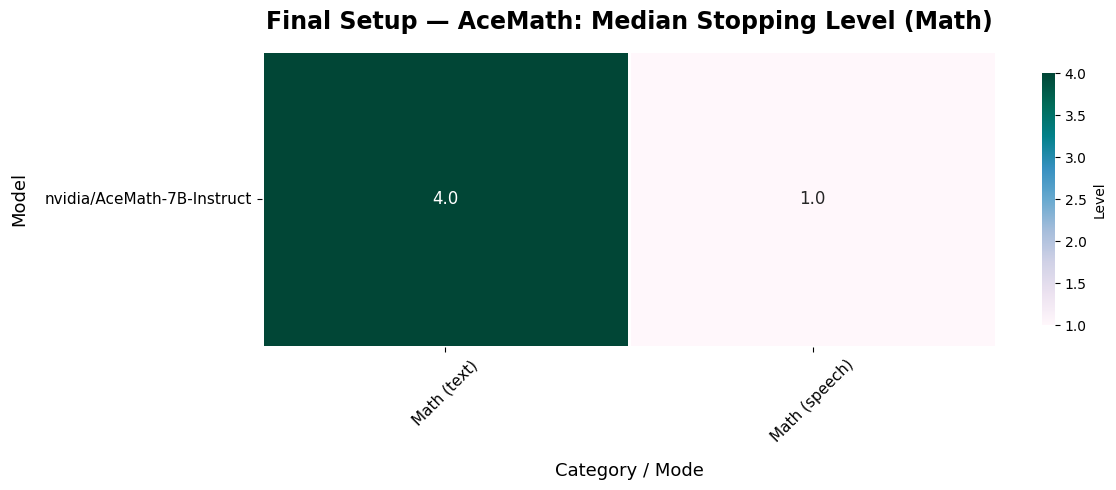

In [ ]:
# ==================================================
# S6.6 — FINAL SETUP PLOTS
# ==================================================

# Gemma — non-Math, text + speech
plot_single_metric_heatmap(
    pivot_mean_gemma,
    title="Final Setup — Gemma: Mean Stopping Level",
    cmap="YlGnBu", cbar_label="Level",
    save_path=HEATMAPS_DIR / "s6_gemma_mean_stopping_level.png",
)
plot_single_metric_heatmap(
    pivot_median_gemma,
    title="Final Setup — Gemma: Median Stopping Level",
    cmap="PuBuGn", cbar_label="Level",
    save_path=HEATMAPS_DIR / "s6_gemma_median_stopping_level.png",
)

# AceMath — Math only
plot_single_metric_heatmap(
    pivot_mean_math,
    title="Final Setup — AceMath: Mean Stopping Level (Math)",
    cmap="YlGnBu", cbar_label="Level",
    save_path=HEATMAPS_DIR / "s6_math_mean_stopping_level.png",
)

plot_single_metric_heatmap(
    pivot_median_math,
    title="Final Setup — AceMath: Median Stopping Level (Math)",
    cmap="PuBuGn", cbar_label="Level",
    save_path=HEATMAPS_DIR / "s6_math_median_stopping_level.png",
)